# PCAWG mutation profiles across TFBS

This notebook calculates observed and expected somatic mutation profiles across TFBS in the PCAWG Liver-HCC cohort (314 samples).

Mutation profiles are calculated across a 2,001-bp window centred on each TFBS binding site. Expected mutation counts are estimated using the trinucleotide mutation probabilities calculated in `02_PCAWG_mutation_probabilities.ipynb`.

The notebook includes:

1. 2,001-bp regions centred on each TFBS.
2. Intersection of PCAWG Liver-HCC SBS mutations with TFBS regions.
3. Calculation of observed and expected position-wise mutation counts.
4. Calculation of mutation fold change at the 101-bp core, DHS-proximal region and flanks.
5. Statistical testing of core mutation enrichment and Benjamini-Hochberg FDR correction across the 156 TFBS datasets retained after filtering.


In [2]:
#libraries
import numpy as np
from numpy.polynomial import polynomial as poly
import pandas as pd
import pybedtools as pbt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from bgreference import hg19

from pathlib import Path
from collections import defaultdict
from datetime import datetime

import math, gzip
import gzip, pickle
from scipy.stats import power_divergence
import statsmodels.stats.multitest

#### Files paths



In [ ]:
def find_repo_root():
    "'repository root'"
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (path / "notebooks").exists() and (path / "results").exists():
            return path

    raise FileNotFoundError("Could not locate repository root.")

REPO_ROOT = find_repo_root()

In [3]:
PCAWG_MUTATION_FILE = REPO_ROOT / "data" / "raw" / "pcawg" / "PCAWG_Liver-HCC_SBS.bed.gz"

MUT_PROB_FILE = REPO_ROOT / "results" / "preprocessing" / "PCAWG_trinucleotide_mutation_probabilities.csv"

TFBS_208_FILE = REPO_ROOT / "results" / "preprocessing" / "TFBS_208_nonoverlapping_sites.tsv"

TFBS_156_FILE = REPO_ROOT / "results" / "preprocessing" / "TFBS_site_counts_156.tsv"

OUTPUT_DIR = REPO_ROOT / "results" / "Figure1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
HCC_subs = pd.read_csv(PCAWG_MUTATION_FILE, sep="\t",header=None)

HCC_subs.rename(columns={0:"Chrom",
        1:"ChromStart",2:"ChromEnd", 3:"Nt", 4:"Subs_Nt", 5:"Code", 6:"Type"},inplace=True)
HCC_nbp = HCC_subs[["Chrom","ChromStart","ChromEnd"]].copy()

print("Number of samples:", HCC_subs["Code"].nunique())
HCC_nbp.head()

Number of samples: 314


,Chrom,ChromStart,ChromEnd
0,chr1,10505,10506
1,chr1,20251,20252
2,chr1,77903,77904
3,chr1,94993,94994
4,chr1,121080,121081


##### Mutation Probabilities

In [5]:
mut_prob = pd.read_csv(MUT_PROB_FILE, sep="\t")
mut_prob.head()

,mutation,Probability_PCAWG_all_samples,Probability_PCAWG_8_outliers,Probability_PCAWG_wo8_outliers,Probability_nfia_top3_outliers,Probability_nfia_13_outliers,Probability_nfia_wotop3_outliers,Probability_nfia_wo13_outliers
0,"('AAA', 'ACA')",0.001757,0.001610,0.001770,0.007259,0.002493,0.001662,0.001677
1,"('AAA', 'ATA')",0.002032,0.002242,0.002014,0.002116,0.001859,0.002030,0.002051
2,"('AAA', 'AGA')",0.003734,0.003977,0.003713,0.003169,0.003882,0.003744,0.003718
3,"('AAC', 'ACC')",0.001318,0.001225,0.001326,0.004118,0.001778,0.001269,0.001268
4,"('AAC', 'ATC')",0.002091,0.002279,0.002076,0.002471,0.001962,0.002085,0.002106


##### TFBS_files

In [6]:
TFBS_df = pd.read_csv(TFBS_208_FILE,sep="\t")

TFBS_df = TFBS_df[["Chrom","ChromStart","ChromEnd","Gene","Site length"]].copy()

TFBS_df.columns = range(TFBS_df.shape[1])
TFBS_df.sort_values(by=[3,0,1,2,4], inplace=True)

print("Number of TFBS datasets:", TFBS_df[3].nunique())
TFBS_df.head()

Number of TFBS datasets: 208


,0,1,2,3,4
0,chr1,1310515,1310891,ARID3A,376
1,chr1,1790671,1791047,ARID3A,376
2,chr1,3031848,3032224,ARID3A,376
3,chr1,3251966,3252342,ARID3A,376
4,chr1,4327409,4327785,ARID3A,376


In [7]:
#filtered based on binidng strength - 156TFBS
filtred156 = pd.read_csv(TFBS_156_FILE,sep="\t")

print("Number of filtered TFBS datasets:", len(filtred156))
filtred156.head()

Number of filtered TFBS datasets: 156


,Gene,Length_filtered
0,MAFK,60586
1,HLF,55753
2,RAD21,54820
3,CTCF,47498
4,CEBPA,44752


##### Calculating midpoints and adding flanks

In [13]:
TFBS_df["mid_start"] = (TFBS_df[1] + TFBS_df[2])/2
TFBS_df["mid_start"] = TFBS_df.apply(lambda x: math.floor(x['mid_start']), axis=1)

TFBS_df["mid_end"] = TFBS_df["mid_start"] +1

#Adding flanks
TFBS_df["reg_start"] = TFBS_df["mid_start"]- 1000
TFBS_df["reg_end"] = TFBS_df["mid_end"]+ 1000

TFBS_df.head()

,0,1,2,3,4,mid_start,mid_end,reg_start,reg_end
0,chr1,1310515,1310891,ARID3A,376,1310703,1310704,1309703,1311704
1,chr1,1790671,1791047,ARID3A,376,1790859,1790860,1789859,1791860
2,chr1,3031848,3032224,ARID3A,376,3032036,3032037,3031036,3033037
3,chr1,3251966,3252342,ARID3A,376,3252154,3252155,3251154,3253155
4,chr1,4327409,4327785,ARID3A,376,4327597,4327598,4326597,4328598


In [14]:
TFBS_df.sort_values(by = [3,0,"reg_start","reg_end",4], inplace = True)

#Length of the cordiates taken
TFBS_df[5] = TFBS_df["reg_end"] - TFBS_df["reg_start"]

#selecting required columns
TFBS_df = TFBS_df[[0, "reg_start", "reg_end", 4,3,5]]

#cleaning up
TFBS_df.columns = range(TFBS_df.shape[1])
TFBS_df.sort_values(by = [4,0,1,2,3], inplace = True)
print(f'No of TFs: {TFBS_df[4].nunique()}')
print(f'Length of df: {len(TFBS_df)}')
TFBS_df.head()

No of TFs: 208
Length of df: 2449546


,0,1,2,3,4,5
0,chr1,1309703,1311704,376,ARID3A,2001
1,chr1,1789859,1791860,376,ARID3A,2001
2,chr1,3031036,3033037,376,ARID3A,2001
3,chr1,3251154,3253155,376,ARID3A,2001
4,chr1,4326597,4328598,376,ARID3A,2001


##### removing any negative cordinates

In [15]:
TFBS_df[TFBS_df[1] <= 0]

,0,1,2,3,4,5
59174,chr17,-15,1986,440,ARID5B,2001
624991,chr17,-5,1996,340,FOXP1,2001


In [16]:
TFBS_df = TFBS_df[TFBS_df[1] > 0]

#### Compute Bg mutataion rate and Fishers tests

In [18]:
# function to compute the expected mutation counts
def get_exp_mut(res_df, flank, sign_dict, gene, ttype):
    '''compute the expected mutation count'''
    
    # exp counts
    nucleotides = set(['A', 'T', 'C', 'G'])

    final_position_prob_df = pd.DataFrame()
    final_position_prob_norm = pd.DataFrame()
    
    fasta = {}
    

    for idx, g in res_df.groupby([0, 1, 2]):

        chrm = g[0].values[0]
        chrStart = g[1].values[0]
        chrEnd = g[2].values[0]
        #gene = g[5].values[0]
        totalMuts = g[9].sum() # total obs mutations mapped to this region

        if totalMuts == 0: # skip the following if the segment has no mutation
            continue

        # extract the subsequence 
        # using bgreference
        #fasta sequences based on the cordinate for each TFBS
        tkey = "%s:%s-%s" % (chrm, chrStart, chrEnd)
        subseq = hg19(chrm, chrStart, (int(chrEnd)-int(chrStart))+2)
        fasta[tkey] = subseq

                           
        if len(fasta) == 0:
            print(tkey)
            
        start = -flank
        position_prob_lol = list()

        for i in range(1, len(subseq)-1):
            my_trinucleotide = subseq[i-1:i+2]
            # if i < max_prints:
            #     print(my_trinucleotide)
            my_ref_base = my_trinucleotide[1].upper()
            my_alt_bases = nucleotides - set(my_ref_base)
            my_base_probs = 0
            previous_base = my_trinucleotide[0]
            next_base = my_trinucleotide[2]

            for alt_base in my_alt_bases:
                tri_ref = previous_base + str(my_ref_base) + next_base
                tri_alt = previous_base + str(alt_base) + next_base
                my_key = str((tri_ref, tri_alt))

                try:
                    my_prob = sign_dict[my_key][ttype]
                    my_base_probs = my_base_probs + my_prob

                except:
                    None

           
            # if i < max_prints:
            #     print(tri_ref, tri_alt)


            position_prob_lol.append([start, my_base_probs])
            start += 1

        position_prob_df = pd.DataFrame(position_prob_lol)
        position_prob_df.columns = ['position', 'probability']
        
        #for normalised values
        position_prob_norm = pd.DataFrame(position_prob_lol)
        position_prob_norm.columns = ['position', 'probability']

        my_total = sum(position_prob_df['probability'])
        
        
        position_prob_df['probability'] = position_prob_df['probability']/my_total
        position_prob_df['expected_muts'] = position_prob_df['probability']*int(totalMuts)
          
        position_prob_df = position_prob_df[['position', 'expected_muts']]

        # Sum the expected results (i.e., the output from each sequence)
        if len(final_position_prob_df) == 0:
            final_position_prob_df = position_prob_df
        else:
            final_position_prob_df['expected_muts'] = (final_position_prob_df['expected_muts'] +
                                                           position_prob_df['expected_muts'])
    
    return final_position_prob_df 



In [9]:
def fisherstest(df, core, dhs, flank):
    '''function to perform Fisher's exact test'''
    #Step: computing mutations for obs and expected
    #obs_muts_motif = df[(df['position']>=-motif) & (df['position']<=motif)]['observed_muts'].sum()
    obs_muts_core = df[(df['position']>=-core) & (df['position']<=core)]['observed_muts'].sum()
    obs_muts_dhs = df[(df['position']<-core) & (df['position']>-dhs)]['observed_muts'].sum() + df[(df['position']>core) & (df['position']<dhs)]['observed_muts'].sum()
    obs_muts_flank = df[(df['position']<-dhs) & (df['position']>-flank)]['observed_muts'].sum() + df[(df['position']>dhs) & (df['position']<flank)]['observed_muts'].sum()
    #obs_motif_flank = df[(df['position']<-motif)]['observed_muts'].sum() + df[(df['position']>motif)]['observed_muts'].sum()
    obs_core_flank = df[(df['position']<-core)]['observed_muts'].sum() + df[(df['position']>core)]['observed_muts'].sum()
#    tot_obs = obs_muts_motif + obs_muts_core + obs_muts_dhs + obs_muts_flank
    
    # exp_muts_motif = df[(df['position']>=-motif) & (df['position']<=motif)]['expected_muts'].sum()
    exp_muts_core = df[(df['position']>=-core) & (df['position']<=core)]['expected_muts'].sum()
    exp_muts_dhs = df[(df['position']<-core) & (df['position']>-dhs)]['expected_muts'].sum() + df[(df['position']>core) & (df['position']<dhs)]['expected_muts'].sum()
    exp_muts_flank = df[(df['position']<-dhs) & (df['position']>-flank)]['expected_muts'].sum() + df[(df['position']>dhs) & (df['position']<flank)]['expected_muts'].sum()
    #exp_motif_flank = df[(df['position']<-motif)]['expected_muts'].sum() + df[(df['position']>motif)]['expected_muts'].sum()
    exp_core_flank = df[(df['position']<-core)]['expected_muts'].sum() + df[(df['position']>core)]['expected_muts'].sum()
 #   tot_exp = exp_muts_motif + exp_muts_core + exp_muts_dhs + exp_muts_flank

   # print(obs_muts_core, exp_muts_core, obs_core_flank, exp_core_flank)
    
    #contigency table
    cont = [[obs_muts_core, exp_muts_core],
        [obs_core_flank, exp_core_flank]]
    odd_ratio_core, p_value_core = stats.fisher_exact(cont, alternative = 'two-sided')

    
   
    #Step: computing Fc
    # fc_motif = obs_muts_motif/exp_muts_motif
    fc_core = obs_muts_core/exp_muts_core
    fc_dhs = obs_muts_dhs/exp_muts_dhs
    fc_flanks = obs_muts_flank/exp_muts_flank
    
    print(f"FC: {fc_core}", f"OR{odd_ratio_core}", f"Pvalue: {p_value_core}")
    
    return(obs_muts_core, obs_core_flank, exp_muts_core, exp_core_flank, fc_core, fc_dhs, fc_flanks, odd_ratio_core, p_value_core)

In [10]:
def format_fc_p(fc, p, tiny_thresh=1e-4, sci_thresh=1e-3):
    """ Formatting: so that very low p vals do not look like 0.00000 
       - p < 1e-4  → threshold form
       - 1e-4 ≤ p < 1e-3 → scientific notation (avoids 0.000) 
       - p ≥ 1e-3 → fixed 3 decimals
    """
    if p < tiny_thresh:
        return f"FC={fc:.2f}, p<{tiny_thresh:.0e}"   
    elif p < sci_thresh:
        return f"FC={fc:.2f}, p={p:.1e}"             
    else:
        return f"FC={fc:.2f}, p={p:.3f}"           


Samples: PCAWG_all_samples Gene: ARID3A Obs Sum: 27592 Exp Sum: 27592.000000000087
FC: 1.5579097449434498 OR1.6068654631362629 Pvalue: 7.166796163089105e-42
FC core:1.5579097449434498 Pvalue: 7.166796163089105e-42


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


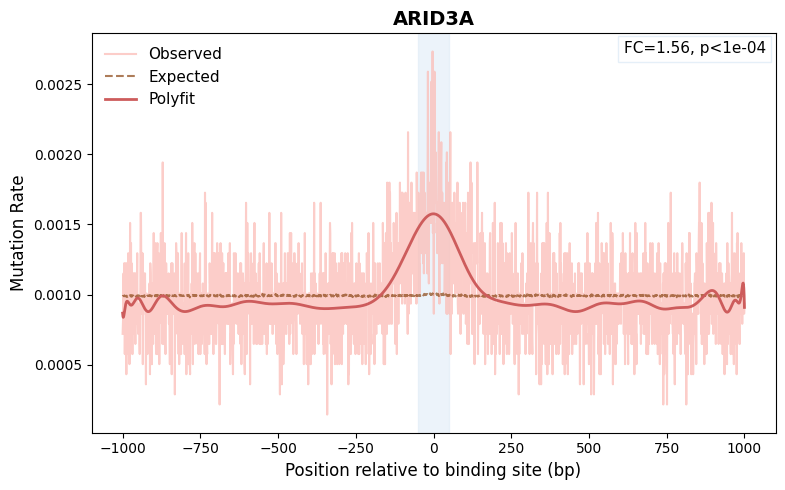

Samples: PCAWG_all_samples Gene: ARID4B Obs Sum: 50241 Exp Sum: 50241.00000000012
FC: 1.427757955450675 OR1.4628766885801023 Pvalue: 8.326416612563395e-49
FC core:1.427757955450675 Pvalue: 8.326416612563395e-49


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


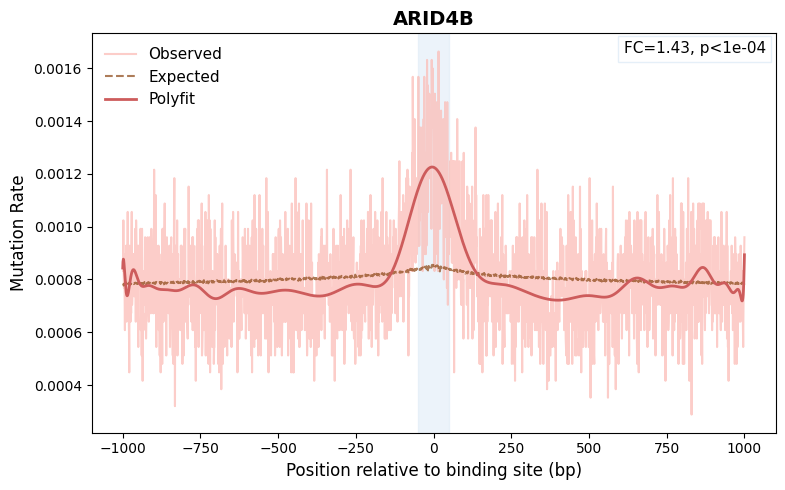

Samples: PCAWG_all_samples Gene: ARID5B Obs Sum: 71812 Exp Sum: 71812.00000000025
FC: 1.332799466264563 OR1.3576343372697846 Pvalue: 5.374093953361965e-43
FC core:1.332799466264563 Pvalue: 5.374093953361965e-43


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


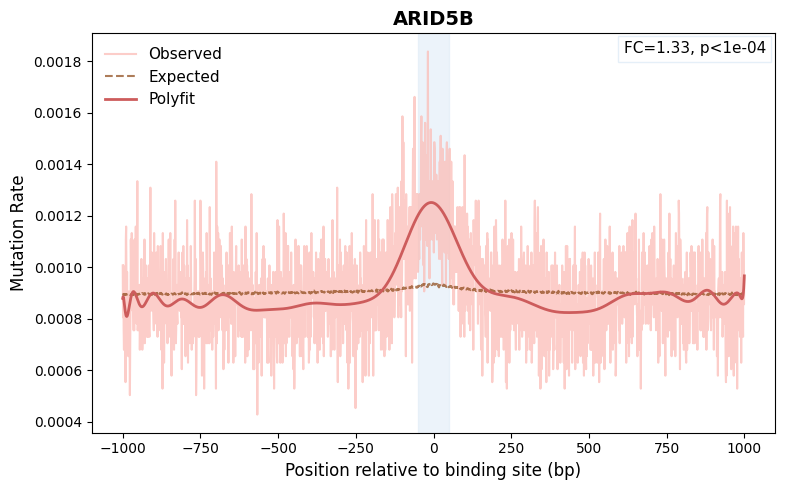

Samples: PCAWG_all_samples Gene: ASH2L Obs Sum: 28767 Exp Sum: 28767.000000000087
FC: 1.0104409420512719 OR1.0111805789626713 Pvalue: 0.779435195589965
FC core:1.0104409420512719 Pvalue: 0.779435195589965


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


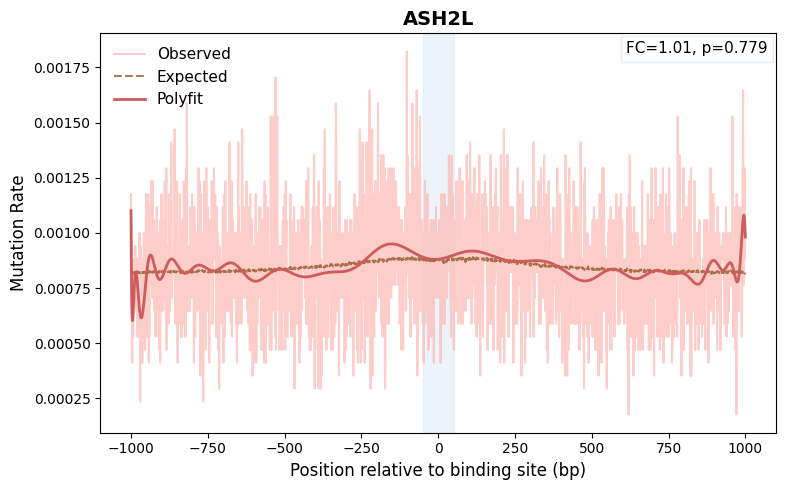

Samples: PCAWG_all_samples Gene: ATF1 Obs Sum: 13992 Exp Sum: 13992.000000000051
FC: 1.29587746872018 OR1.318177127435068 Pvalue: 4.8851859582693616e-08
FC core:1.29587746872018 Pvalue: 4.8851859582693616e-08


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


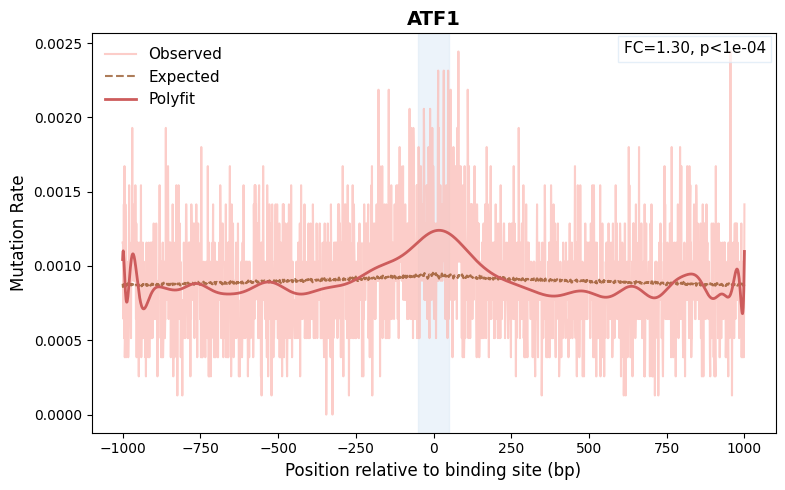

Samples: PCAWG_all_samples Gene: ATF3 Obs Sum: 3585 Exp Sum: 3585.000000000011
FC: 1.244604423640062 OR1.2646334395827297 Pvalue: 0.01764224456872368
FC core:1.244604423640062 Pvalue: 0.01764224456872368


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


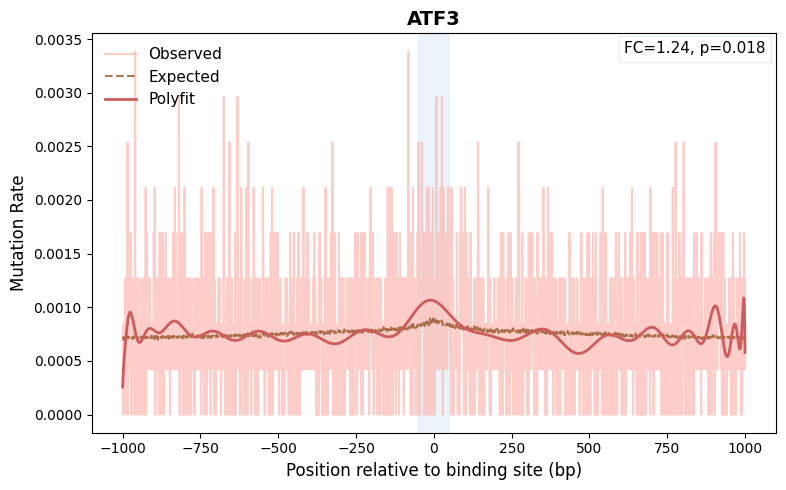

Samples: PCAWG_all_samples Gene: ATF4 Obs Sum: 4678 Exp Sum: 4678.000000000015
FC: 1.2253879805260366 OR1.2452776165898054 Pvalue: 0.01594258554794664
FC core:1.2253879805260366 Pvalue: 0.01594258554794664


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


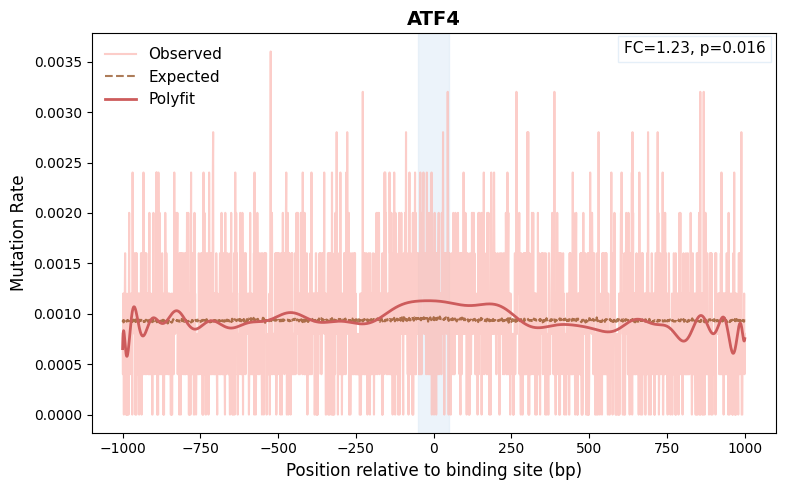

Samples: PCAWG_all_samples Gene: BACH1 Obs Sum: 9592 Exp Sum: 9592.00000000003
FC: 1.0117262883400944 OR1.0129528339062708 Pvalue: 0.8693951979447558
FC core:1.0117262883400944 Pvalue: 0.8693951979447558


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


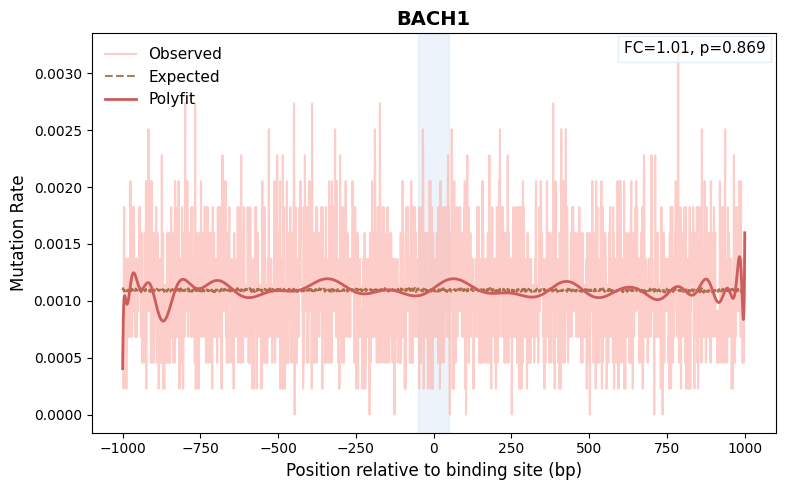

Samples: PCAWG_all_samples Gene: BCL6 Obs Sum: 52612 Exp Sum: 52612.00000000019
FC: 1.3211627778609523 OR1.3448136458213567 Pvalue: 8.158584121727341e-30
FC core:1.3211627778609523 Pvalue: 8.158584121727341e-30


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


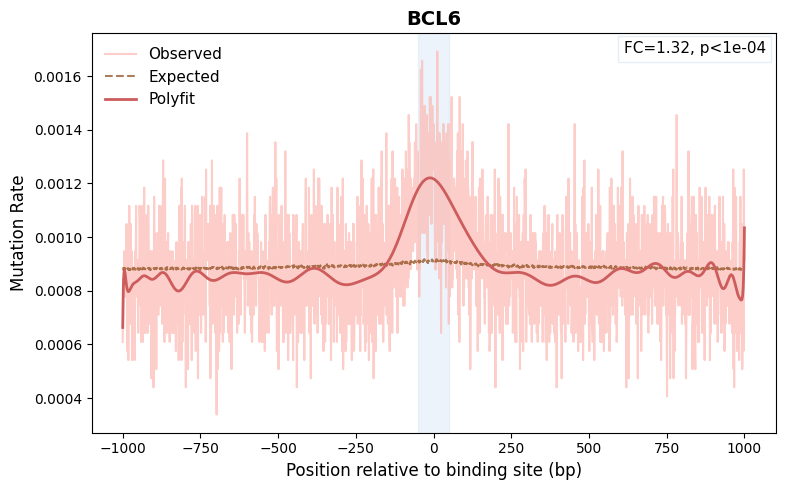

Samples: PCAWG_all_samples Gene: BHLHE40 Obs Sum: 22593 Exp Sum: 22593.00000000006
FC: 1.3285194804107847 OR1.3546567636696392 Pvalue: 7.269107193019127e-15
FC core:1.3285194804107847 Pvalue: 7.269107193019127e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


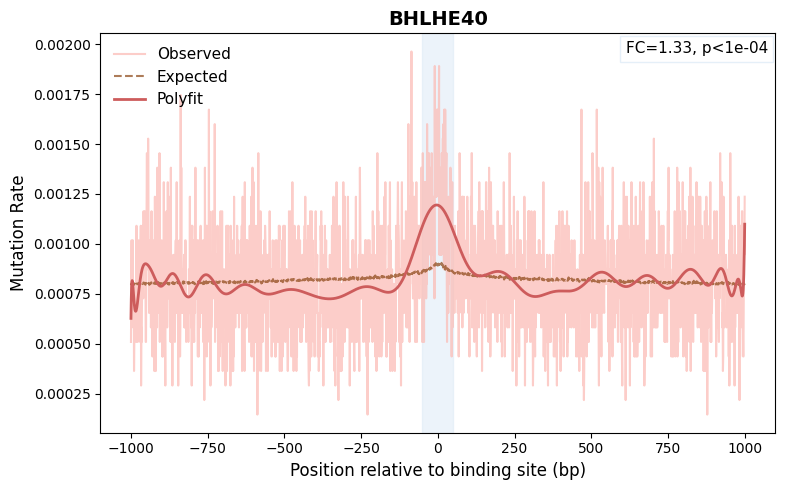

Samples: PCAWG_all_samples Gene: BMI1 Obs Sum: 548 Exp Sum: 548.000000000002
FC: 0.8840427195900342 OR0.8821034775233249 Pvalue: 0.6703014371771314
FC core:0.8840427195900342 Pvalue: 0.6703014371771314


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


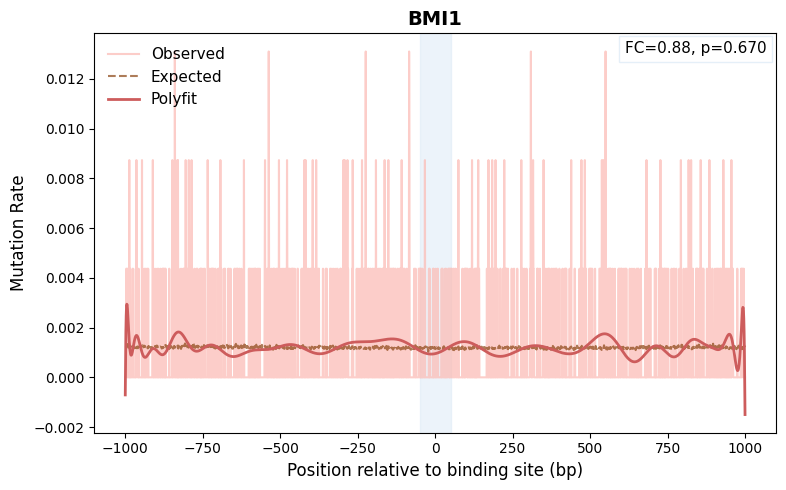

Samples: PCAWG_all_samples Gene: BRCA1 Obs Sum: 1911 Exp Sum: 1911.0000000000068
FC: 1.0141589586240127 OR1.0187477891758048 Pvalue: 0.9448853765343925
FC core:1.0141589586240127 Pvalue: 0.9448853765343925


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


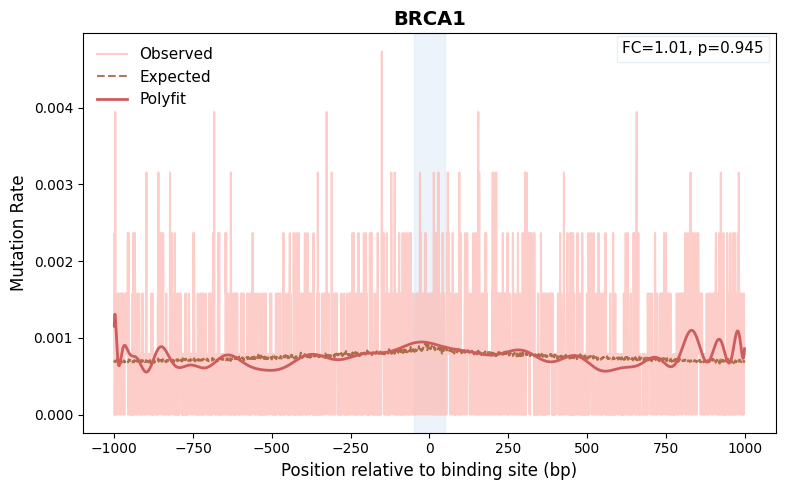

Samples: PCAWG_all_samples Gene: BRD4 Obs Sum: 2187 Exp Sum: 2187.0000000000073
FC: 1.186665300075912 OR1.2018478315746959 Pvalue: 0.17446402819447043
FC core:1.186665300075912 Pvalue: 0.17446402819447043


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


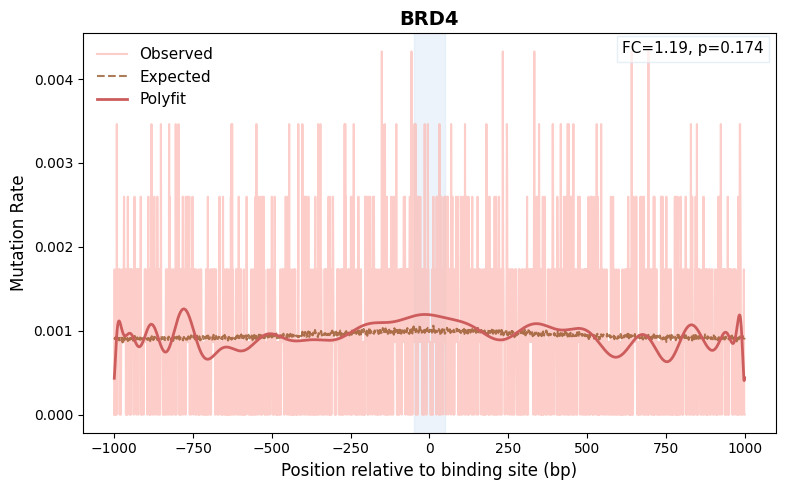

Samples: PCAWG_all_samples Gene: CBX1 Obs Sum: 745 Exp Sum: 745.000000000003
FC: 1.3250309957125688 OR1.3667373630258042 Pvalue: 0.16986334643186146
FC core:1.3250309957125688 Pvalue: 0.16986334643186146


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


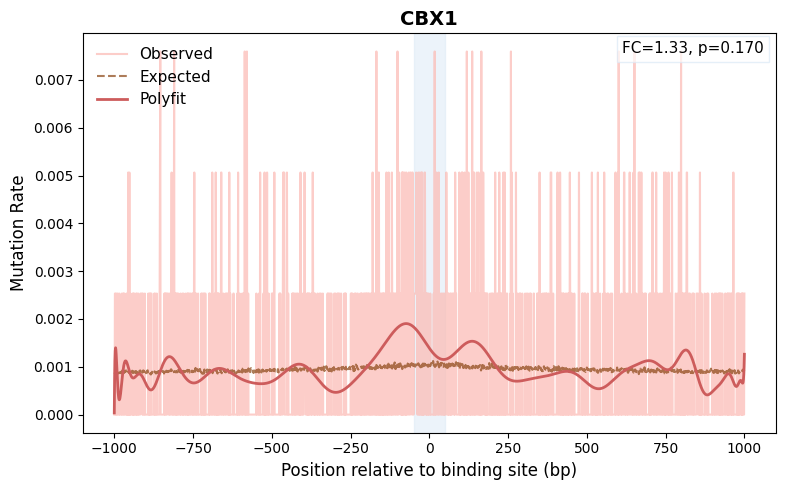

Samples: PCAWG_all_samples Gene: CBX5 Obs Sum: 10689 Exp Sum: 10689.000000000038
FC: 1.4378246392137444 OR1.4752219445735022 Pvalue: 2.640144487356773e-12
FC core:1.4378246392137444 Pvalue: 2.640144487356773e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


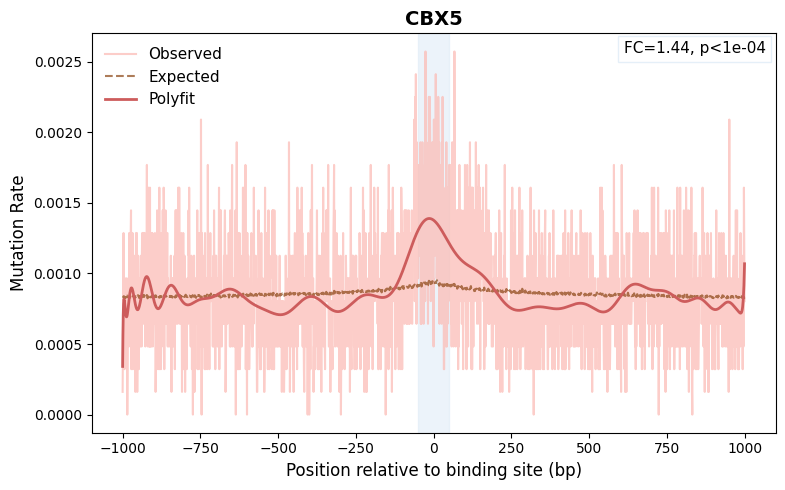

Samples: PCAWG_all_samples Gene: CEBPA Obs Sum: 85078 Exp Sum: 85078.00000000023
FC: 1.3380337808678862 OR1.3628917789911064 Pvalue: 5.0805155252794326e-51
FC core:1.3380337808678862 Pvalue: 5.0805155252794326e-51


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


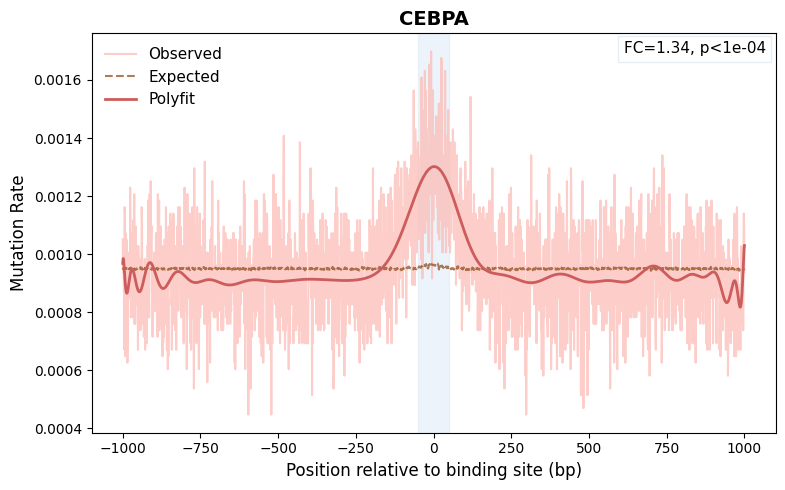

Samples: PCAWG_all_samples Gene: CEBPB Obs Sum: 62195 Exp Sum: 62195.00000000021
FC: 1.3266762510353325 OR1.3506124823738663 Pvalue: 1.8392778182616854e-35
FC core:1.3266762510353325 Pvalue: 1.8392778182616854e-35


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


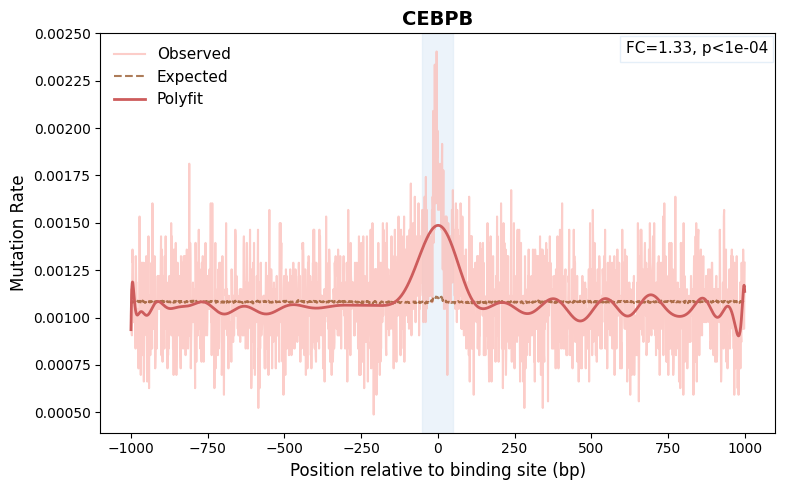

Samples: PCAWG_all_samples Gene: CEBPG Obs Sum: 62313 Exp Sum: 62313.00000000016
FC: 1.3674415748830182 OR1.395569291580002 Pvalue: 2.28632933933868e-44
FC core:1.3674415748830182 Pvalue: 2.28632933933868e-44


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


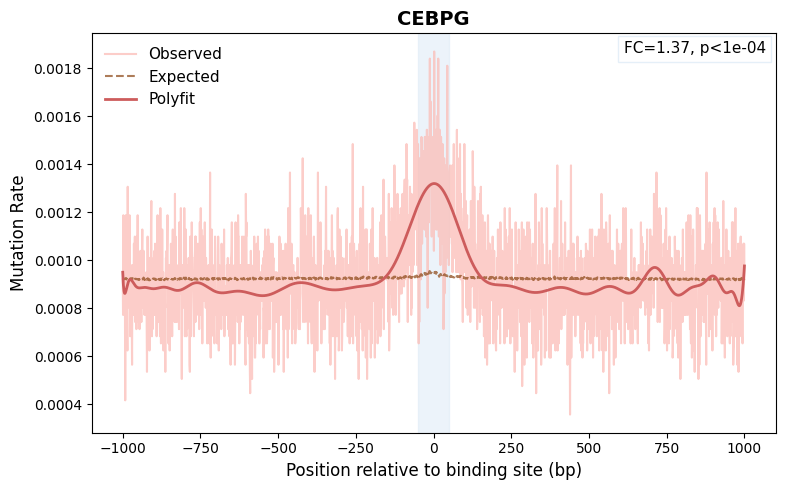

Samples: PCAWG_all_samples Gene: CEBPZ Obs Sum: 532 Exp Sum: 532.0000000000018
FC: 1.5975840482117998 OR1.664835164835165 Pvalue: 0.059394543102287894
FC core:1.5975840482117998 Pvalue: 0.059394543102287894


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


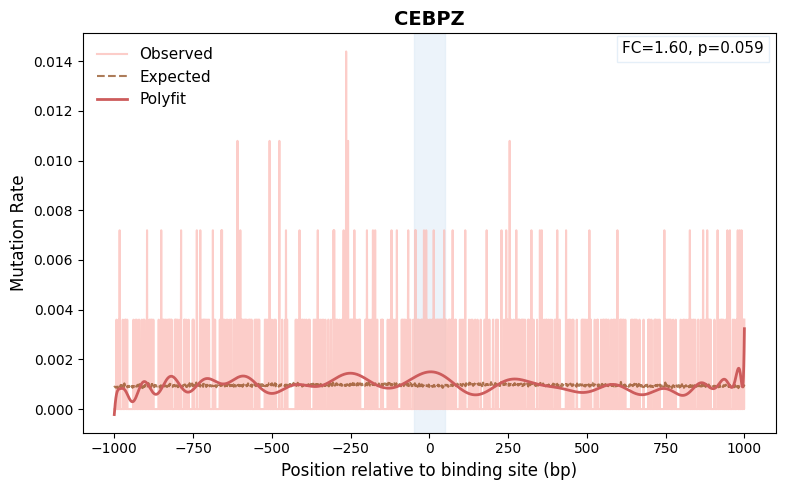

Samples: PCAWG_all_samples Gene: CHD2 Obs Sum: 6676 Exp Sum: 6676.000000000024
FC: 1.0865370421776868 OR1.0933202115777 Pvalue: 0.2390746371538961
FC core:1.0865370421776868 Pvalue: 0.2390746371538961


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


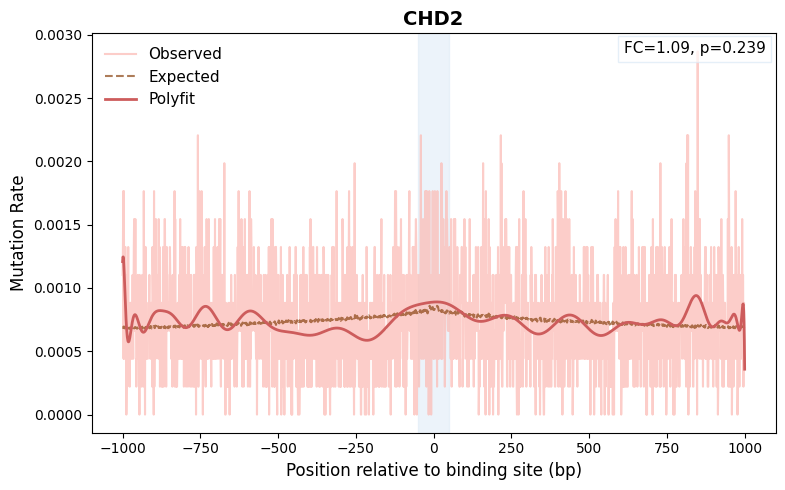

Samples: PCAWG_all_samples Gene: CIZ1 Obs Sum: 2504 Exp Sum: 2504.00000000001
FC: 0.9014133573466642 OR0.8958613031011221 Pvalue: 0.3657127003953461
FC core:0.9014133573466642 Pvalue: 0.3657127003953461


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


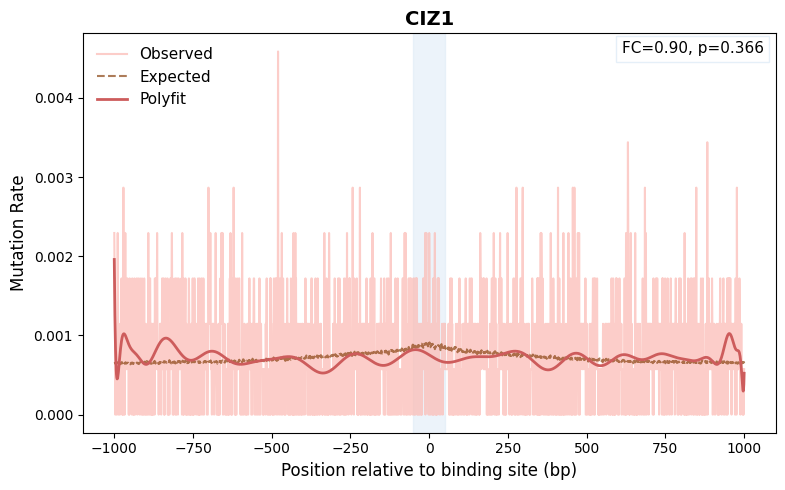

Samples: PCAWG_all_samples Gene: CREB1 Obs Sum: 27244 Exp Sum: 27244.0000000001
FC: 1.3038999009040926 OR1.3262455659307868 Pvalue: 7.730278003185562e-15
FC core:1.3038999009040926 Pvalue: 7.730278003185562e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


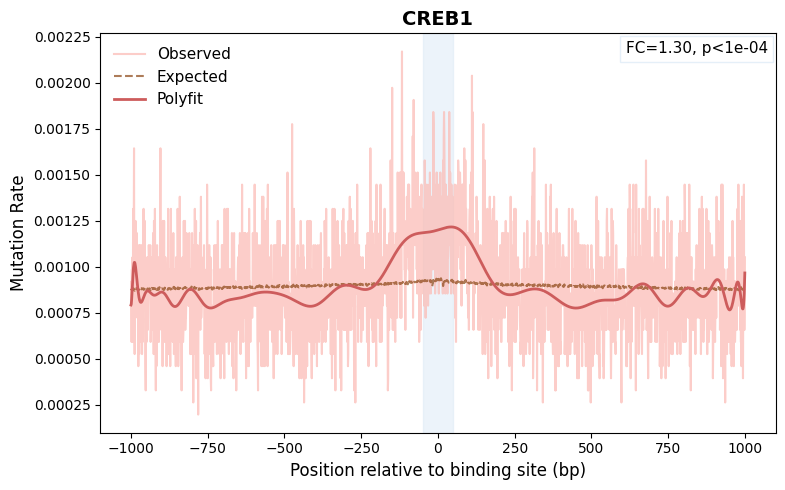

Samples: PCAWG_all_samples Gene: CREM Obs Sum: 25967 Exp Sum: 25967.00000000005
FC: 1.3577850097565882 OR1.385434257801243 Pvalue: 9.67202054626029e-19
FC core:1.3577850097565882 Pvalue: 9.67202054626029e-19


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


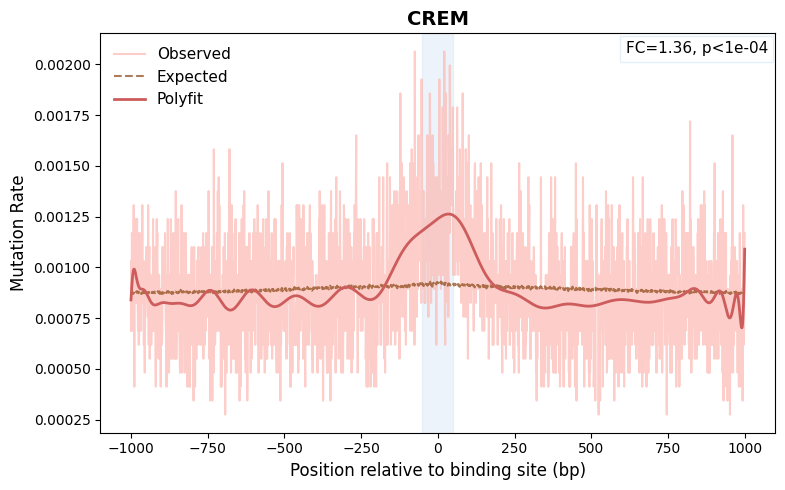

Samples: PCAWG_all_samples Gene: CTCF Obs Sum: 98857 Exp Sum: 98857.00000000032
FC: 1.5084815595397068 OR1.552365273078782 Pvalue: 3.3510821199414197e-127
FC core:1.5084815595397068 Pvalue: 3.3510821199414197e-127


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


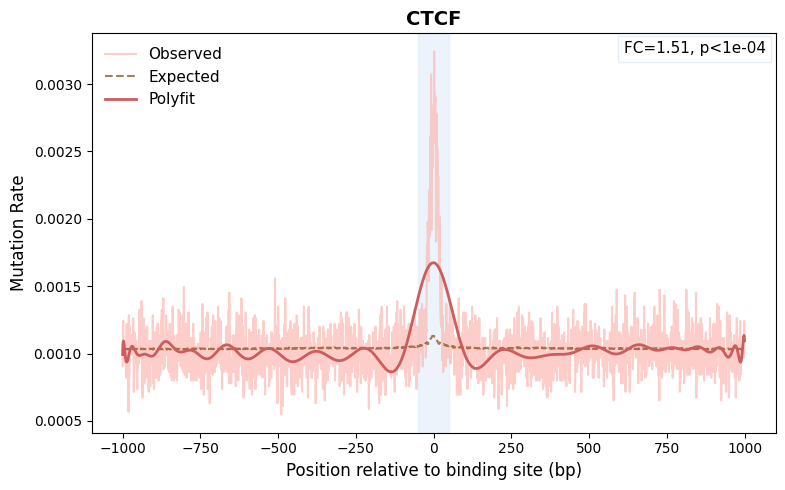

Samples: PCAWG_all_samples Gene: CUX1 Obs Sum: 4708 Exp Sum: 4708.000000000015
FC: 1.4476237803965255 OR1.4871401462382434 Pvalue: 3.883451524810399e-06
FC core:1.4476237803965255 Pvalue: 3.883451524810399e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


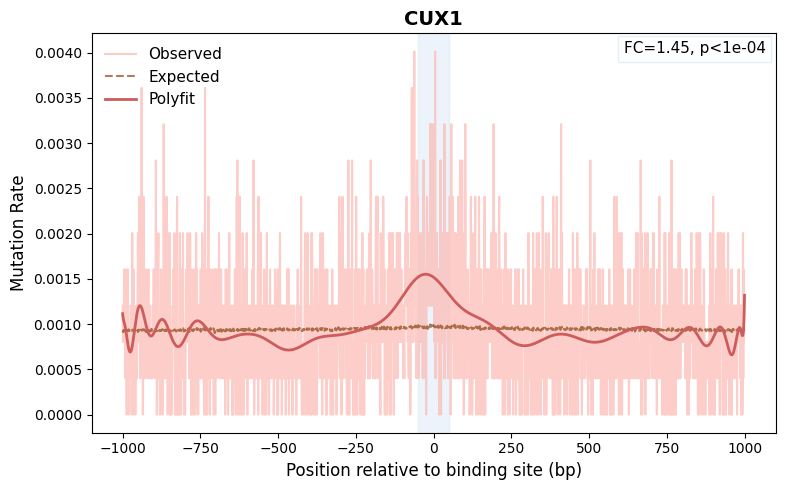

Samples: PCAWG_all_samples Gene: DMAP1 Obs Sum: 20289 Exp Sum: 20289.00000000007
FC: 1.1861539187170027 OR1.1992828973019503 Pvalue: 1.7642543900842162e-05
FC core:1.1861539187170027 Pvalue: 1.7642543900842162e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


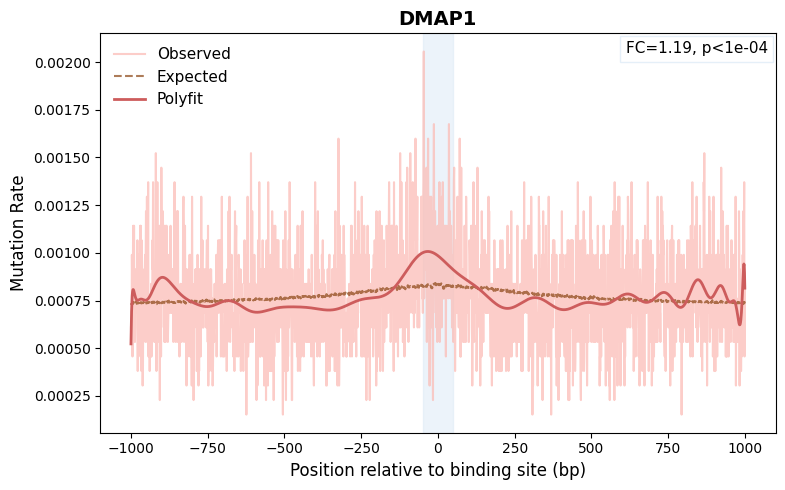

Samples: PCAWG_all_samples Gene: DNMT3B Obs Sum: 7126 Exp Sum: 7126.000000000024
FC: 1.3389877574223665 OR1.3681264875347592 Pvalue: 8.408371267826558e-06
FC core:1.3389877574223665 Pvalue: 8.408371267826558e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


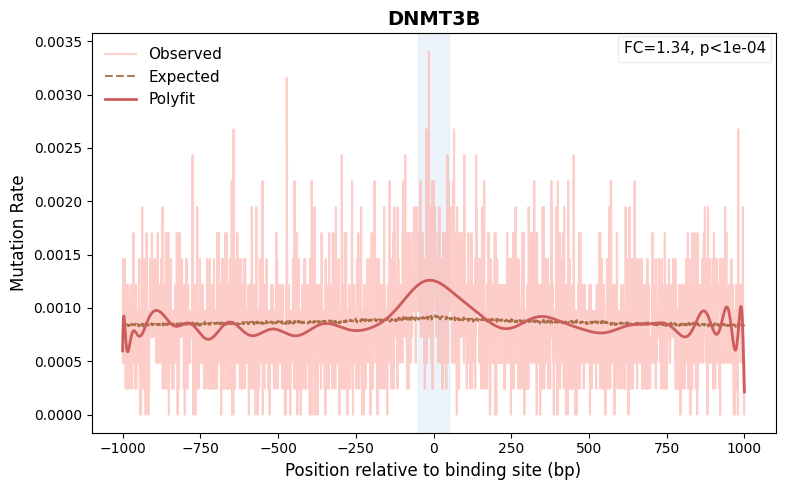

Samples: PCAWG_all_samples Gene: DRAP1 Obs Sum: 27284 Exp Sum: 27284.00000000008
FC: 1.2988282074933766 OR1.3217553559307365 Pvalue: 6.796762401582913e-15
FC core:1.2988282074933766 Pvalue: 6.796762401582913e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


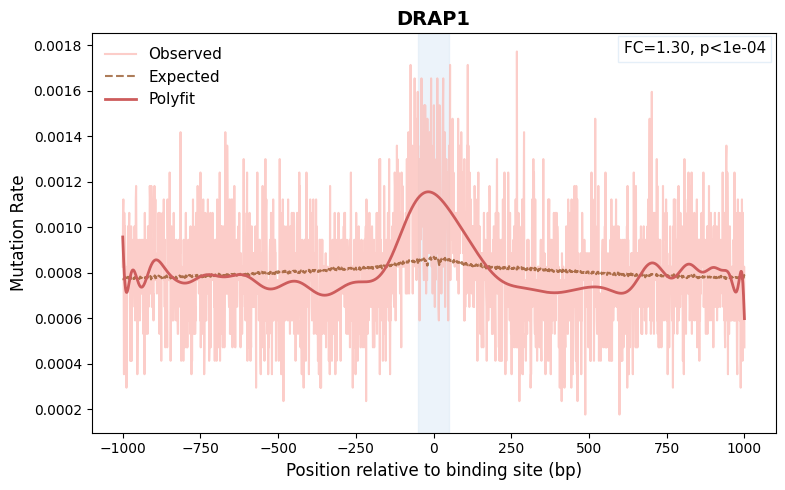

Samples: PCAWG_all_samples Gene: E2F7 Obs Sum: 1804 Exp Sum: 1804.0000000000057
FC: 1.049817995426466 OR1.0524720423778693 Pvalue: 0.7736777020123282
FC core:1.049817995426466 Pvalue: 0.7736777020123282


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


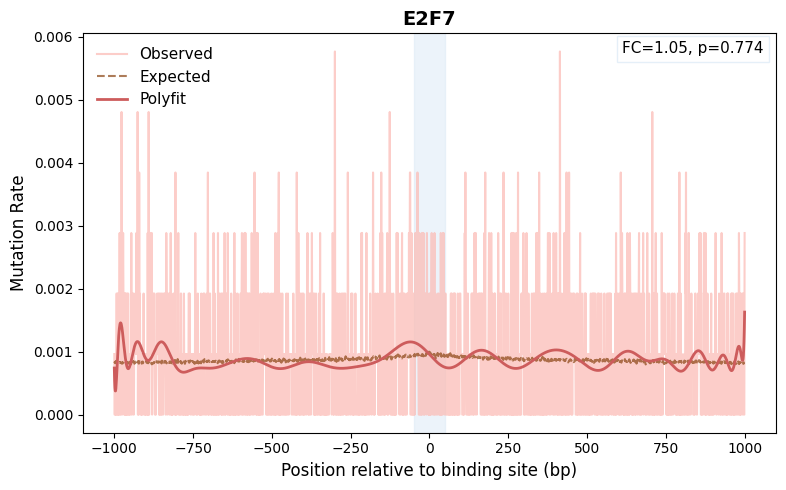

Samples: PCAWG_all_samples Gene: ELF3 Obs Sum: 47428 Exp Sum: 47428.000000000146
FC: 1.3860467751627819 OR1.416452461733135 Pvalue: 4.0895403924895634e-38
FC core:1.3860467751627819 Pvalue: 4.0895403924895634e-38


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


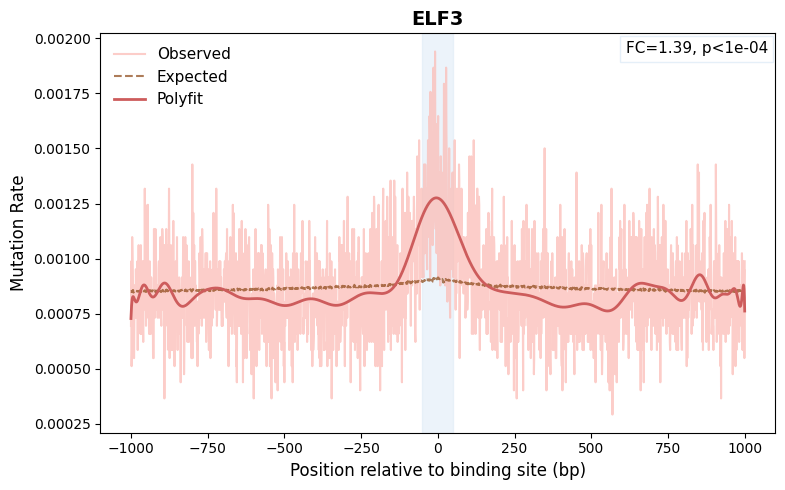

Samples: PCAWG_all_samples Gene: EP300 Obs Sum: 35168 Exp Sum: 35168.000000000124
FC: 1.3664741036811907 OR1.3938569612223395 Pvalue: 2.899944767651098e-25
FC core:1.3664741036811907 Pvalue: 2.899944767651098e-25


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


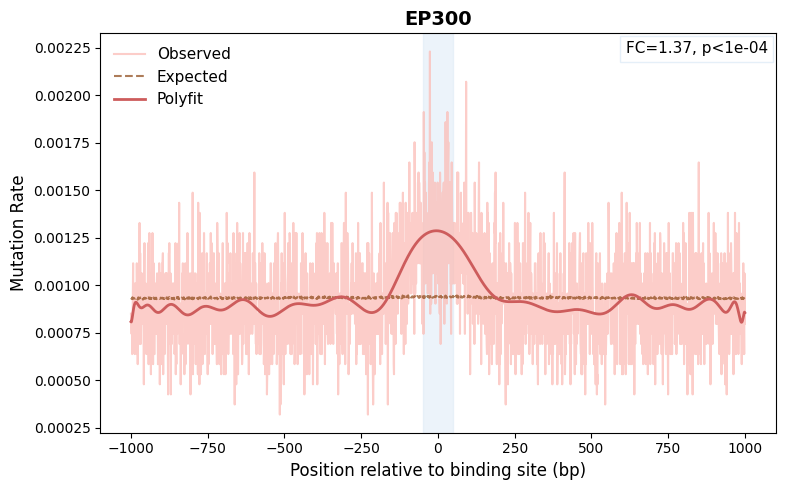

Samples: PCAWG_all_samples Gene: ERF Obs Sum: 27945 Exp Sum: 27945.000000000073
FC: 1.3900183258478438 OR1.4221272799927813 Pvalue: 4.536007794947705e-24
FC core:1.3900183258478438 Pvalue: 4.536007794947705e-24


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


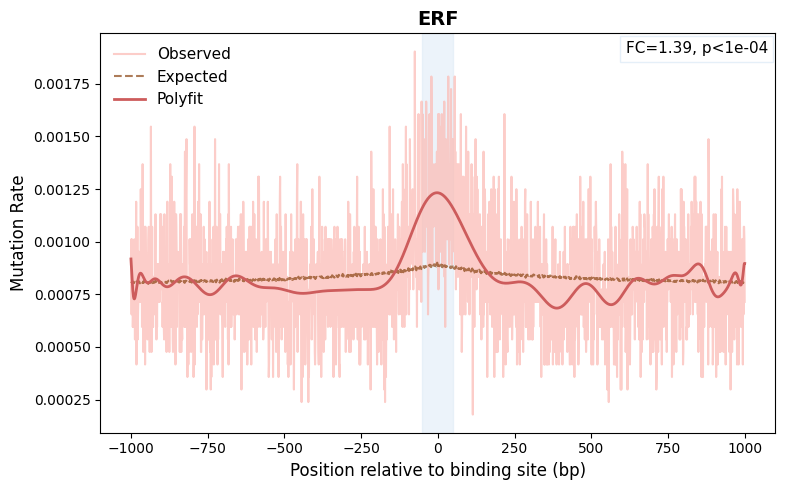

Samples: PCAWG_all_samples Gene: ESRRA Obs Sum: 728 Exp Sum: 728.0000000000018
FC: 1.427150397838541 OR1.4941053813457374 Pvalue: 0.08272933502763169
FC core:1.427150397838541 Pvalue: 0.08272933502763169


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


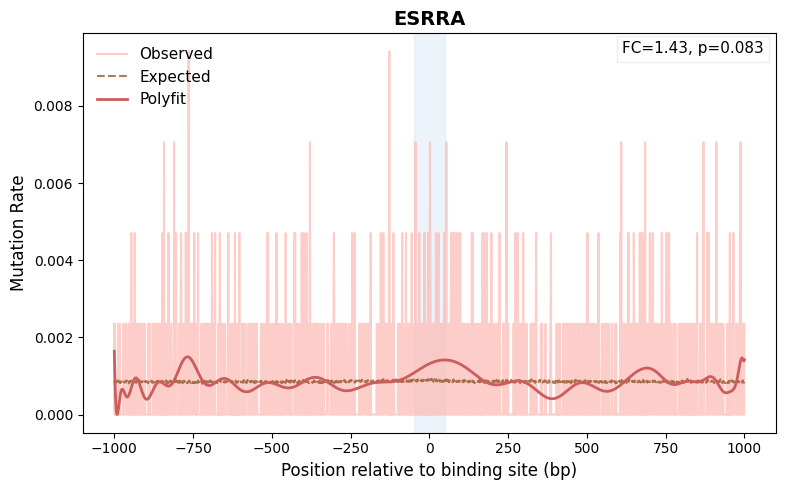

Samples: PCAWG_all_samples Gene: ETV4 Obs Sum: 19482 Exp Sum: 19482.000000000047
FC: 1.3213588198934343 OR1.3462630538738416 Pvalue: 3.1075525298880165e-12
FC core:1.3213588198934343 Pvalue: 3.1075525298880165e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


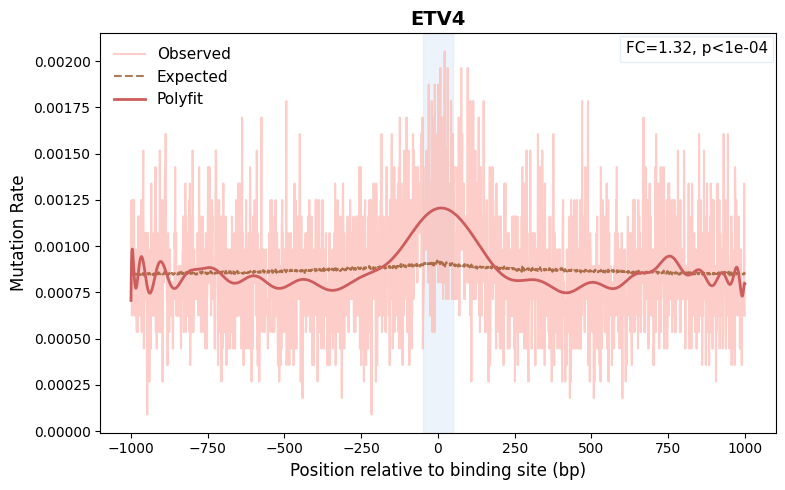

Samples: PCAWG_all_samples Gene: EZH2 Obs Sum: 2219 Exp Sum: 2219.0000000000064
FC: 1.0610993941435334 OR1.0660989404444903 Pvalue: 0.6839916794416055
FC core:1.0610993941435334 Pvalue: 0.6839916794416055


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


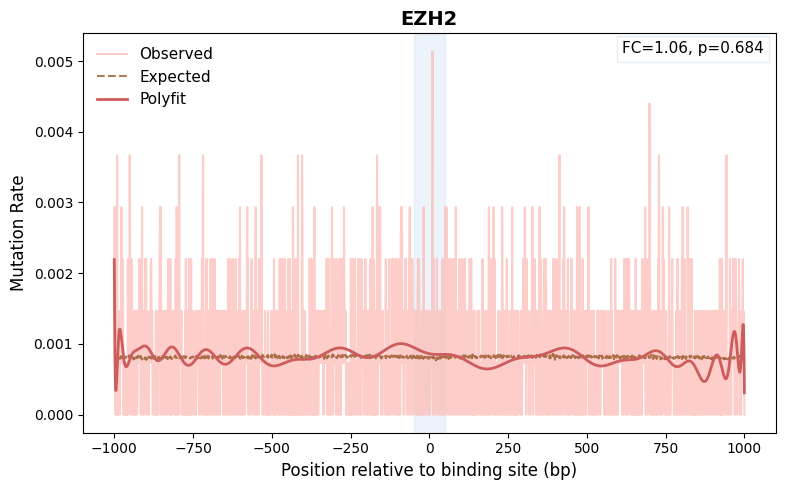

Samples: PCAWG_all_samples Gene: FOS Obs Sum: 8111 Exp Sum: 8111.000000000027
FC: 1.3498789056046854 OR1.3789096752846586 Pvalue: 1.0372532594341677e-06
FC core:1.3498789056046854 Pvalue: 1.0372532594341677e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


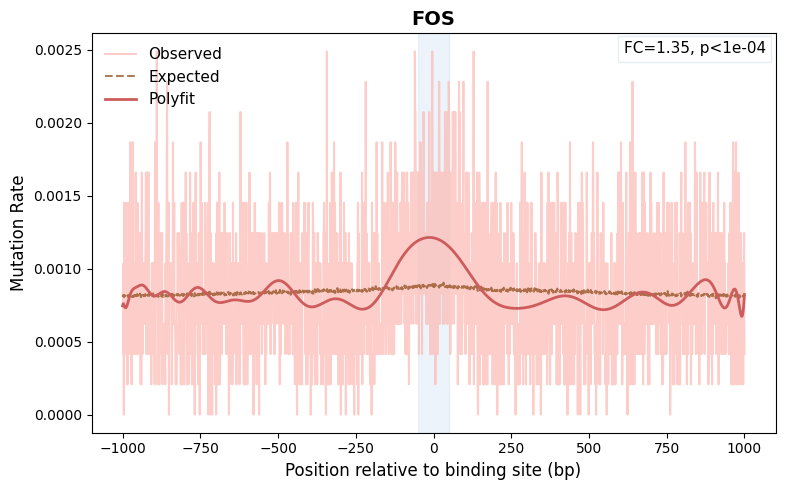

Samples: PCAWG_all_samples Gene: FOSL2 Obs Sum: 27727 Exp Sum: 27727.000000000084
FC: 1.3006118520413181 OR1.3228815141321284 Pvalue: 1.2587233623606689e-14
FC core:1.3006118520413181 Pvalue: 1.2587233623606689e-14


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


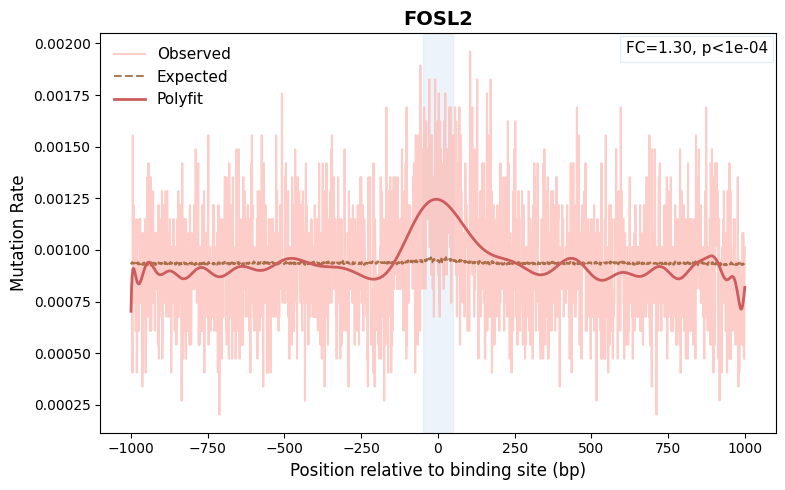

Samples: PCAWG_all_samples Gene: FOXA1 Obs Sum: 75122 Exp Sum: 75122.00000000025
FC: 1.2755782764836712 OR1.294501827314692 Pvalue: 6.916509987685847e-31
FC core:1.2755782764836712 Pvalue: 6.916509987685847e-31


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


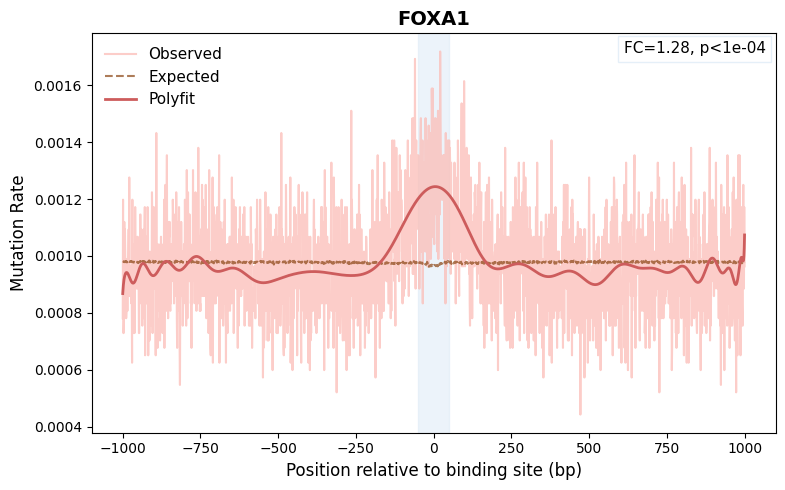

Samples: PCAWG_all_samples Gene: FOXA2 Obs Sum: 52677 Exp Sum: 52677.00000000016
FC: 1.2599557540137072 OR1.277822167452071 Pvalue: 6.213346653905776e-20
FC core:1.2599557540137072 Pvalue: 6.213346653905776e-20


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


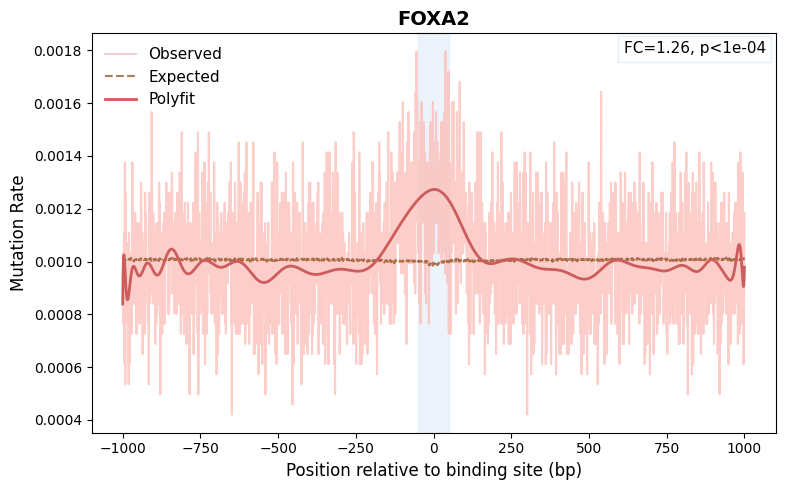

Samples: PCAWG_all_samples Gene: FOXA3 Obs Sum: 64385 Exp Sum: 64385.00000000022
FC: 1.363019625212475 OR1.390804306011731 Pvalue: 5.662421912288719e-45
FC core:1.363019625212475 Pvalue: 5.662421912288719e-45


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


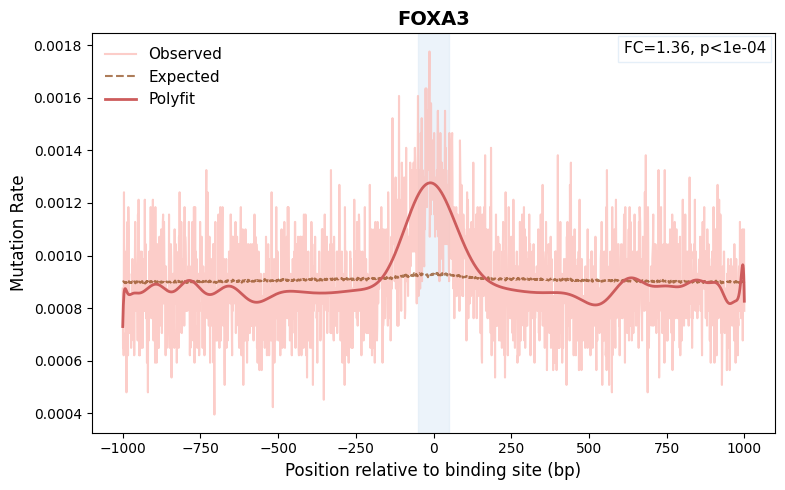

Samples: PCAWG_all_samples Gene: GABPB1 Obs Sum: 24646 Exp Sum: 24646.000000000116
FC: 1.0971035359996268 OR1.1042482205333932 Pvalue: 0.009672520136098792
FC core:1.0971035359996268 Pvalue: 0.009672520136098792


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


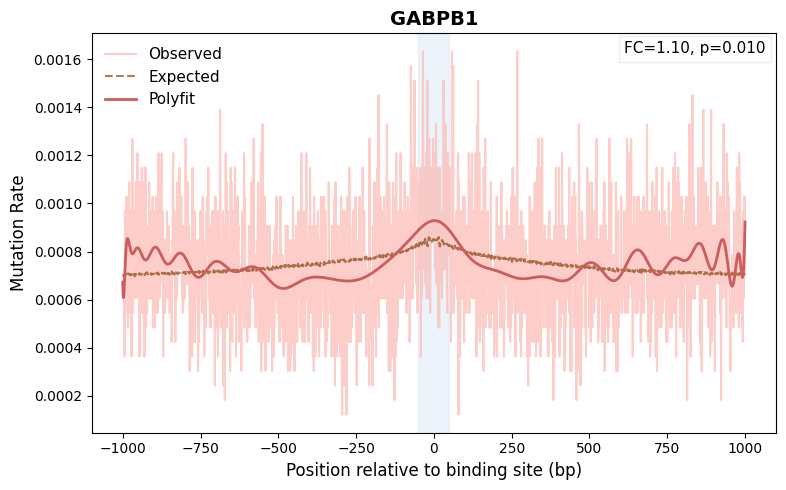

Samples: PCAWG_all_samples Gene: GATA4 Obs Sum: 10266 Exp Sum: 10266.000000000036
FC: 1.4873121595944612 OR1.5291325628845251 Pvalue: 1.1511351314336164e-13
FC core:1.4873121595944612 Pvalue: 1.1511351314336164e-13


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


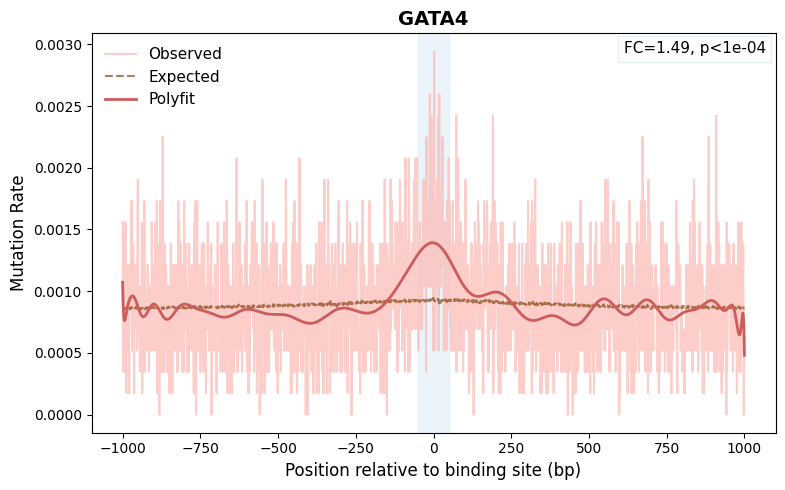

Samples: PCAWG_all_samples Gene: GATAD1 Obs Sum: 27857 Exp Sum: 27857.00000000011
FC: 1.3170316075571122 OR1.3417330378514714 Pvalue: 5.354801287338943e-17
FC core:1.3170316075571122 Pvalue: 5.354801287338943e-17


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


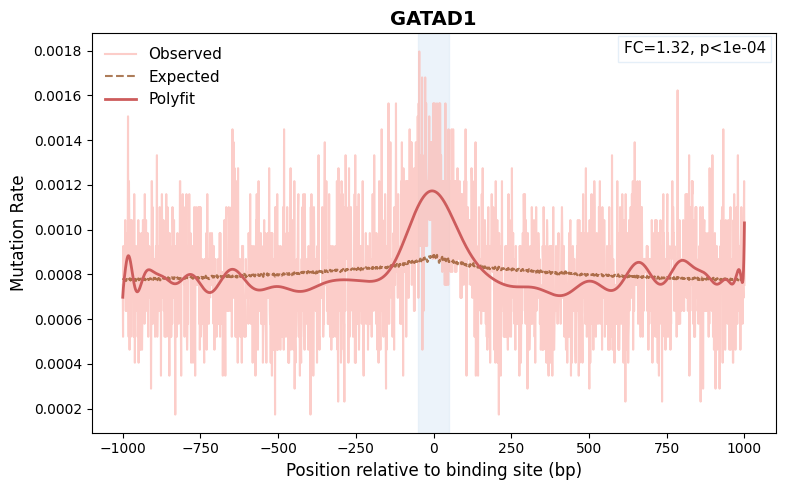

Samples: PCAWG_all_samples Gene: GATAD2A Obs Sum: 67424 Exp Sum: 67424.00000000025
FC: 1.433882442532054 OR1.468564919497518 Pvalue: 1.1698373282597557e-64
FC core:1.433882442532054 Pvalue: 1.1698373282597557e-64


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


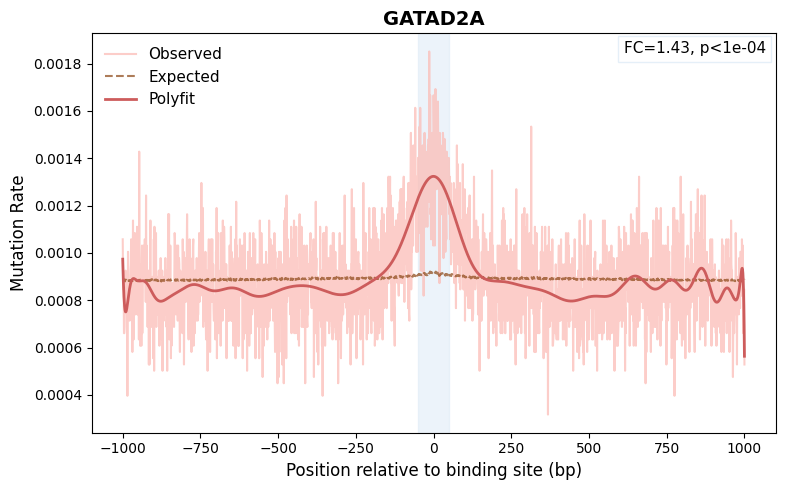

Samples: PCAWG_all_samples Gene: GMEB2 Obs Sum: 5341 Exp Sum: 5341.000000000021
FC: 1.0919496658516805 OR1.0984763332084426 Pvalue: 0.25946973743591806
FC core:1.0919496658516805 Pvalue: 0.25946973743591806


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


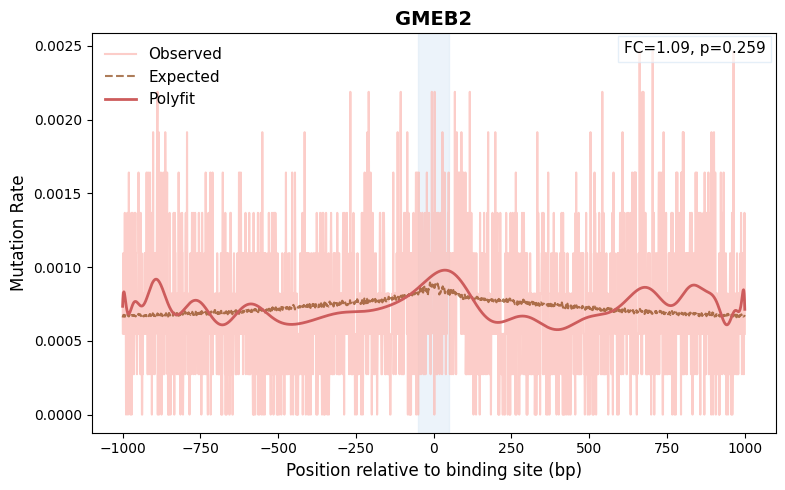

Samples: PCAWG_all_samples Gene: HBP1 Obs Sum: 11610 Exp Sum: 11610.000000000044
FC: 1.2098010729774682 OR1.2258807516231396 Pvalue: 0.00024798418663283
FC core:1.2098010729774682 Pvalue: 0.00024798418663283


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


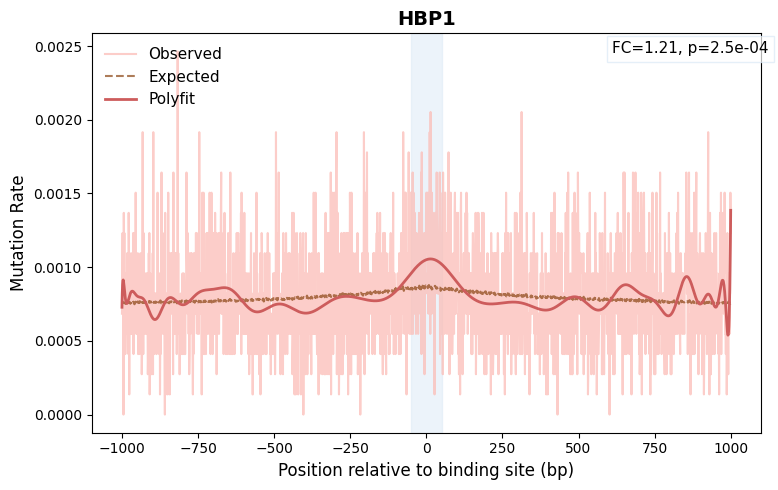

Samples: PCAWG_all_samples Gene: HCFC1 Obs Sum: 6655 Exp Sum: 6655.000000000023
FC: 1.0580752610394928 OR1.06441783933158 Pvalue: 0.417158662665427
FC core:1.0580752610394928 Pvalue: 0.417158662665427


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


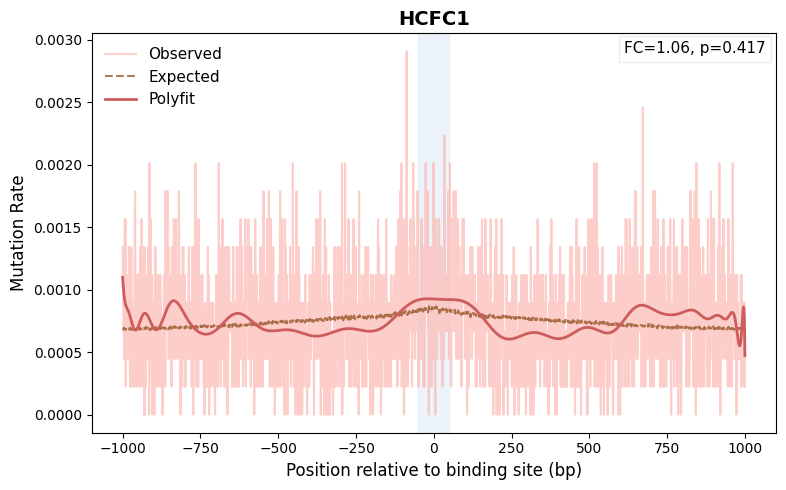

Samples: PCAWG_all_samples Gene: HDAC2 Obs Sum: 21052 Exp Sum: 21052.000000000076
FC: 1.409136685898271 OR1.4422098287315692 Pvalue: 2.573534012974167e-19
FC core:1.409136685898271 Pvalue: 2.573534012974167e-19


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


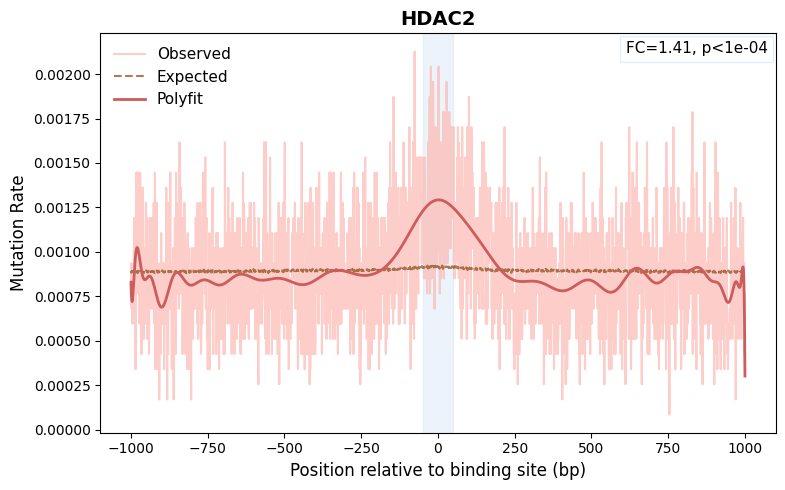

Samples: PCAWG_all_samples Gene: HHEX Obs Sum: 11869 Exp Sum: 11869.000000000036
FC: 1.4822947757497469 OR1.5236035060708848 Pvalue: 6.6736693055450835e-15
FC core:1.4822947757497469 Pvalue: 6.6736693055450835e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


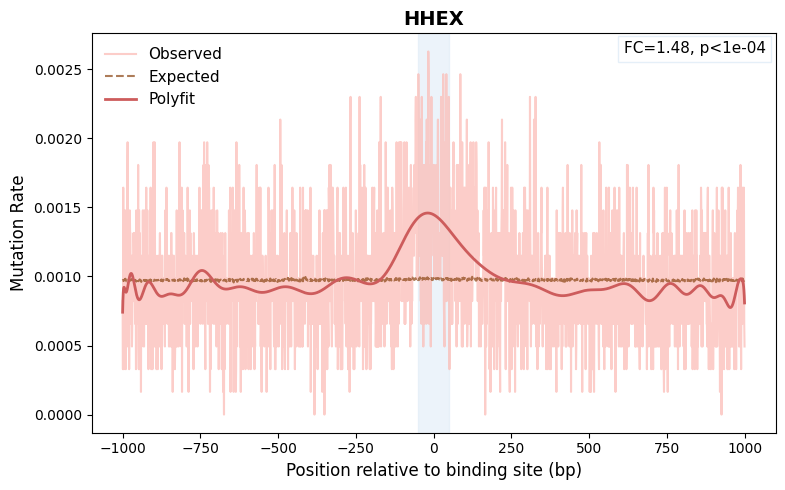

Samples: PCAWG_all_samples Gene: HLF Obs Sum: 118302 Exp Sum: 118302.00000000029
FC: 1.0852073273754095 OR1.0901871872126865 Pvalue: 2.6446214702783776e-06
FC core:1.0852073273754095 Pvalue: 2.6446214702783776e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


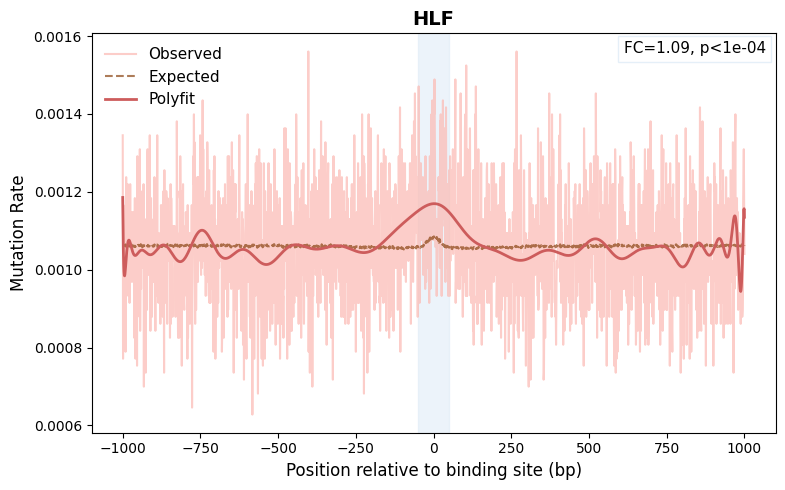

Samples: PCAWG_all_samples Gene: HMG20A Obs Sum: 18945 Exp Sum: 18945.000000000047
FC: 1.4921673963216986 OR1.533048937469521 Pvalue: 1.3703505209890438e-23
FC core:1.4921673963216986 Pvalue: 1.3703505209890438e-23


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


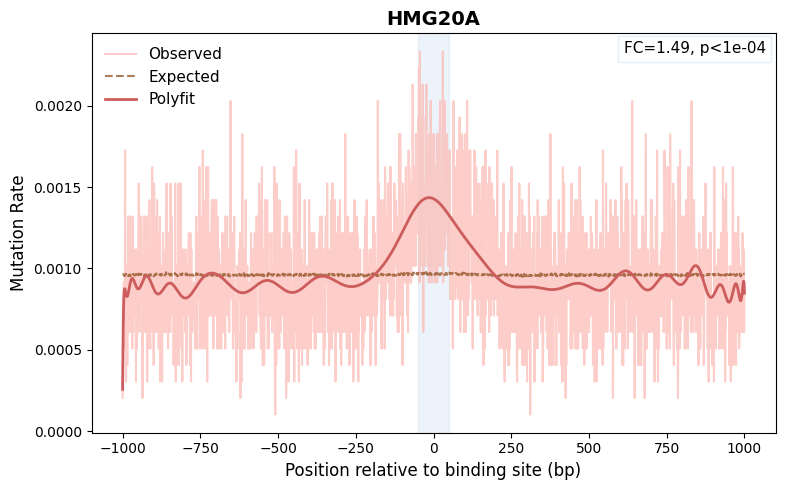

Samples: PCAWG_all_samples Gene: HMG20B Obs Sum: 15264 Exp Sum: 15264.000000000044
FC: 1.4431741900017552 OR1.4789522052906374 Pvalue: 1.6884627884702462e-16
FC core:1.4431741900017552 Pvalue: 1.6884627884702462e-16


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


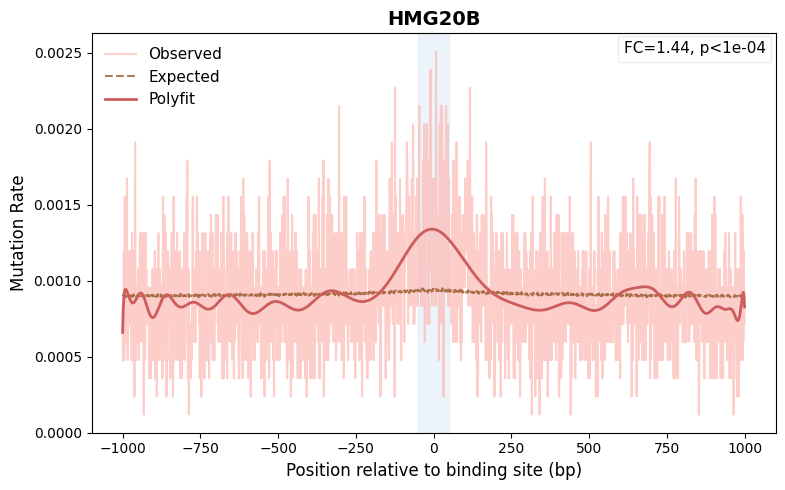

Samples: PCAWG_all_samples Gene: HMGXB3 Obs Sum: 12628 Exp Sum: 12628.000000000051
FC: 1.3191796294781684 OR1.3436999592615448 Pvalue: 1.9721526729227903e-08
FC core:1.3191796294781684 Pvalue: 1.9721526729227903e-08


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


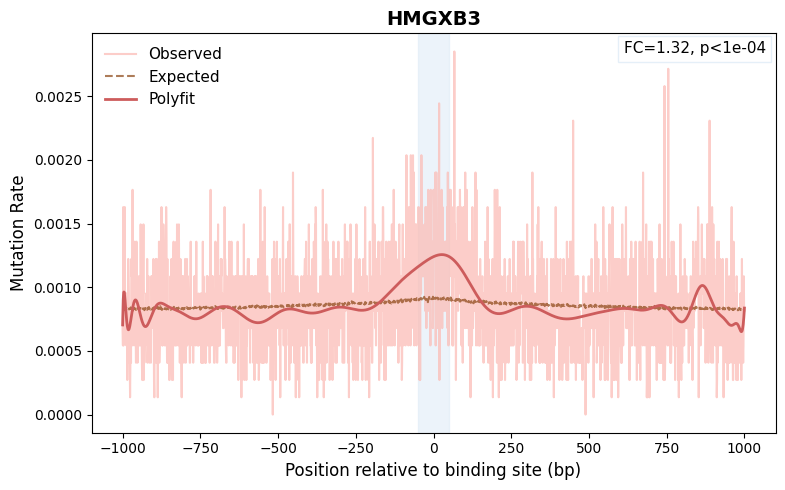

Samples: PCAWG_all_samples Gene: HMGXB4 Obs Sum: 17899 Exp Sum: 17899.00000000005
FC: 1.4716880270166275 OR1.5148668708325401 Pvalue: 8.353616601811627e-23
FC core:1.4716880270166275 Pvalue: 8.353616601811627e-23


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


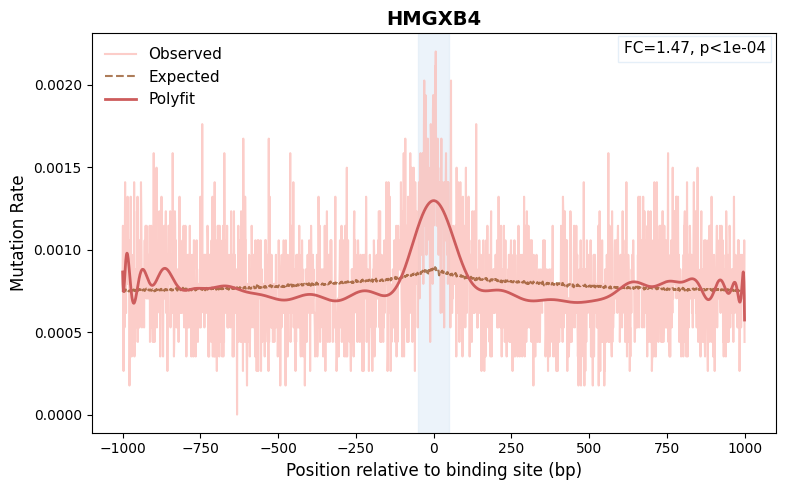

Samples: PCAWG_all_samples Gene: HNF1A Obs Sum: 15872 Exp Sum: 15872.000000000055
FC: 1.5159498374061622 OR1.5589356303564235 Pvalue: 1.5455400960496796e-21
FC core:1.5159498374061622 Pvalue: 1.5455400960496796e-21


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


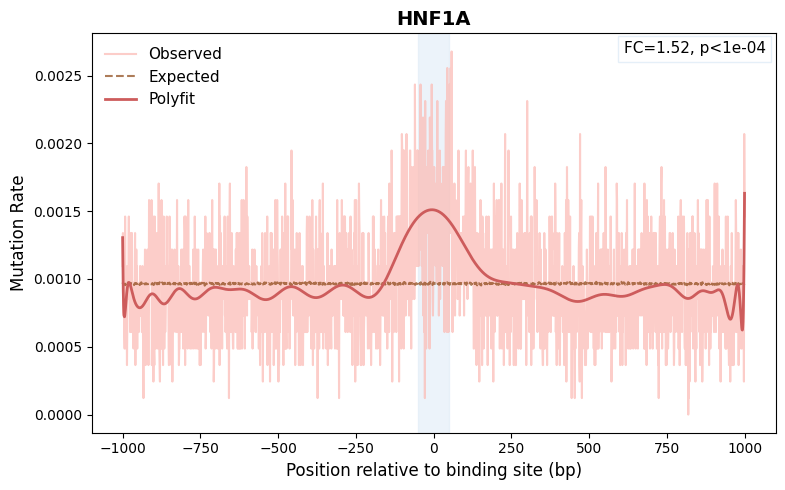

Samples: PCAWG_all_samples Gene: HNF4A Obs Sum: 34259 Exp Sum: 34259.000000000095
FC: 1.395941691411937 OR1.4263195359729843 Pvalue: 2.783355517102011e-28
FC core:1.395941691411937 Pvalue: 2.783355517102011e-28


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


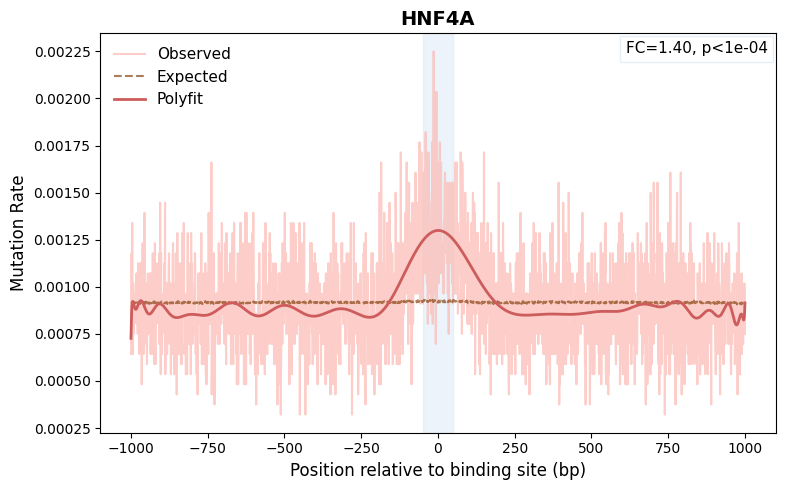

Samples: PCAWG_all_samples Gene: HNF4G Obs Sum: 26584 Exp Sum: 26584.00000000008
FC: 1.3911075099002008 OR1.4210091328772803 Pvalue: 7.846176051562939e-22
FC core:1.3911075099002008 Pvalue: 7.846176051562939e-22


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


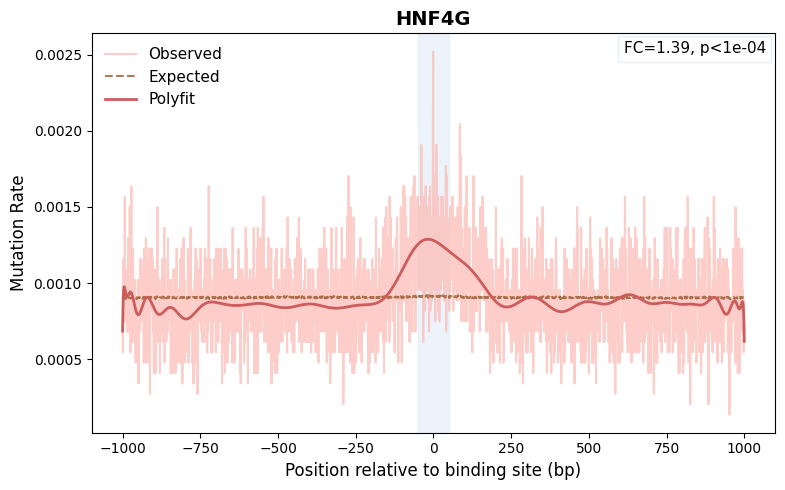

Samples: PCAWG_all_samples Gene: HOMEZ Obs Sum: 23586 Exp Sum: 23586.000000000084
FC: 1.3348481840910542 OR1.360085252420103 Pvalue: 1.9116340416615777e-15
FC core:1.3348481840910542 Pvalue: 1.9116340416615777e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


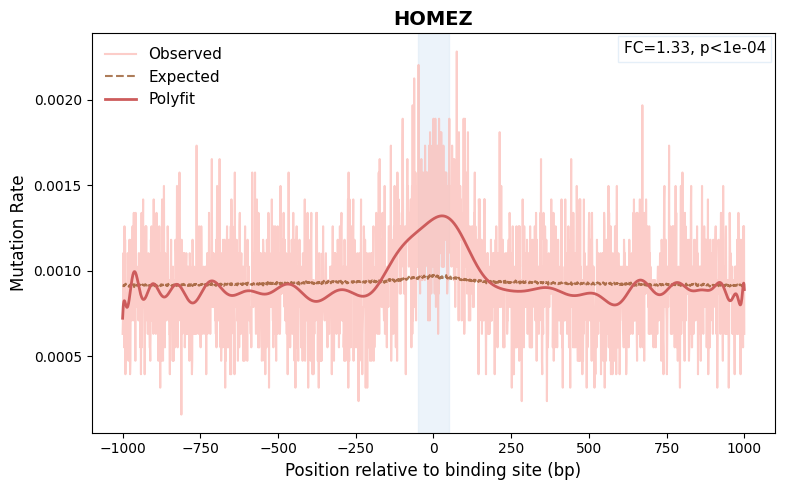

Samples: PCAWG_all_samples Gene: HSF1 Obs Sum: 1819 Exp Sum: 1819.0000000000064
FC: 1.8368332590547107 OR1.939398470010715 Pvalue: 2.707121347325057e-07
FC core:1.8368332590547107 Pvalue: 2.707121347325057e-07


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


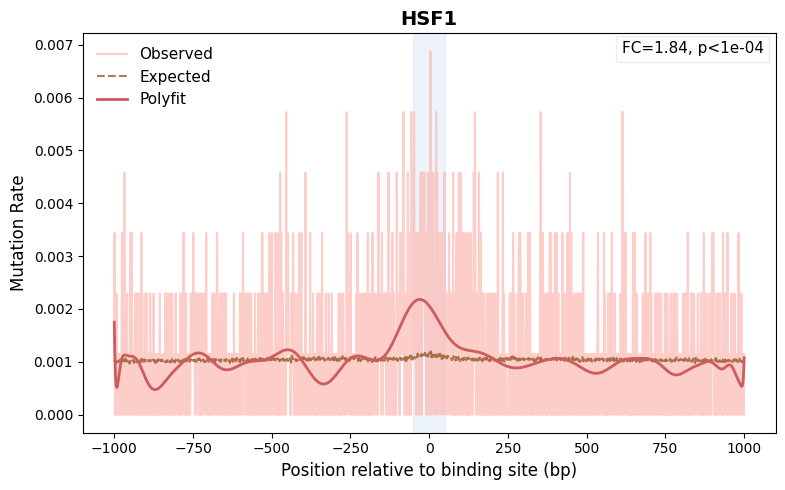

Samples: PCAWG_all_samples Gene: IRF3 Obs Sum: 729 Exp Sum: 729.0000000000025
FC: 1.8421656519687373 OR1.9524570024570025 Pvalue: 0.0016555303561522944
FC core:1.8421656519687373 Pvalue: 0.0016555303561522944


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


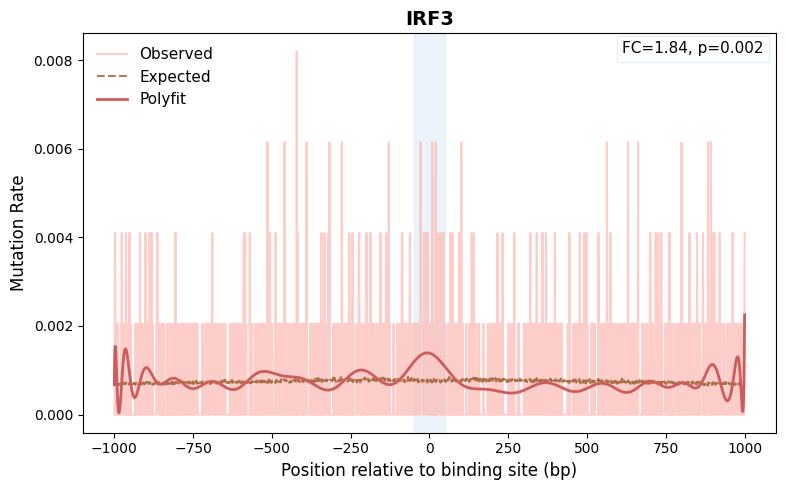

Samples: PCAWG_all_samples Gene: JARID2 Obs Sum: 1162 Exp Sum: 1162.0000000000036
FC: 1.547937060038606 OR1.623168928907405 Pvalue: 0.004233404958649805
FC core:1.547937060038606 Pvalue: 0.004233404958649805


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


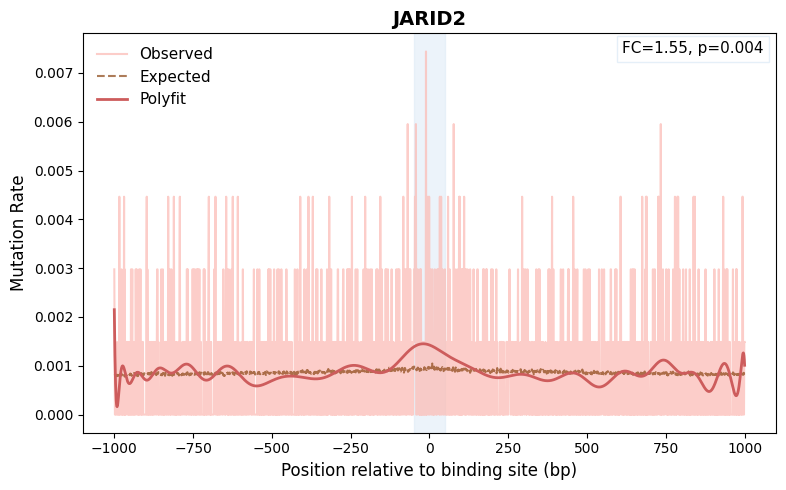

Samples: PCAWG_all_samples Gene: JUN Obs Sum: 23310 Exp Sum: 23310.000000000073
FC: 1.1465685962112555 OR1.1561232463159308 Pvalue: 0.0004134433167107199
FC core:1.1465685962112555 Pvalue: 0.0004134433167107199


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


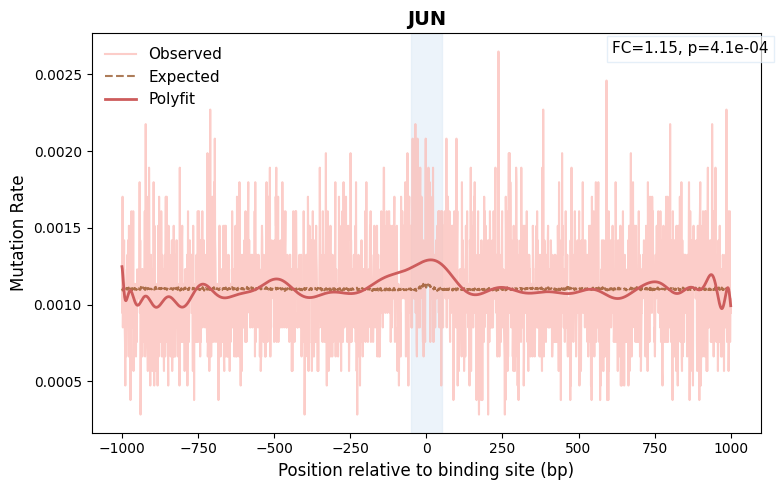

Samples: PCAWG_all_samples Gene: JUND Obs Sum: 64734 Exp Sum: 64734.000000000175
FC: 1.0852093396738332 OR1.0904052741962509 Pvalue: 0.0005116876450693783
FC core:1.0852093396738332 Pvalue: 0.0005116876450693783


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


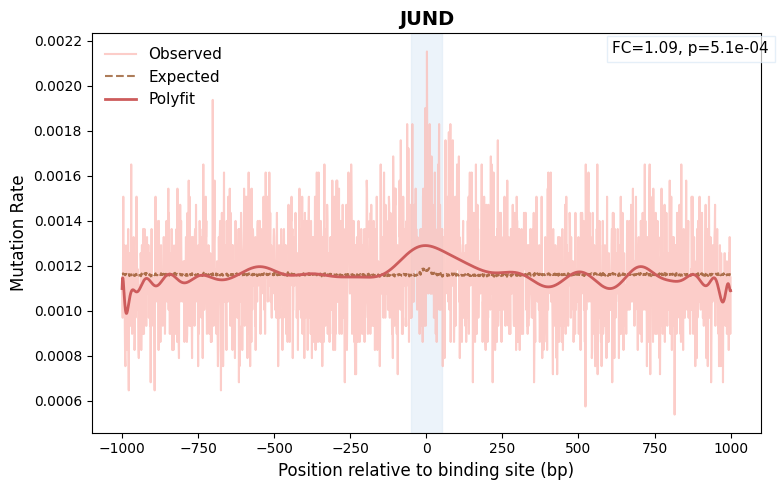

Samples: PCAWG_all_samples Gene: KAT2B Obs Sum: 3088 Exp Sum: 3088.0000000000105
FC: 1.5245557296048489 OR1.5687633432112928 Pvalue: 2.6278494705964515e-05
FC core:1.5245557296048489 Pvalue: 2.6278494705964515e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


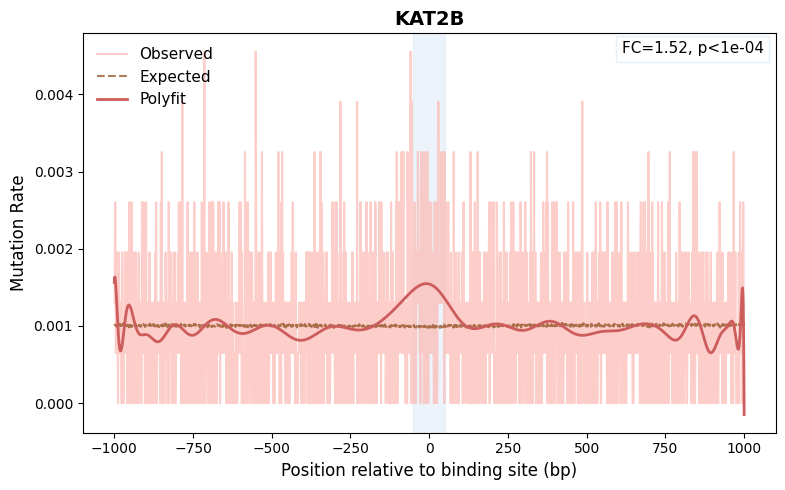

Samples: PCAWG_all_samples Gene: KAT7 Obs Sum: 7268 Exp Sum: 7268.0000000000255
FC: 1.0433021182201705 OR1.0469290277629826 Pvalue: 0.5434206195814947
FC core:1.0433021182201705 Pvalue: 0.5434206195814947


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


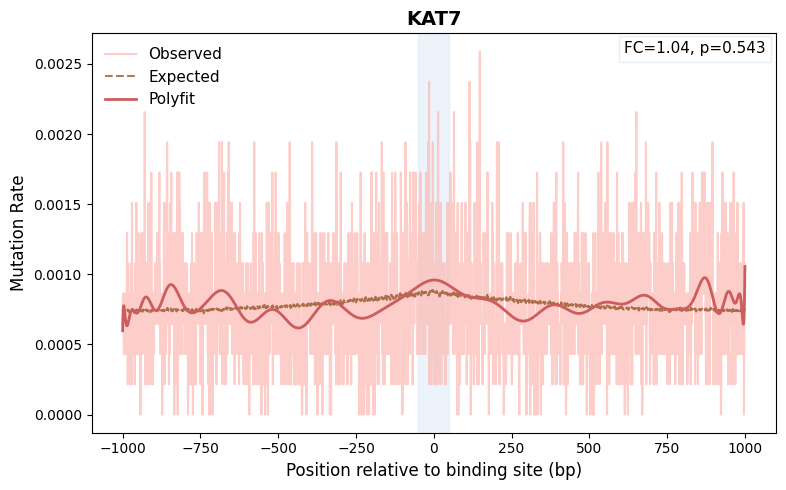

Samples: PCAWG_all_samples Gene: KAT8 Obs Sum: 35201 Exp Sum: 35201.00000000011
FC: 1.3833113816539735 OR1.4142743754583027 Pvalue: 7.995727493208392e-29
FC core:1.3833113816539735 Pvalue: 7.995727493208392e-29


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


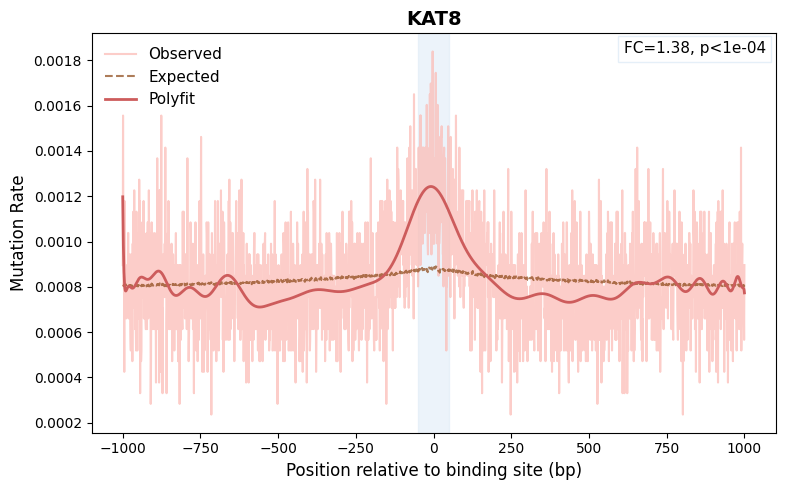

Samples: PCAWG_all_samples Gene: KDM1A Obs Sum: 13633 Exp Sum: 13633.000000000035
FC: 1.2294549473788496 OR1.2461036885858614 Pvalue: 3.477355087162014e-05
FC core:1.2294549473788496 Pvalue: 3.477355087162014e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


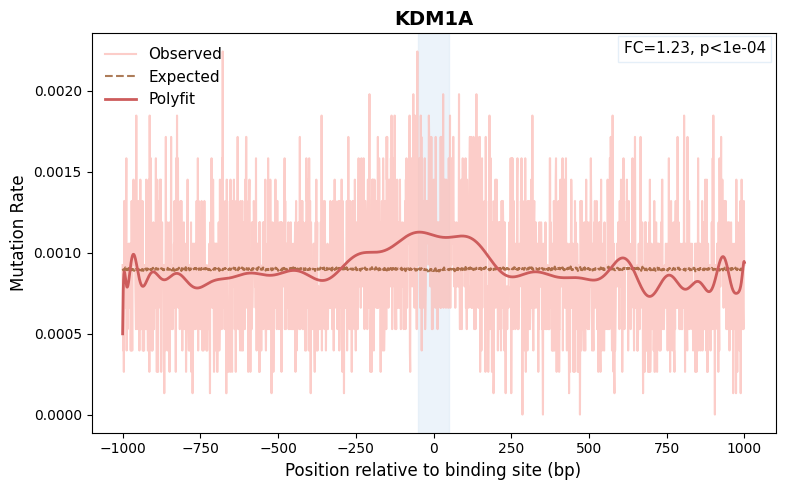

Samples: PCAWG_all_samples Gene: KDM2A Obs Sum: 29832 Exp Sum: 29832.00000000011
FC: 1.370174246466621 OR1.4011735971573287 Pvalue: 2.199870085626137e-24
FC core:1.370174246466621 Pvalue: 2.199870085626137e-24


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


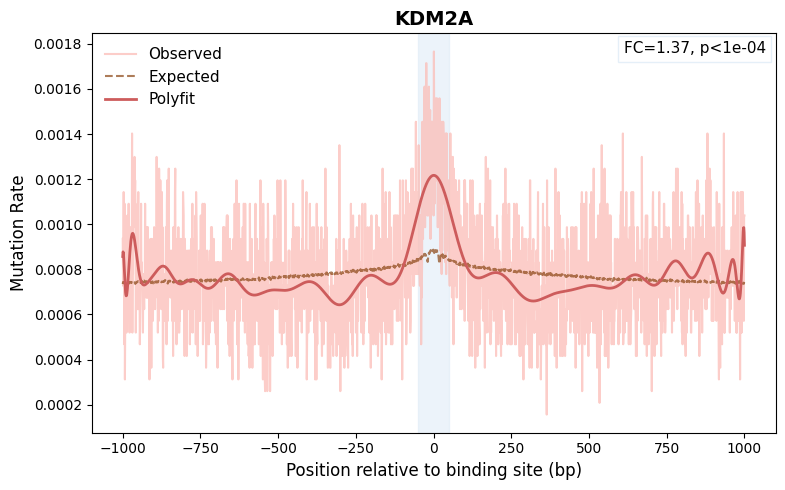

Samples: PCAWG_all_samples Gene: KDM3A Obs Sum: 11103 Exp Sum: 11103.000000000033
FC: 1.3493555072356338 OR1.379448464217658 Pvalue: 5.115381353900734e-09
FC core:1.3493555072356338 Pvalue: 5.115381353900734e-09


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


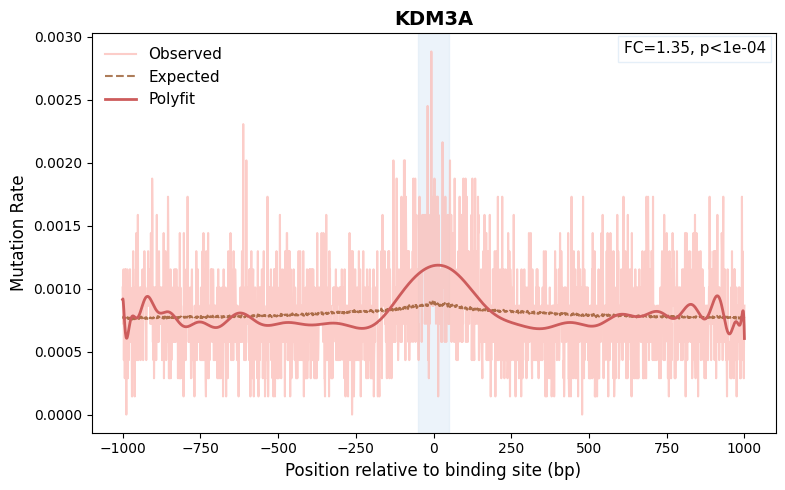

Samples: PCAWG_all_samples Gene: KDM6A Obs Sum: 34152 Exp Sum: 34152.0000000001
FC: 1.7707909247758868 OR1.8488210232297335 Pvalue: 5.1840381709786557e-92
FC core:1.7707909247758868 Pvalue: 5.1840381709786557e-92


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


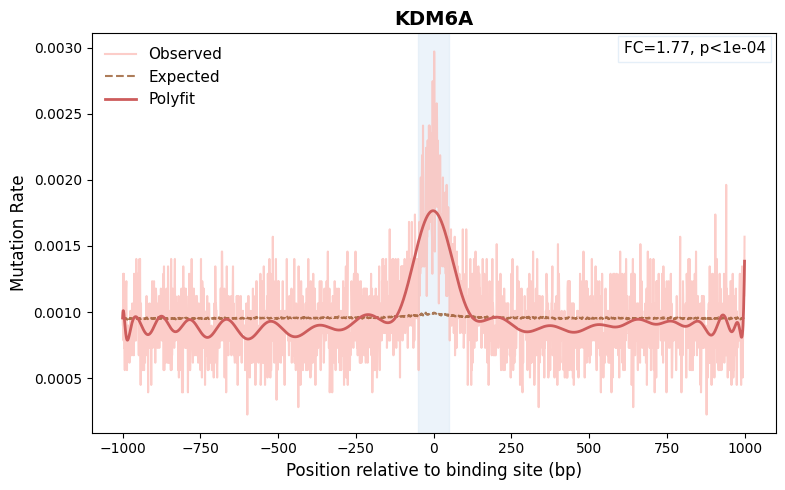

Samples: PCAWG_all_samples Gene: KLF10 Obs Sum: 11711 Exp Sum: 11711.00000000004
FC: 1.218815735012165 OR1.2349394014898956 Pvalue: 0.00013697846106712513
FC core:1.218815735012165 Pvalue: 0.00013697846106712513


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


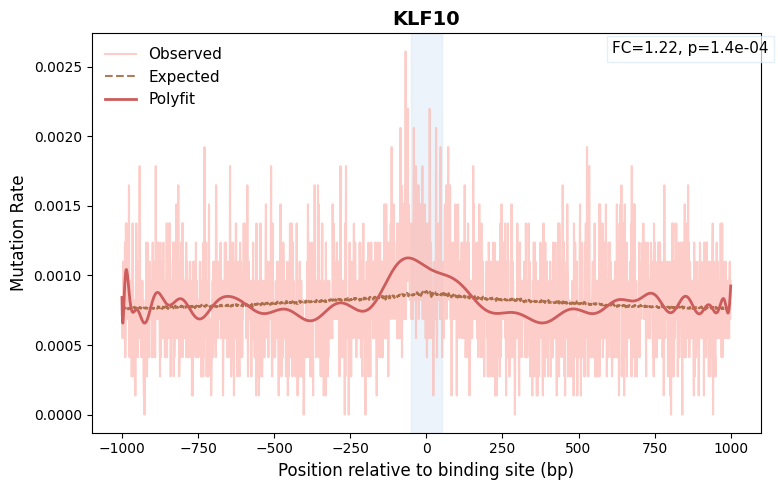

Samples: PCAWG_all_samples Gene: KLF11 Obs Sum: 8583 Exp Sum: 8583.00000000003
FC: 1.419651181340231 OR1.4572825403105056 Pvalue: 1.990388564280953e-09
FC core:1.419651181340231 Pvalue: 1.990388564280953e-09


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


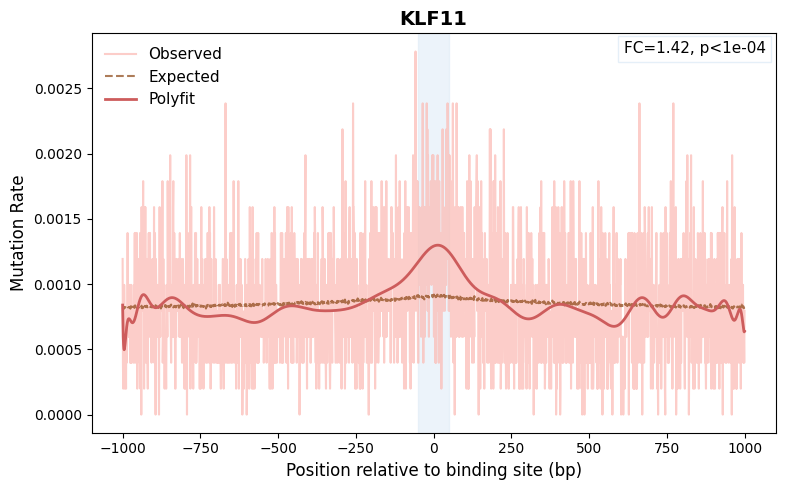

Samples: PCAWG_all_samples Gene: KLF16 Obs Sum: 28920 Exp Sum: 28920.00000000008
FC: 1.448540232493145 OR1.4863651821281532 Pvalue: 1.471404603604031e-31
FC core:1.448540232493145 Pvalue: 1.471404603604031e-31


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


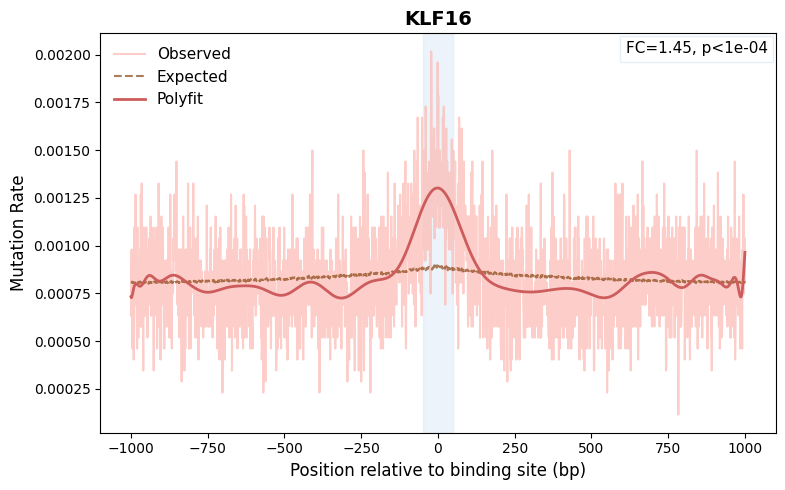

Samples: PCAWG_all_samples Gene: KLF6 Obs Sum: 15103 Exp Sum: 15103.00000000005
FC: 1.3430908850706738 OR1.3714269751971624 Pvalue: 2.6911133472504315e-11
FC core:1.3430908850706738 Pvalue: 2.6911133472504315e-11


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


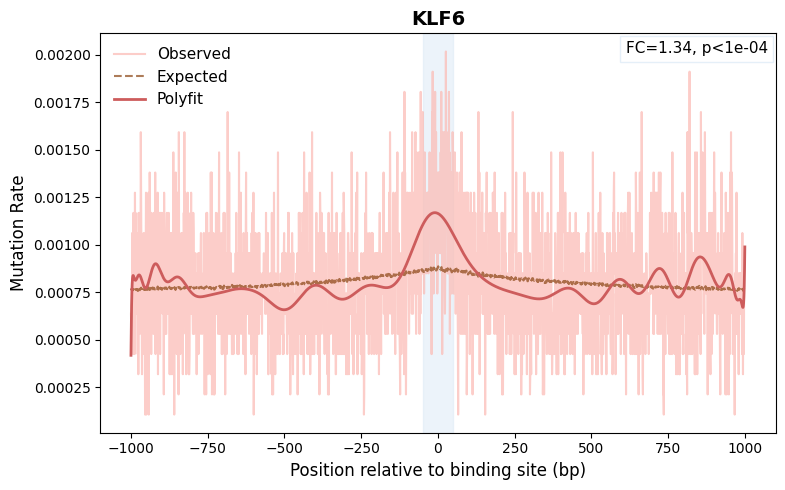

Samples: PCAWG_all_samples Gene: KLF9 Obs Sum: 5459 Exp Sum: 5459.000000000018
FC: 1.3560945784883405 OR1.3850816977794826 Pvalue: 3.971306708305239e-05
FC core:1.3560945784883405 Pvalue: 3.971306708305239e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


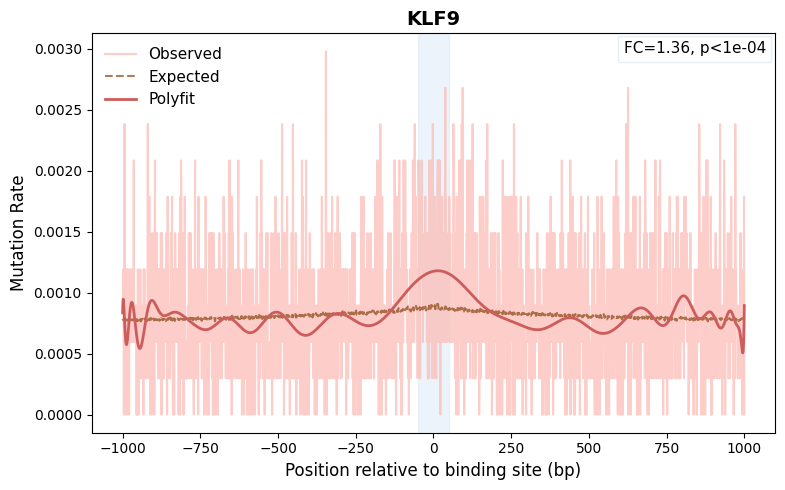

Samples: PCAWG_all_samples Gene: KMT2B Obs Sum: 20119 Exp Sum: 20119.00000000008
FC: 1.2311037575375505 OR1.2478563799838818 Pvalue: 1.2332223603155773e-07
FC core:1.2311037575375505 Pvalue: 1.2332223603155773e-07


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


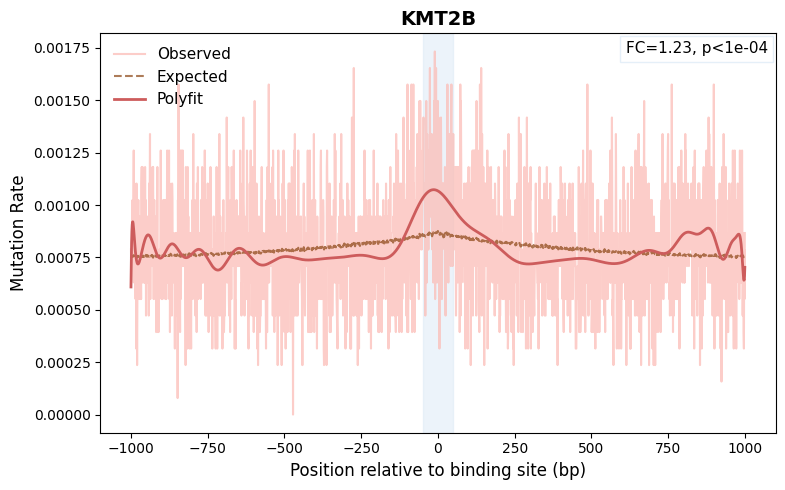

Samples: PCAWG_all_samples Gene: MAFF Obs Sum: 90623 Exp Sum: 90623.0000000002
FC: 1.071384250282413 OR1.0755644754205145 Pvalue: 0.00064034750207958
FC core:1.071384250282413 Pvalue: 0.00064034750207958


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


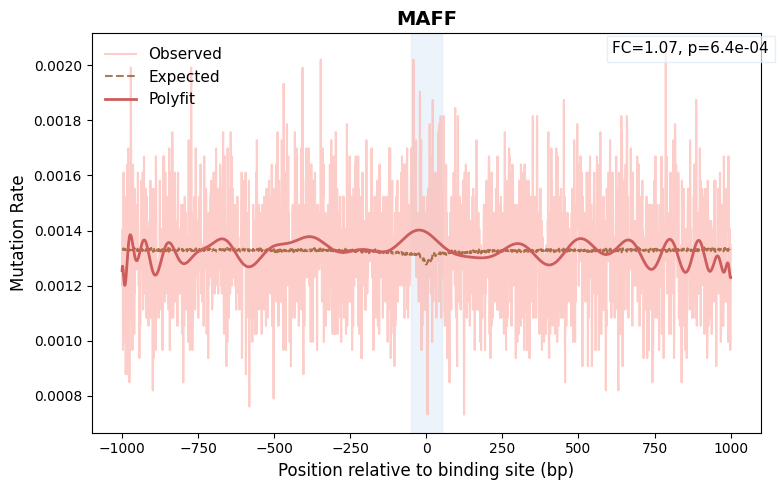

Samples: PCAWG_all_samples Gene: MAFK Obs Sum: 167620 Exp Sum: 167620.00000000081
FC: 1.0252957305010446 OR1.0267232034158886 Pvalue: 0.09685763620396118
FC core:1.0252957305010446 Pvalue: 0.09685763620396118


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


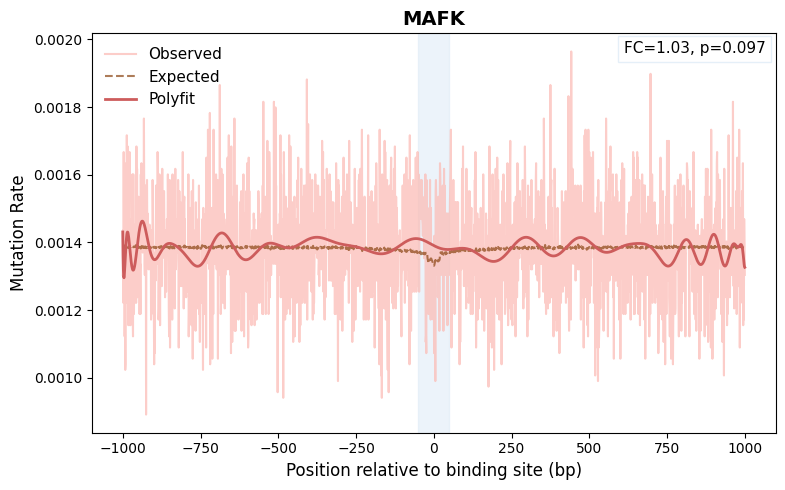

Samples: PCAWG_all_samples Gene: MAX Obs Sum: 26260 Exp Sum: 26260.000000000073
FC: 1.1333604920442288 OR1.1426825277643922 Pvalue: 0.00034662865259651397
FC core:1.1333604920442288 Pvalue: 0.00034662865259651397


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


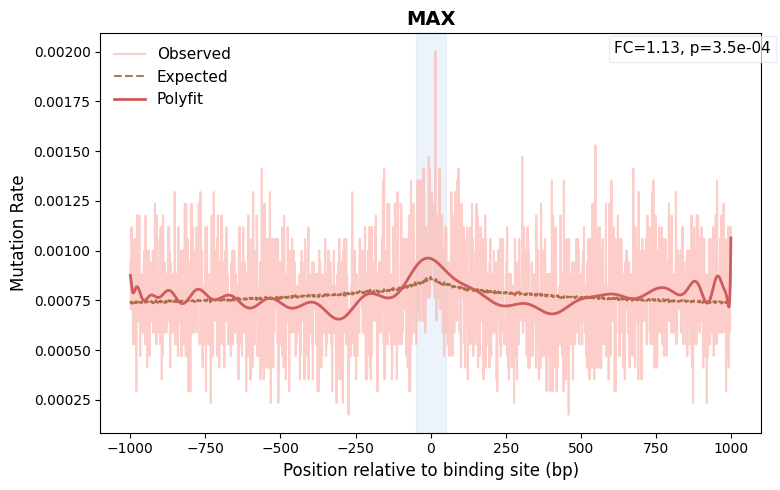

Samples: PCAWG_all_samples Gene: MAZ Obs Sum: 12098 Exp Sum: 12098.000000000031
FC: 1.0623596242020248 OR1.0668833419423216 Pvalue: 0.24891018497241746
FC core:1.0623596242020248 Pvalue: 0.24891018497241746


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


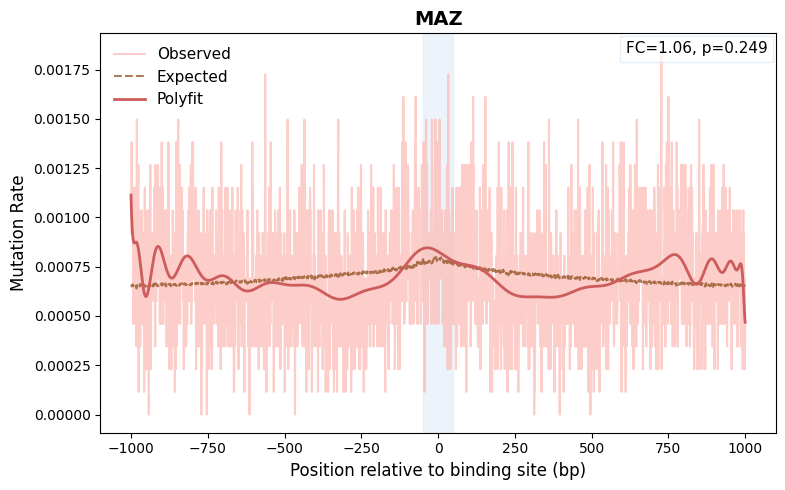

Samples: PCAWG_all_samples Gene: MBD1 Obs Sum: 9063 Exp Sum: 9063.00000000003
FC: 1.6407373593414485 OR1.7051264526653713 Pvalue: 1.4052573549790818e-19
FC core:1.6407373593414485 Pvalue: 1.4052573549790818e-19


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


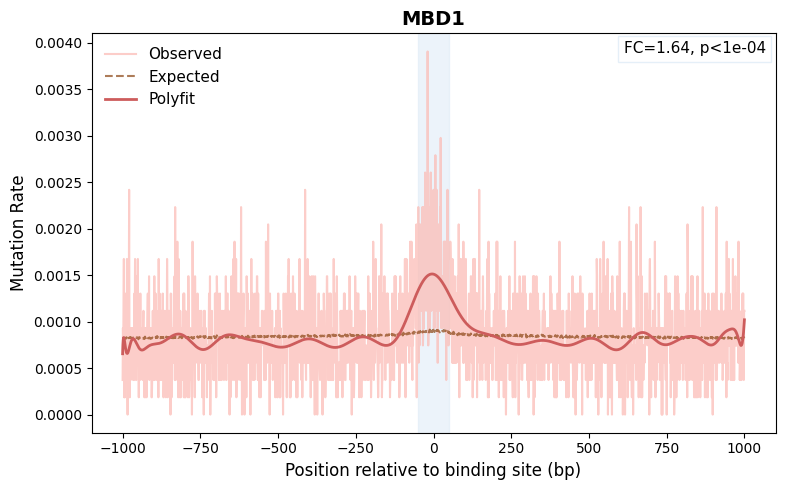

Samples: PCAWG_all_samples Gene: MBD1v2 Obs Sum: 12169 Exp Sum: 12169.000000000042
FC: 1.4293672428167292 OR1.4653432078234334 Pvalue: 2.687512440655271e-13
FC core:1.4293672428167292 Pvalue: 2.687512440655271e-13


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


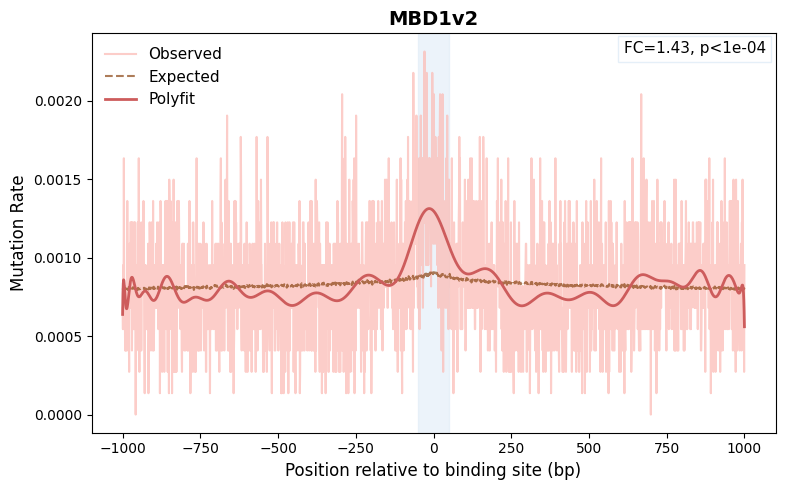

Samples: PCAWG_all_samples Gene: MBD4 Obs Sum: 7619 Exp Sum: 7619.0000000000255
FC: 1.4932980341211592 OR1.5356642031457268 Pvalue: 1.76141268086242e-10
FC core:1.4932980341211592 Pvalue: 1.76141268086242e-10


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


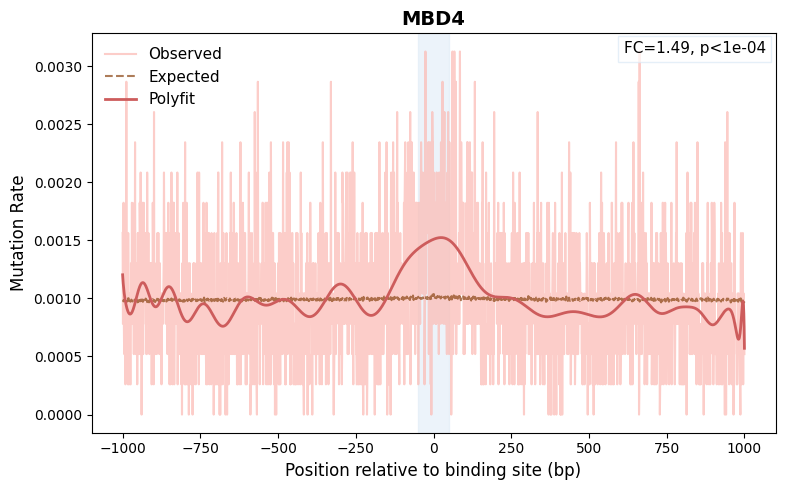

Samples: PCAWG_all_samples Gene: MIER2 Obs Sum: 19054 Exp Sum: 19054.00000000005
FC: 1.354934505241989 OR1.3828683976705993 Pvalue: 3.3828666074338673e-14
FC core:1.354934505241989 Pvalue: 3.3828666074338673e-14


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


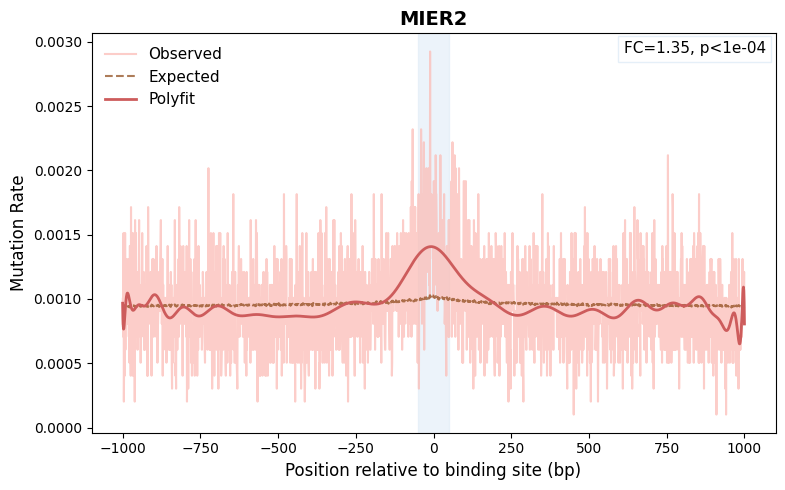

Samples: PCAWG_all_samples Gene: MIER3 Obs Sum: 13799 Exp Sum: 13799.000000000051
FC: 1.4369605285530076 OR1.474640067086299 Pvalue: 4.1229899687833165e-15
FC core:1.4369605285530076 Pvalue: 4.1229899687833165e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


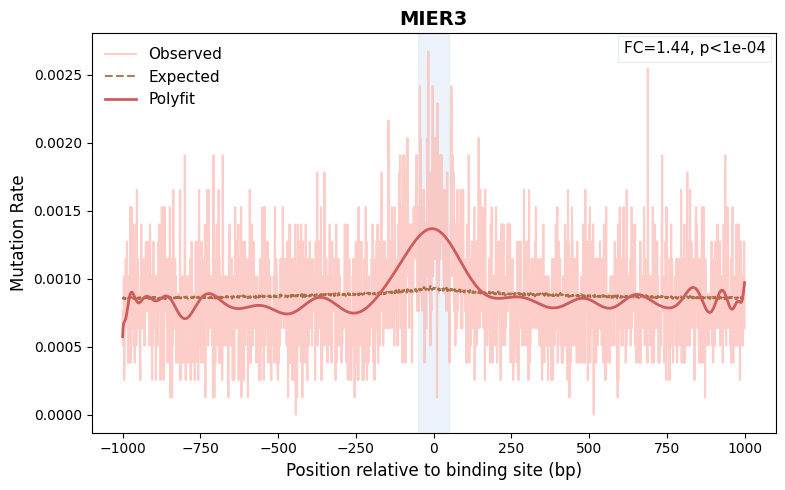

Samples: PCAWG_all_samples Gene: MIXL1 Obs Sum: 33186 Exp Sum: 33186.00000000012
FC: 1.5447831163444863 OR1.5927804364121692 Pvalue: 5.929262883274071e-49
FC core:1.5447831163444863 Pvalue: 5.929262883274071e-49


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


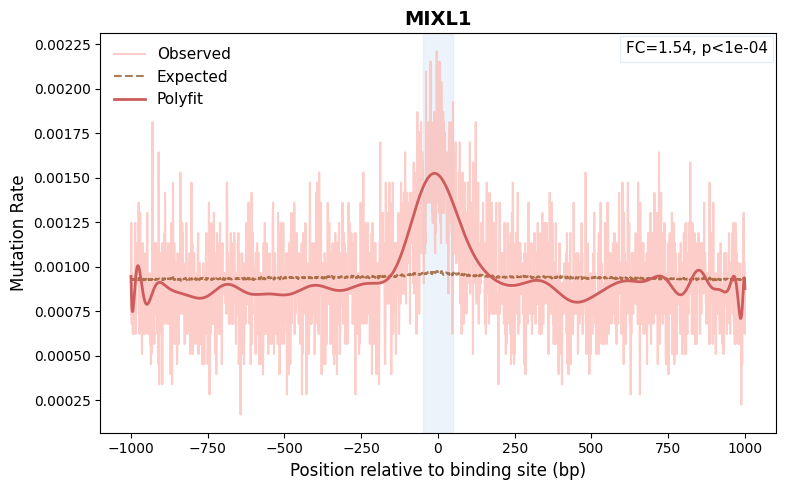

Samples: PCAWG_all_samples Gene: MLX Obs Sum: 17224 Exp Sum: 17224.000000000044
FC: 1.4405628598573335 OR1.4781315214905293 Pvalue: 1.4200499267297577e-18
FC core:1.4405628598573335 Pvalue: 1.4200499267297577e-18


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


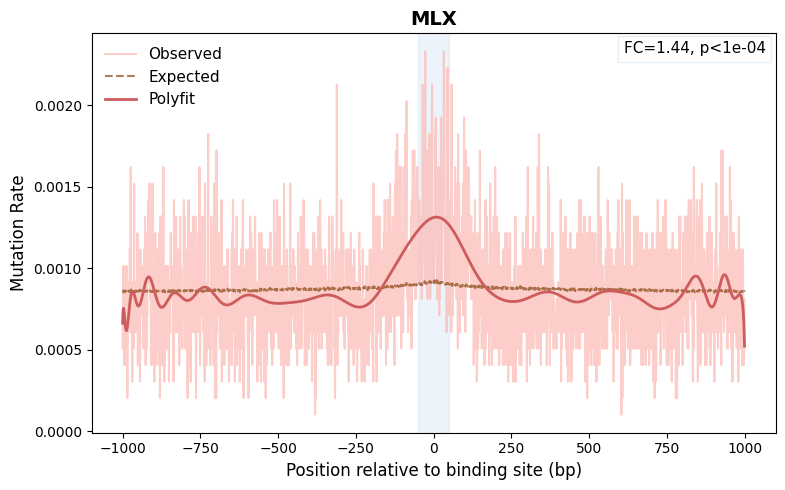

Samples: PCAWG_all_samples Gene: MTA1 Obs Sum: 4185 Exp Sum: 4185.000000000013
FC: 1.3764425734903436 OR1.4096130521994683 Pvalue: 0.00018028193010376128
FC core:1.3764425734903436 Pvalue: 0.00018028193010376128


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


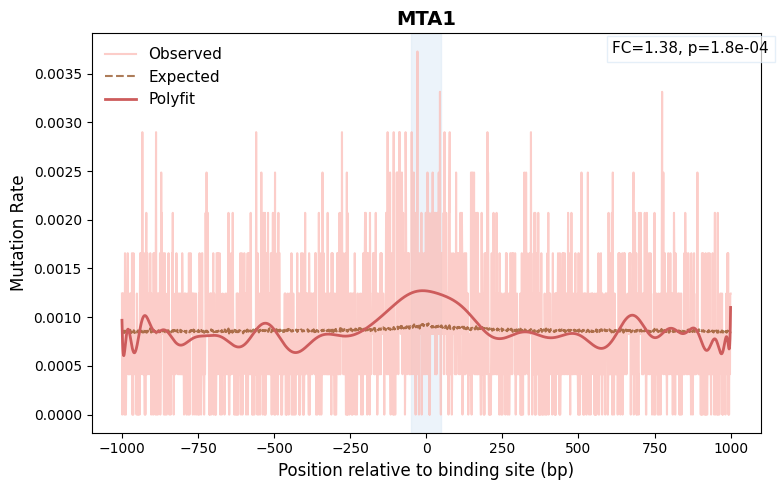

Samples: PCAWG_all_samples Gene: MXD3 Obs Sum: 11562 Exp Sum: 11562.000000000038
FC: 1.0555929850902048 OR1.0593904639852623 Pvalue: 0.3144737244714361
FC core:1.0555929850902048 Pvalue: 0.3144737244714361


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


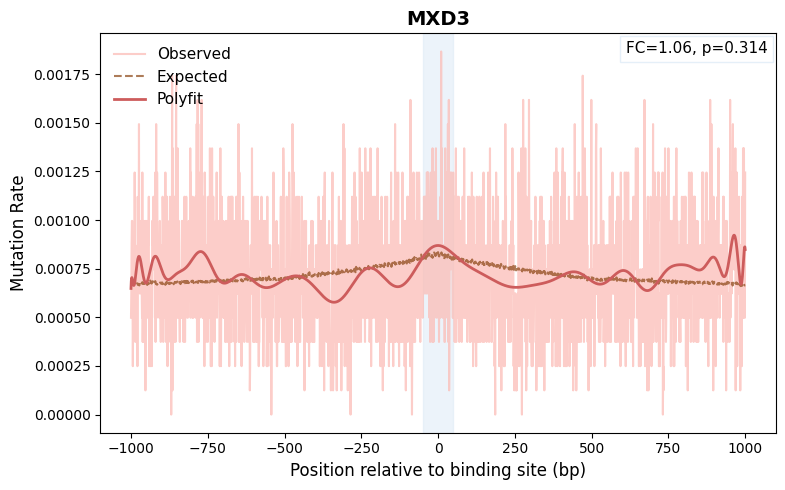

Samples: PCAWG_all_samples Gene: MXD4 Obs Sum: 15872 Exp Sum: 15872.000000000053
FC: 1.219312829929395 OR1.2351374325046534 Pvalue: 7.189994562290788e-06
FC core:1.219312829929395 Pvalue: 7.189994562290788e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


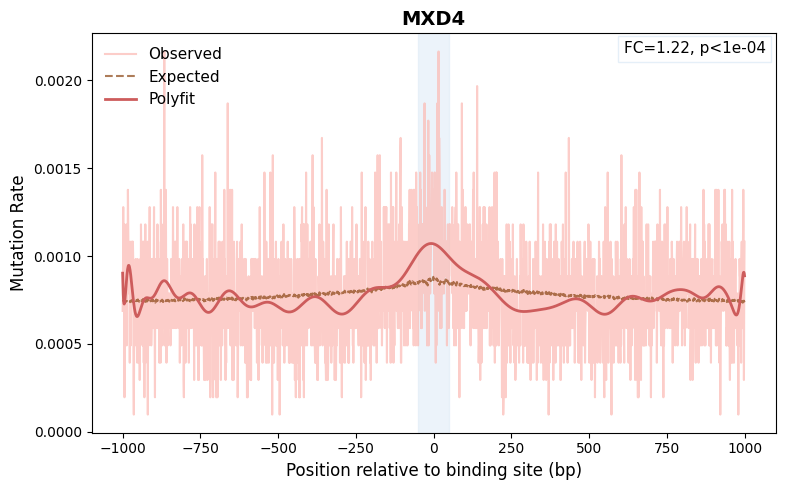

Samples: PCAWG_all_samples Gene: MXI1 Obs Sum: 11071 Exp Sum: 11071.000000000036
FC: 1.2367624315189976 OR1.255431749048988 Pvalue: 4.387845986427651e-05
FC core:1.2367624315189976 Pvalue: 4.387845986427651e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


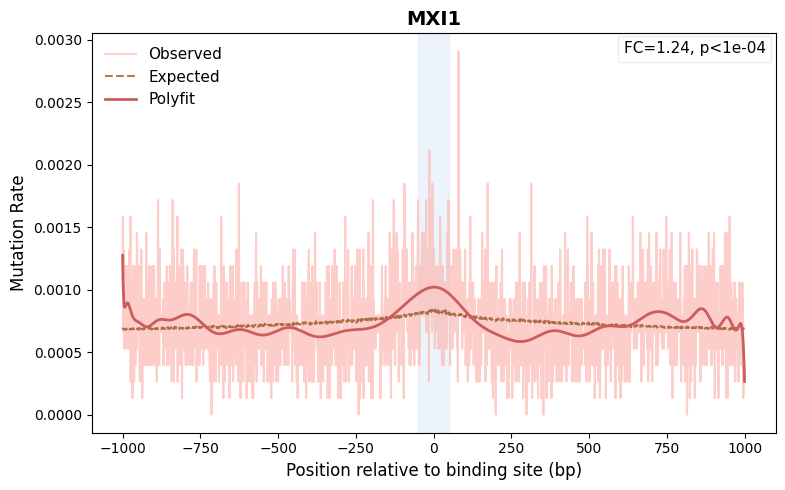

Samples: PCAWG_all_samples Gene: MYBL2 Obs Sum: 21373 Exp Sum: 21373.000000000055
FC: 1.4216373153921504 OR1.455547713822559 Pvalue: 1.0590722574607151e-20
FC core:1.4216373153921504 Pvalue: 1.0590722574607151e-20


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


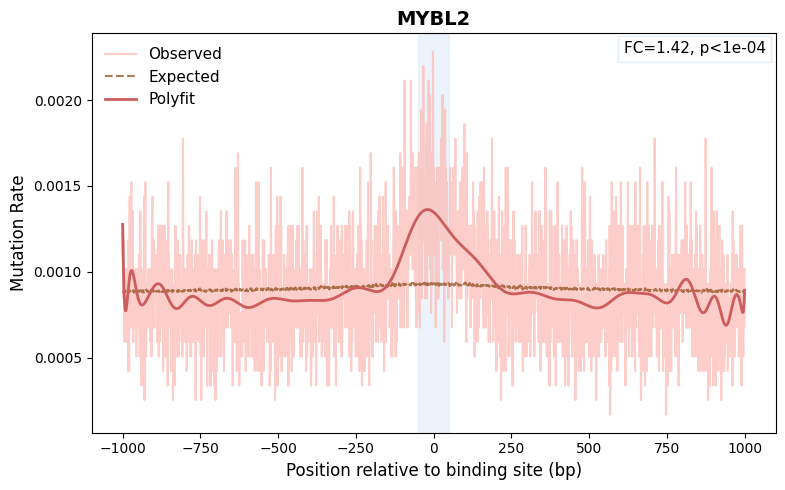

Samples: PCAWG_all_samples Gene: MYC Obs Sum: 1629 Exp Sum: 1629.0000000000052
FC: 1.267478232555836 OR1.2980331718772935 Pvalue: 0.08312526599096835
FC core:1.267478232555836 Pvalue: 0.08312526599096835


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


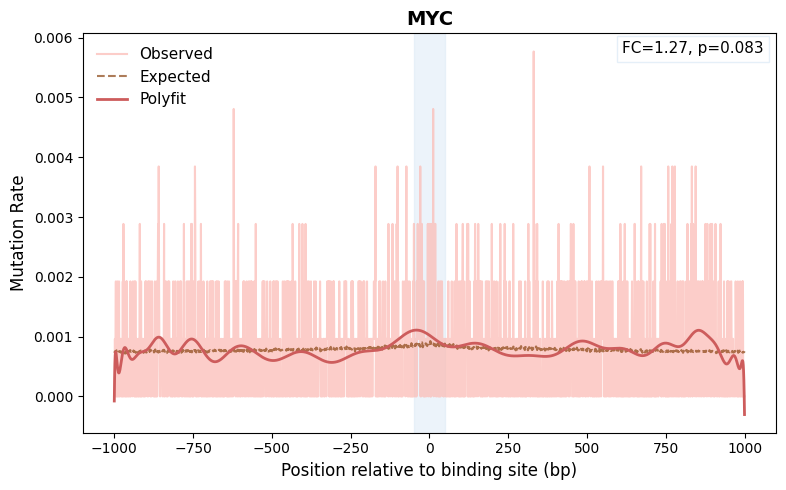

Samples: PCAWG_all_samples Gene: NCoA2 Obs Sum: 11976 Exp Sum: 11976.000000000044
FC: 1.446127214826433 OR1.4827178120138125 Pvalue: 3.516584032952521e-13
FC core:1.446127214826433 Pvalue: 3.516584032952521e-13


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


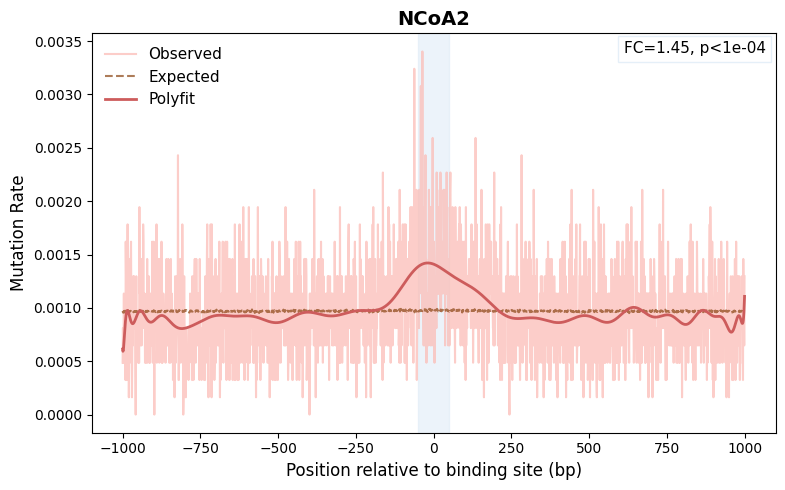

Samples: PCAWG_all_samples Gene: NFE2L2 Obs Sum: 16013 Exp Sum: 16013.000000000062
FC: 1.0131246479577038 OR1.0143655810088443 Pvalue: 0.7985705764253255
FC core:1.0131246479577038 Pvalue: 0.7985705764253255


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


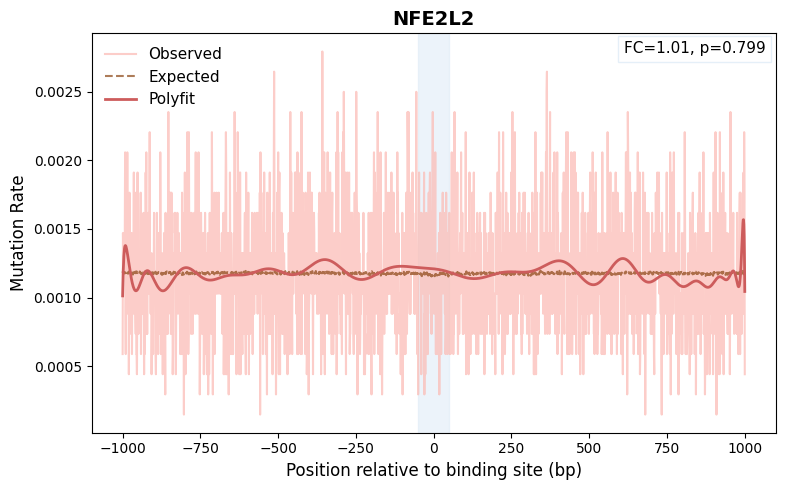

Samples: PCAWG_all_samples Gene: NFIA Obs Sum: 30445 Exp Sum: 30445.000000000065
FC: 1.7996475277767097 OR1.8816708321801259 Pvalue: 3.3998228178081626e-87
FC core:1.7996475277767097 Pvalue: 3.3998228178081626e-87


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


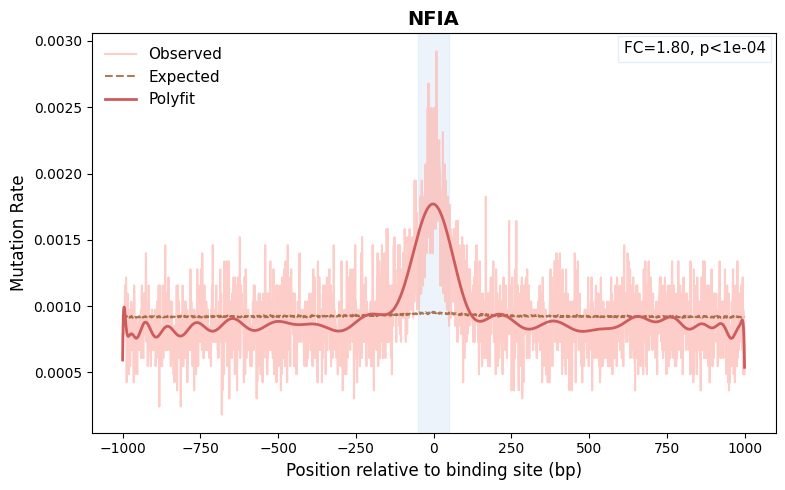

Samples: PCAWG_all_samples Gene: NFIC Obs Sum: 17376 Exp Sum: 17376.000000000065
FC: 1.5675864666599875 OR1.6176058597620533 Pvalue: 7.97958387031266e-28
FC core:1.5675864666599875 Pvalue: 7.97958387031266e-28


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


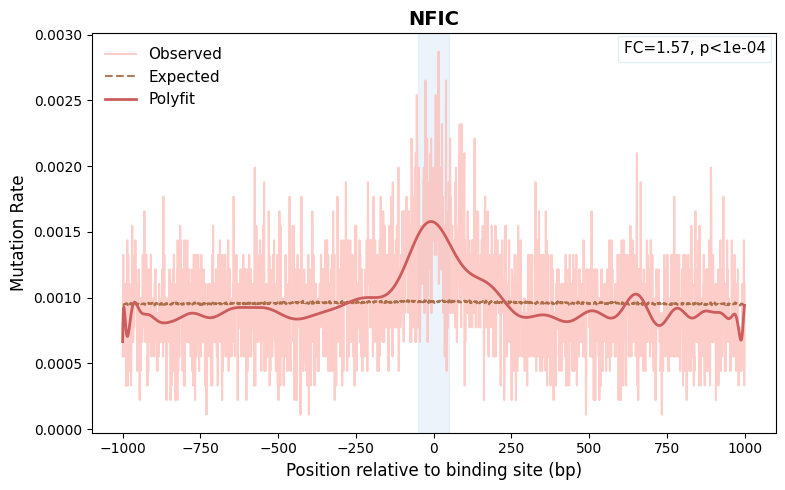

Samples: PCAWG_all_samples Gene: NFIL3 Obs Sum: 48788 Exp Sum: 48788.000000000146
FC: 1.3892826980157076 OR1.4196122881542264 Pvalue: 6.4540744820156e-39
FC core:1.3892826980157076 Pvalue: 6.4540744820156e-39


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


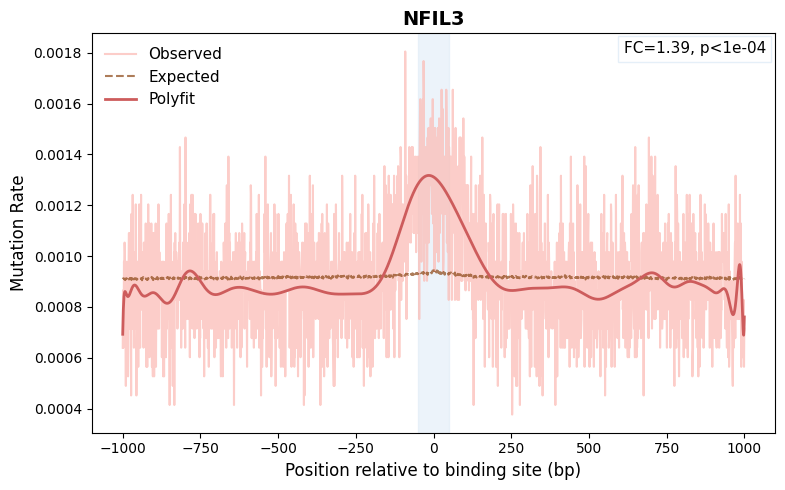

Samples: PCAWG_all_samples Gene: NFYC Obs Sum: 17656 Exp Sum: 17656.00000000005
FC: 1.0750346975034115 OR1.0806216268759872 Pvalue: 0.0993707104327801
FC core:1.0750346975034115 Pvalue: 0.0993707104327801


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


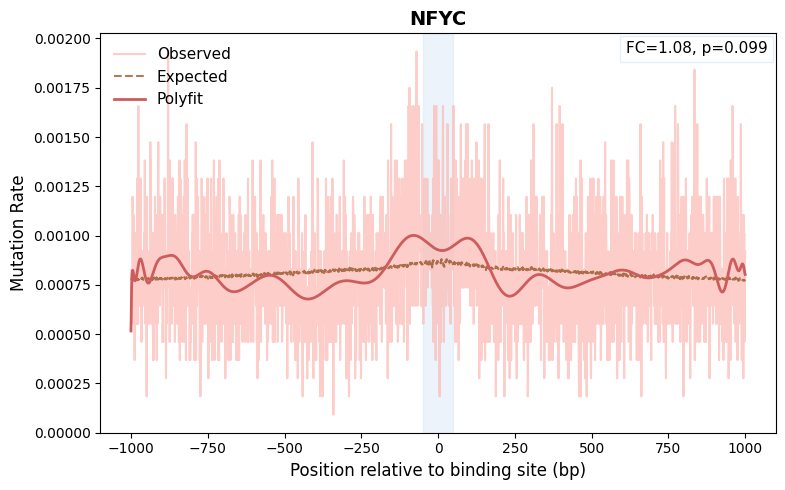

Samples: PCAWG_all_samples Gene: NPAS2 Obs Sum: 1398 Exp Sum: 1398.0000000000048
FC: 1.316759774930866 OR1.3492063492063493 Pvalue: 0.0634493791230169
FC core:1.316759774930866 Pvalue: 0.0634493791230169


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


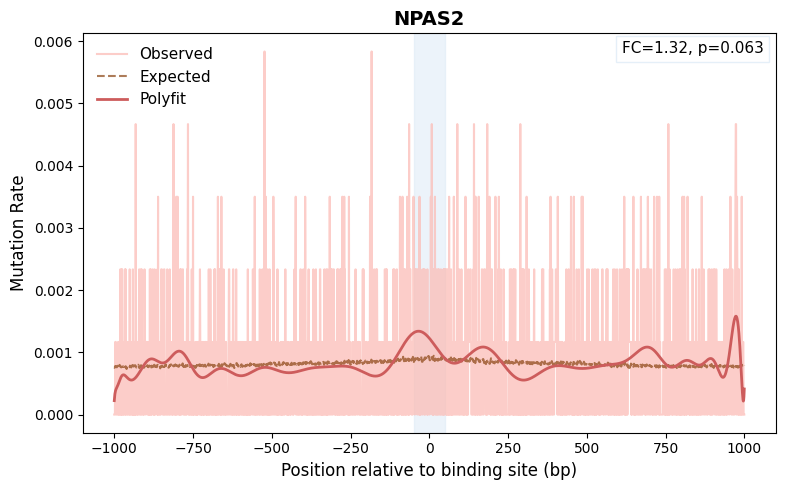

Samples: PCAWG_all_samples Gene: NR1H2 Obs Sum: 2979 Exp Sum: 2979.000000000009
FC: 1.326696818641952 OR1.3508574758574758 Pvalue: 0.0066957309818211595
FC core:1.326696818641952 Pvalue: 0.0066957309818211595


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


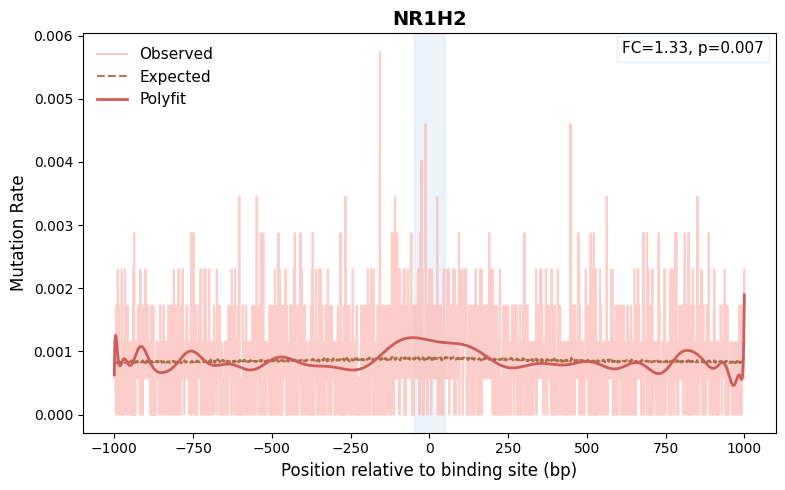

Samples: PCAWG_all_samples Gene: NR2C2 Obs Sum: 3073 Exp Sum: 3073.000000000011
FC: 1.0518248470014409 OR1.0558518638969063 Pvalue: 0.6593169655397229
FC core:1.0518248470014409 Pvalue: 0.6593169655397229


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


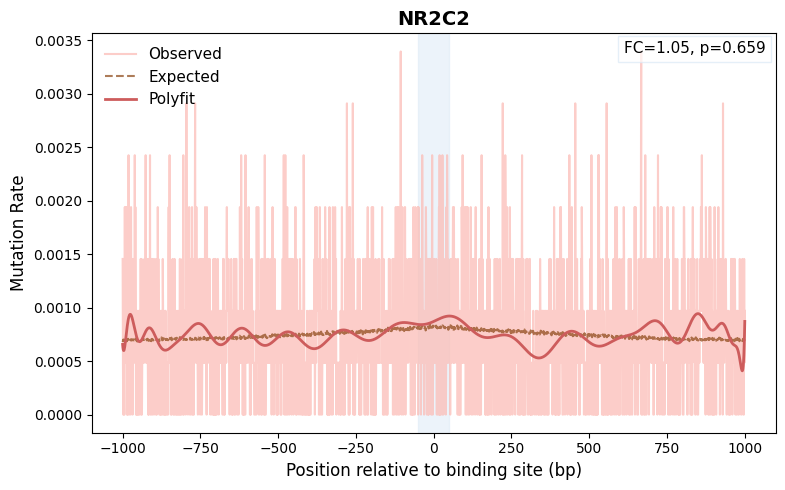

Samples: PCAWG_all_samples Gene: NR2F1 Obs Sum: 14817 Exp Sum: 14817.00000000004
FC: 1.355829946854138 OR1.3826867631320305 Pvalue: 4.046739159526803e-11
FC core:1.355829946854138 Pvalue: 4.046739159526803e-11


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


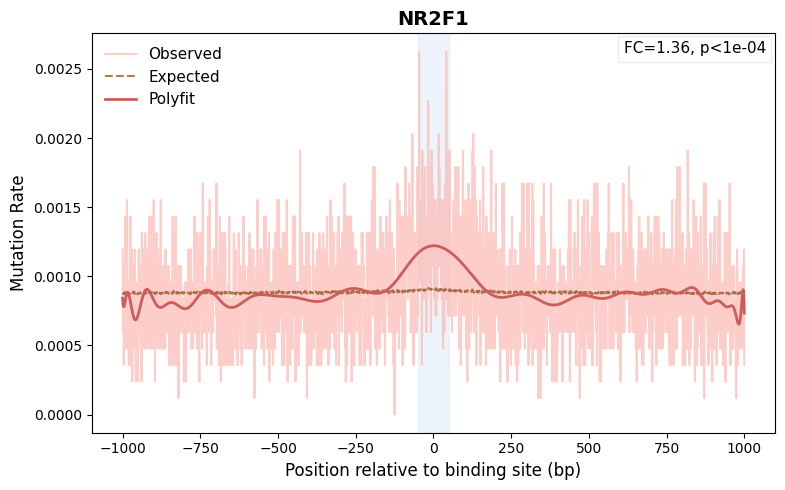

Samples: PCAWG_all_samples Gene: NR2F2 Obs Sum: 14323 Exp Sum: 14323.000000000055
FC: 1.3646195835267099 OR1.3915775115964064 Pvalue: 5.5738907709263394e-11
FC core:1.3646195835267099 Pvalue: 5.5738907709263394e-11


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


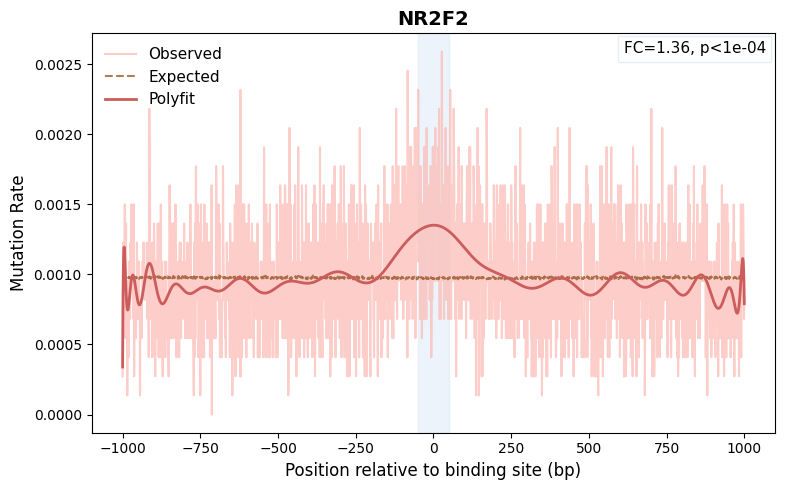

Samples: PCAWG_all_samples Gene: NR2F6 Obs Sum: 45318 Exp Sum: 45318.0000000001
FC: 1.3316136000876688 OR1.3566875517541377 Pvalue: 1.3893009109022186e-27
FC core:1.3316136000876688 Pvalue: 1.3893009109022186e-27


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


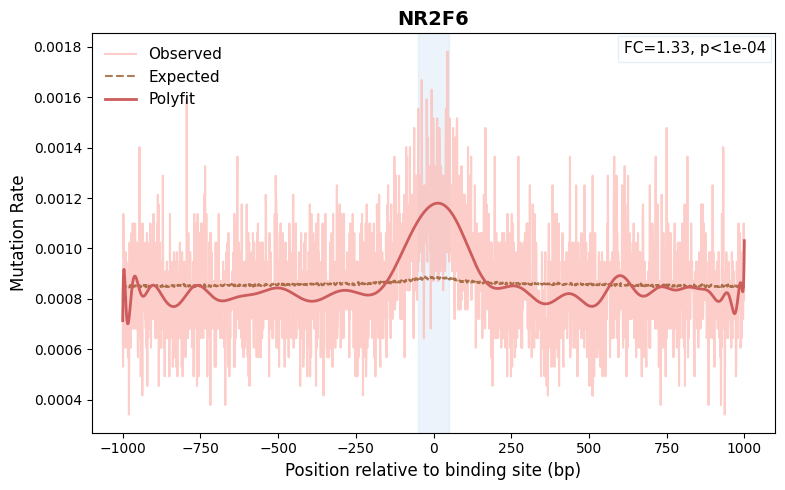

Samples: PCAWG_all_samples Gene: NR3C1 Obs Sum: 127 Exp Sum: 127.00000000000048
FC: 1.2256166843390142 OR1.2966101694915255 Pvalue: 0.7971391411523688
FC core:1.2256166843390142 Pvalue: 0.7971391411523688


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


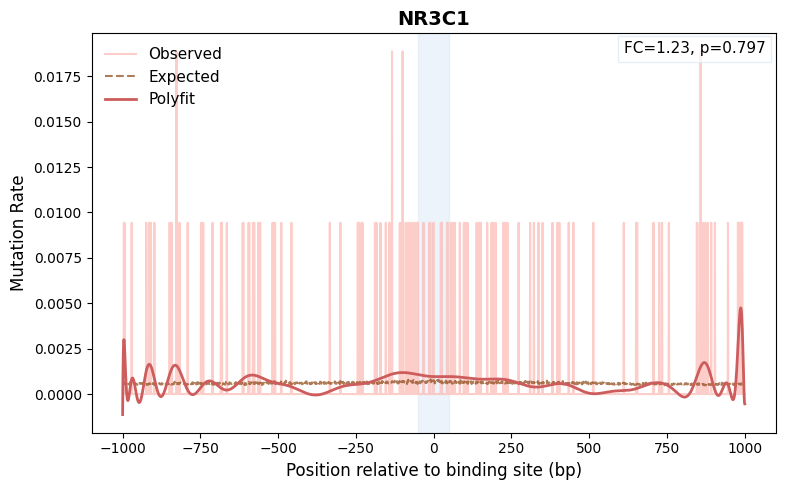

Samples: PCAWG_all_samples Gene: NRF1 Obs Sum: 15830 Exp Sum: 15830.000000000051
FC: 1.0579644921924476 OR1.0617263819805658 Pvalue: 0.22077273722133223
FC core:1.0579644921924476 Pvalue: 0.22077273722133223


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


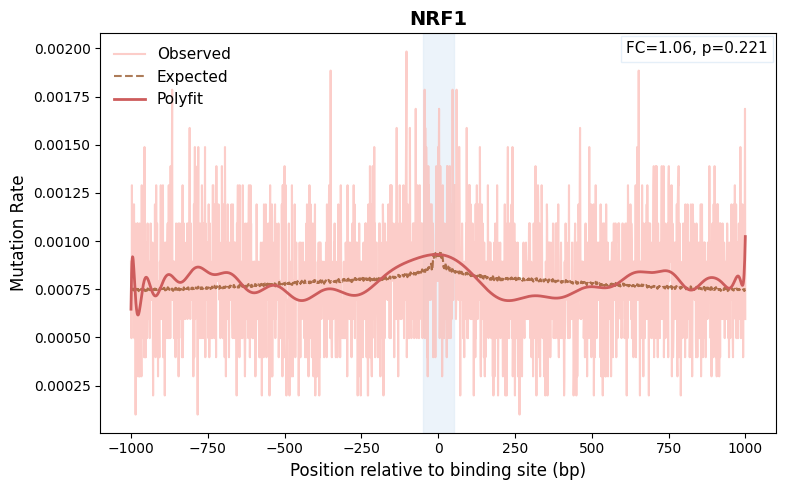

Samples: PCAWG_all_samples Gene: PAF1 Obs Sum: 4485 Exp Sum: 4485.000000000013
FC: 1.048297978937293 OR1.0546758757508403 Pvalue: 0.6036983590390756
FC core:1.048297978937293 Pvalue: 0.6036983590390756


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


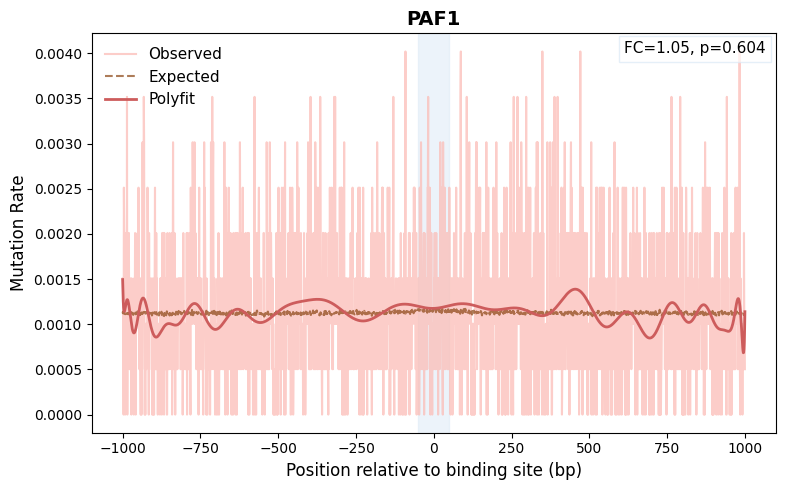

Samples: PCAWG_all_samples Gene: PAXIP1 Obs Sum: 7537 Exp Sum: 7537.000000000019
FC: 1.4970988673326016 OR1.5398294521570384 Pvalue: 1.7263730228207515e-10
FC core:1.4970988673326016 Pvalue: 1.7263730228207515e-10


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


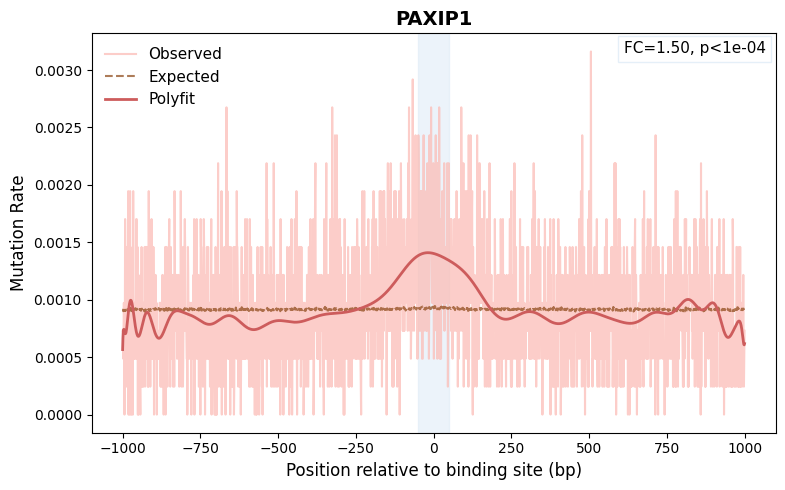

Samples: PCAWG_all_samples Gene: PBX2 Obs Sum: 7969 Exp Sum: 7969.000000000024
FC: 1.2157968856710313 OR1.2303485161283612 Pvalue: 0.0026864548488284533
FC core:1.2157968856710313 Pvalue: 0.0026864548488284533


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


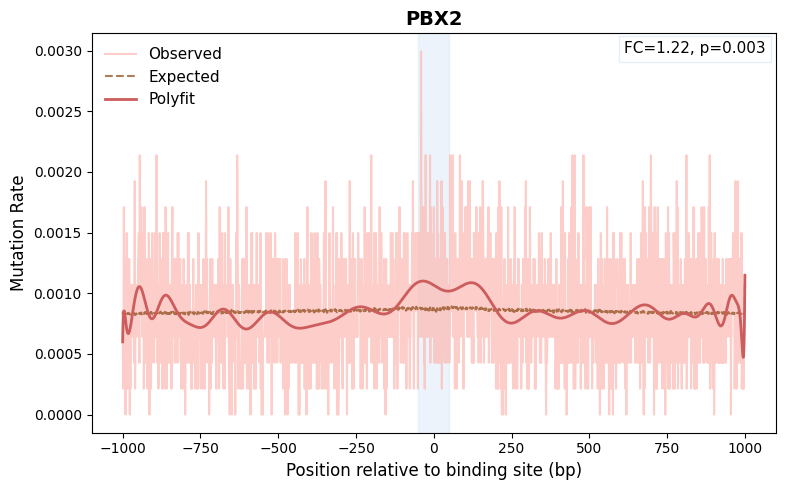

Samples: PCAWG_all_samples Gene: POLR2A Obs Sum: 27784 Exp Sum: 27784.0000000001
FC: 1.2395845000393808 OR1.2568645732999422 Pvalue: 2.3290172197064046e-10
FC core:1.2395845000393808 Pvalue: 2.3290172197064046e-10


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


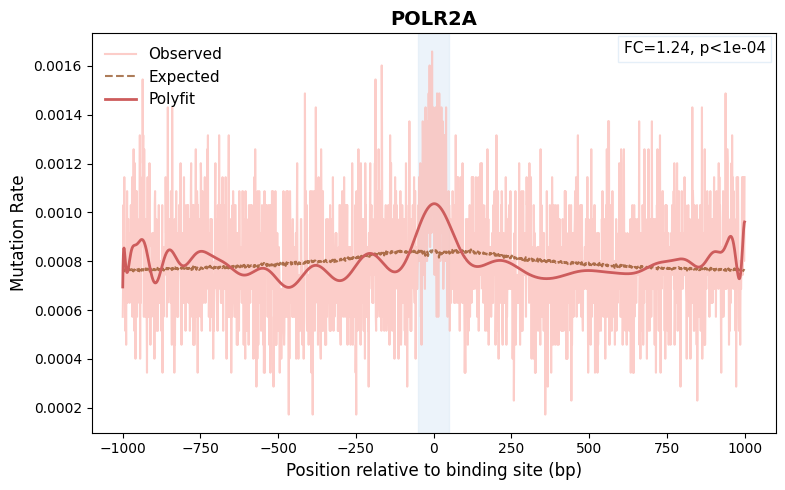

Samples: PCAWG_all_samples Gene: POLR2AphosphoS2 Obs Sum: 5635 Exp Sum: 5635.000000000017
FC: 1.1698276826178047 OR1.1809040380468951 Pvalue: 0.04571871533965016
FC core:1.1698276826178047 Pvalue: 0.04571871533965016


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


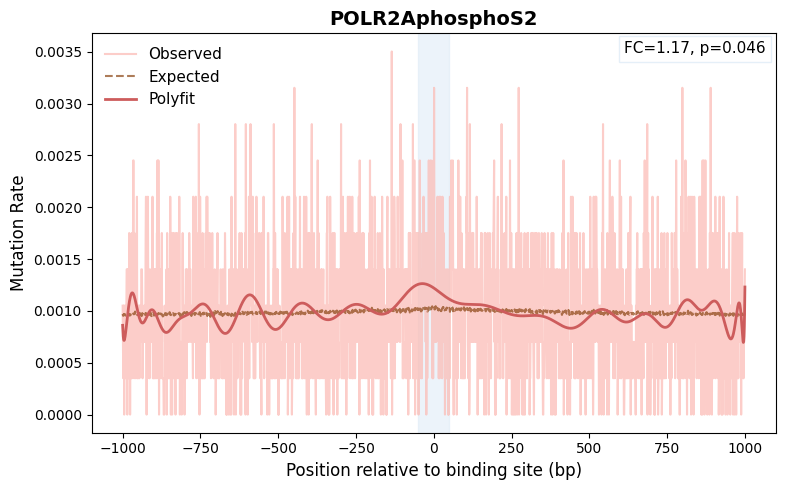

Samples: PCAWG_all_samples Gene: POLR2AphosphoS5 Obs Sum: 29644 Exp Sum: 29644.000000000102
FC: 1.251389839594427 OR1.2692017966834428 Pvalue: 8.543143414921576e-12
FC core:1.251389839594427 Pvalue: 8.543143414921576e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


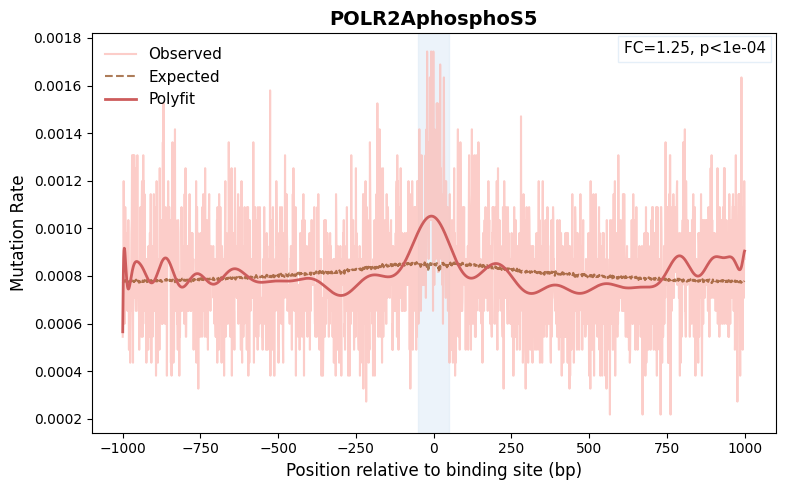

Samples: PCAWG_all_samples Gene: PPARG Obs Sum: 31674 Exp Sum: 31674.00000000008
FC: 1.4081370955041672 OR1.4401301147470507 Pvalue: 4.386387930961919e-28
FC core:1.4081370955041672 Pvalue: 4.386387930961919e-28


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


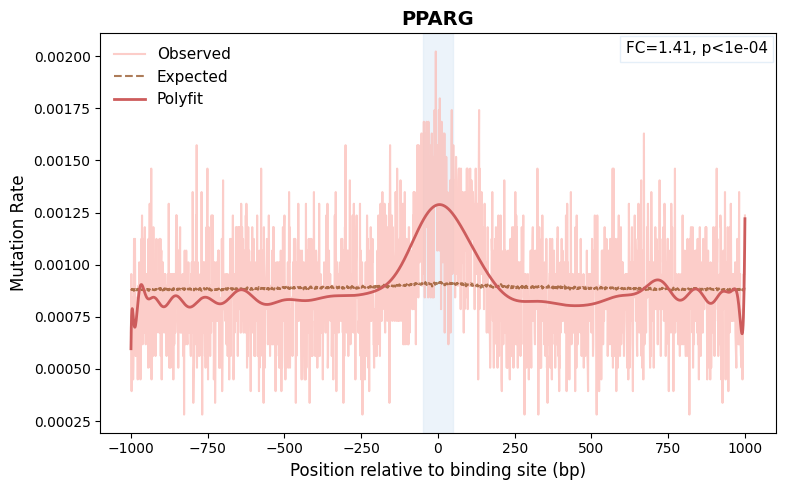

Samples: PCAWG_all_samples Gene: PRDM10 Obs Sum: 16226 Exp Sum: 16226.000000000047
FC: 1.286503072820818 OR1.3084917863148364 Pvalue: 9.90183668053081e-09
FC core:1.286503072820818 Pvalue: 9.90183668053081e-09


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


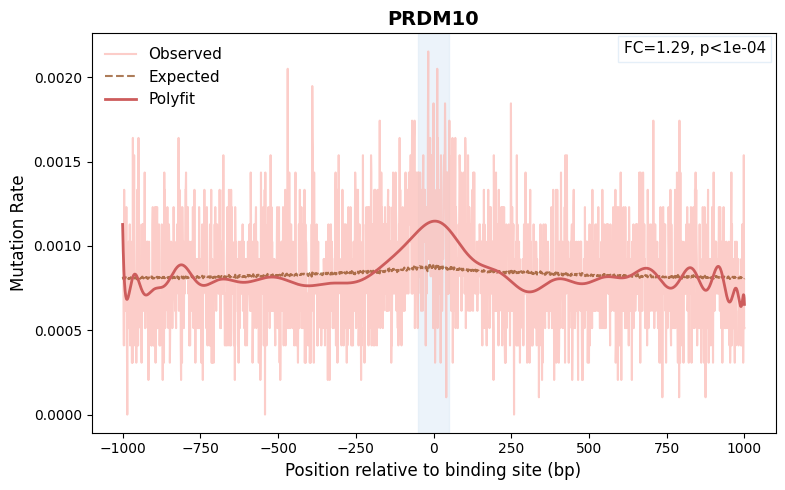

Samples: PCAWG_all_samples Gene: PROX1 Obs Sum: 35487 Exp Sum: 35487.00000000012
FC: 1.319335721508374 OR1.3425459489053455 Pvalue: 5.335564165440023e-20
FC core:1.319335721508374 Pvalue: 5.335564165440023e-20


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


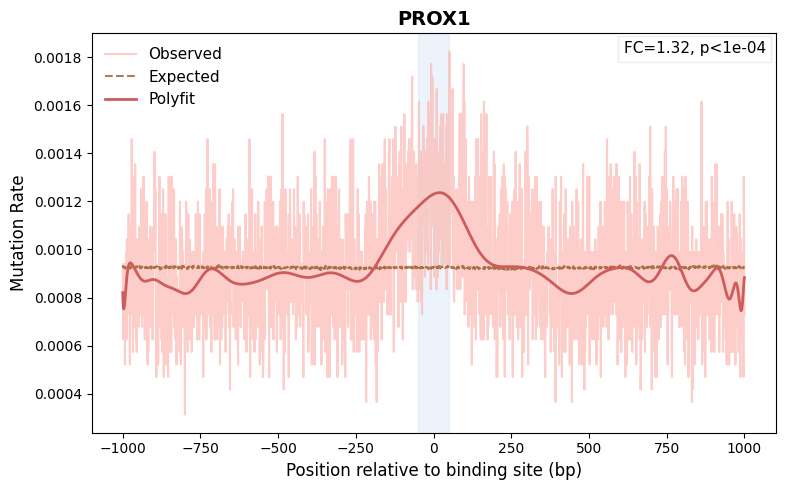

Samples: PCAWG_all_samples Gene: RAD21 Obs Sum: 107152 Exp Sum: 107152.0000000004
FC: 1.54115831763532 OR1.5886586352733232 Pvalue: 1.4056834097187156e-153
FC core:1.54115831763532 Pvalue: 1.4056834097187156e-153


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


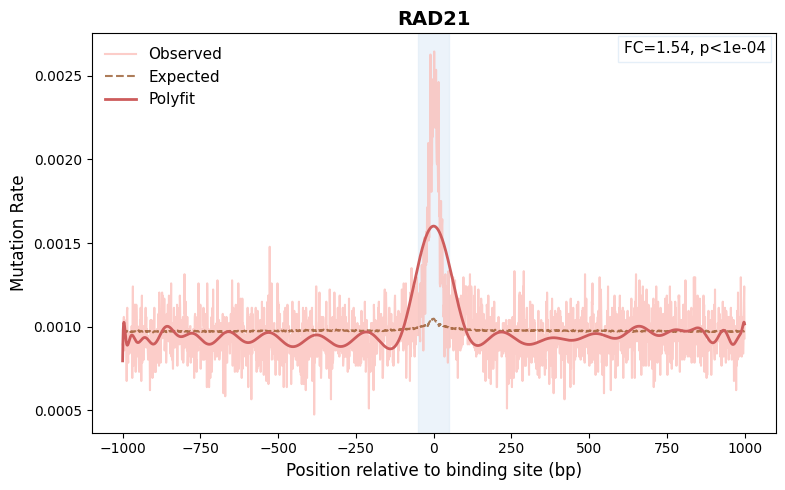

Samples: PCAWG_all_samples Gene: RARA Obs Sum: 60167 Exp Sum: 60167.000000000175
FC: 1.2568770715520643 OR1.2748255465144662 Pvalue: 8.632163177952304e-23
FC core:1.2568770715520643 Pvalue: 8.632163177952304e-23


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


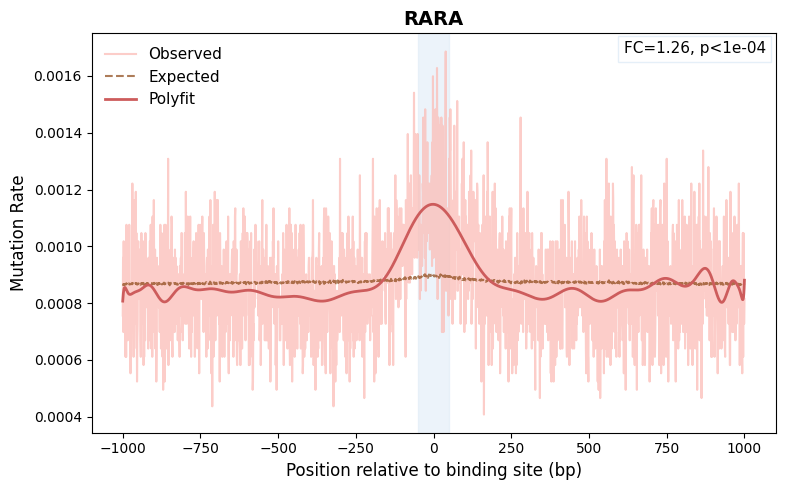

Samples: PCAWG_all_samples Gene: RCOR1 Obs Sum: 4629 Exp Sum: 4629.000000000014
FC: 1.3367417025360897 OR1.3664694988805661 Pvalue: 0.00029891849247965223
FC core:1.3367417025360897 Pvalue: 0.00029891849247965223


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


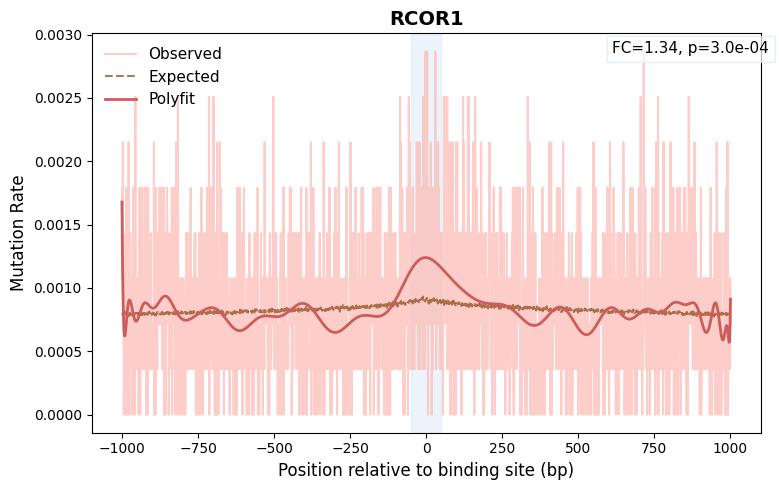

Samples: PCAWG_all_samples Gene: RCOR2 Obs Sum: 22497 Exp Sum: 22497.000000000065
FC: 1.3327918477910103 OR1.3576960386749997 Pvalue: 2.3412867114278925e-14
FC core:1.3327918477910103 Pvalue: 2.3412867114278925e-14


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


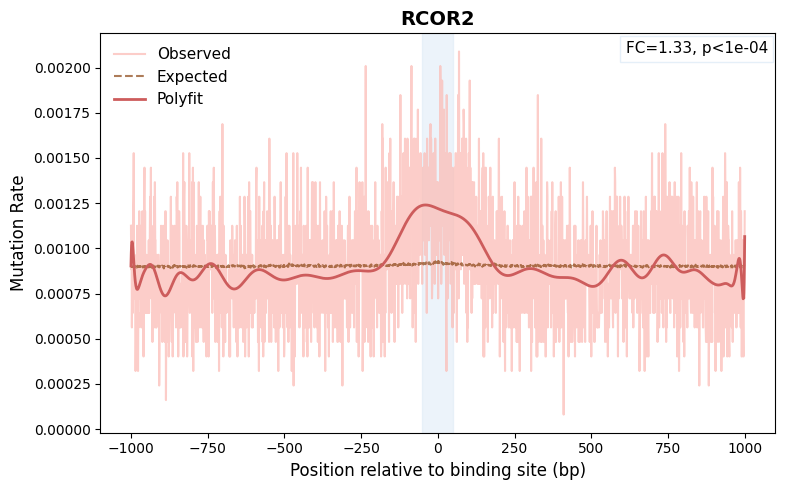

Samples: PCAWG_all_samples Gene: RERE Obs Sum: 14050 Exp Sum: 14050.000000000044
FC: 1.418191481337781 OR1.4517493747699026 Pvalue: 7.151912630987731e-14
FC core:1.418191481337781 Pvalue: 7.151912630987731e-14


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


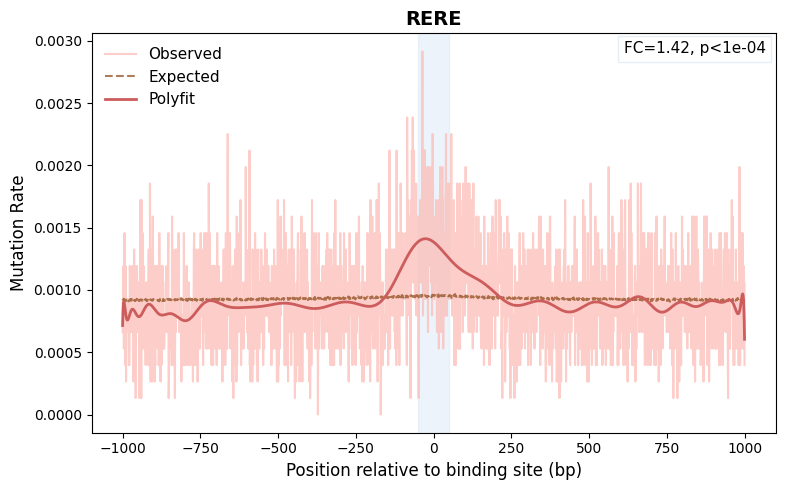

Samples: PCAWG_all_samples Gene: REST Obs Sum: 17157 Exp Sum: 17157.00000000005
FC: 1.2523991802625438 OR1.270232591308227 Pvalue: 2.0546074034777317e-07
FC core:1.2523991802625438 Pvalue: 2.0546074034777317e-07


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


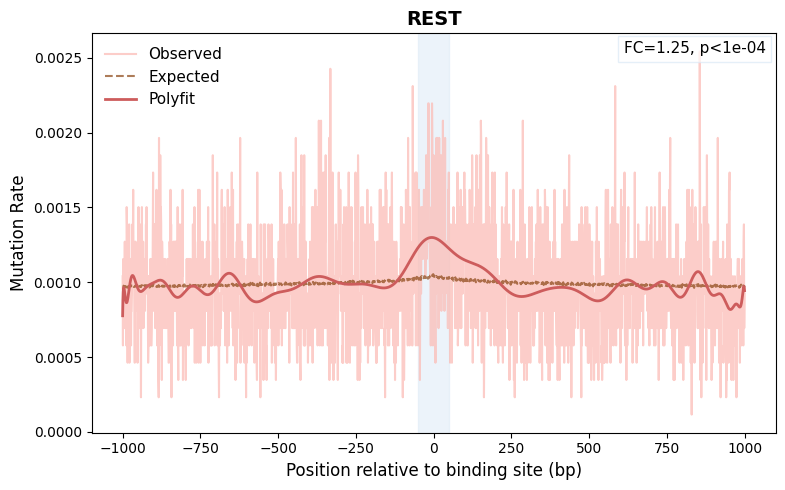

Samples: PCAWG_all_samples Gene: RFX3 Obs Sum: 7303 Exp Sum: 7303.000000000024
FC: 1.1689482166497027 OR1.1826497957140107 Pvalue: 0.019550302594740547
FC core:1.1689482166497027 Pvalue: 0.019550302594740547


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


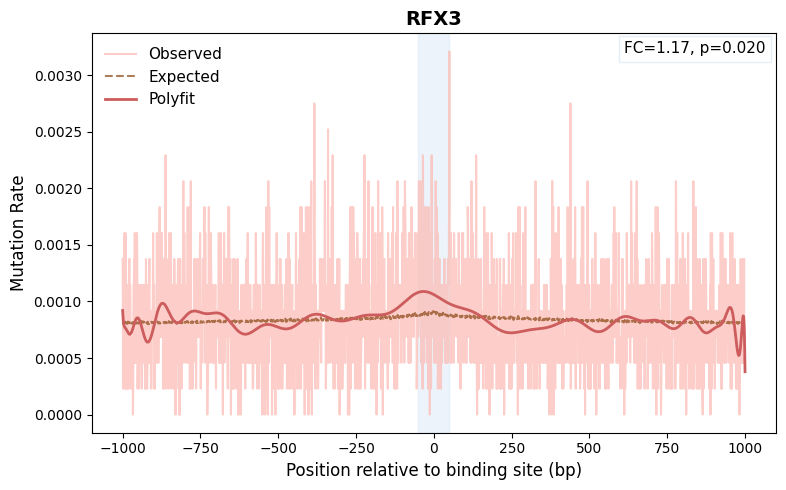

Samples: PCAWG_all_samples Gene: RFX5 Obs Sum: 8082 Exp Sum: 8082.000000000027
FC: 1.2476745368995505 OR1.265417298531477 Pvalue: 0.00041617801738277785
FC core:1.2476745368995505 Pvalue: 0.00041617801738277785


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


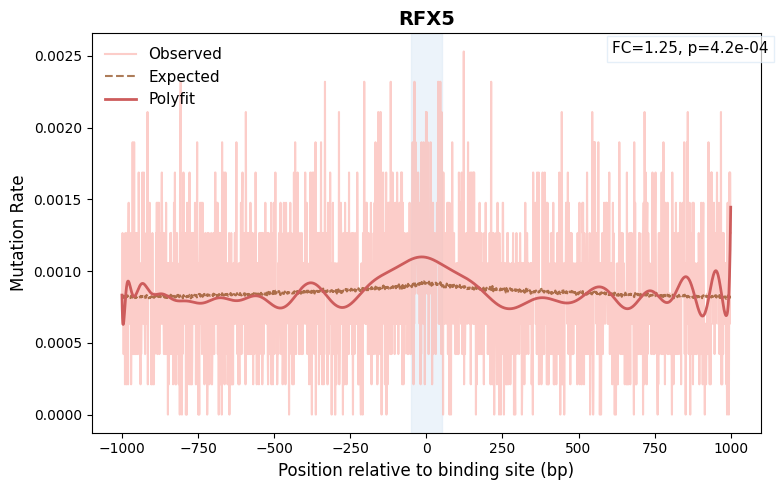

Samples: PCAWG_all_samples Gene: RFXANK Obs Sum: 5851 Exp Sum: 5851.000000000018
FC: 1.3448010798414143 OR1.371706551204468 Pvalue: 4.028516378048847e-05
FC core:1.3448010798414143 Pvalue: 4.028516378048847e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


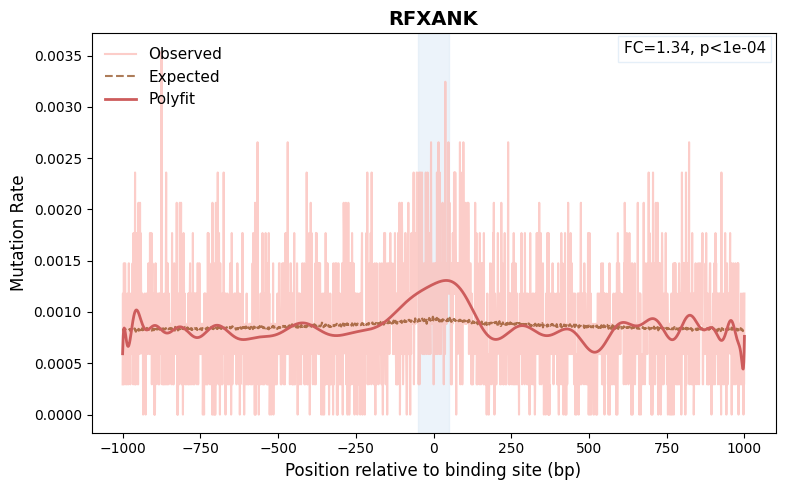

Samples: PCAWG_all_samples Gene: RING1 Obs Sum: 878 Exp Sum: 878.0000000000033
FC: 0.923963005410672 OR0.9303046081749544 Pvalue: 0.7456274698448508
FC core:0.923963005410672 Pvalue: 0.7456274698448508


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


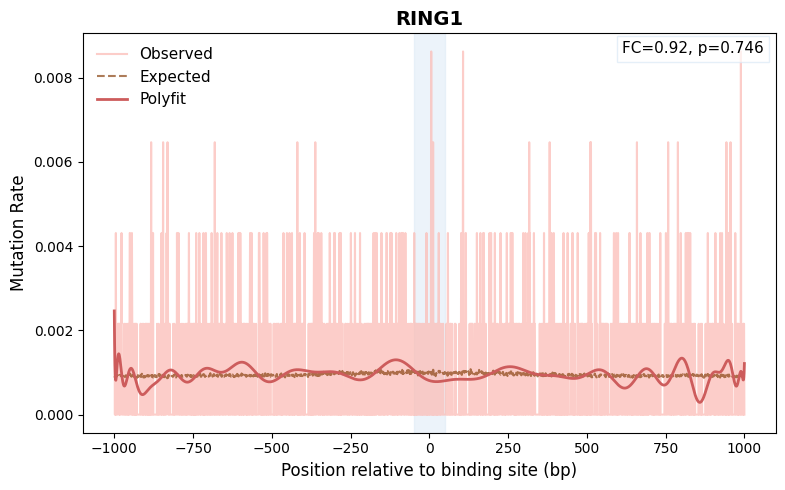

Samples: PCAWG_all_samples Gene: RREB1 Obs Sum: 16850 Exp Sum: 16850.00000000005
FC: 1.501919215391904 OR1.5463031128452411 Pvalue: 1.32835039033196e-22
FC core:1.501919215391904 Pvalue: 1.32835039033196e-22


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


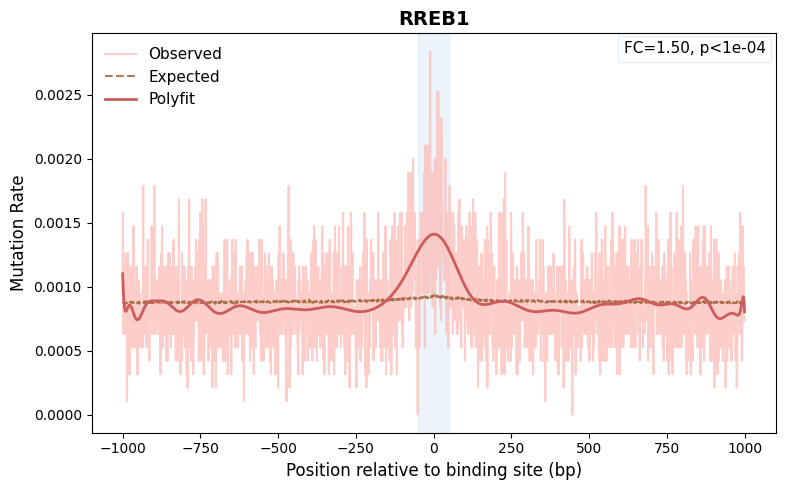

Samples: PCAWG_all_samples Gene: RUVBL1 Obs Sum: 3297 Exp Sum: 3297.0000000000123
FC: 1.219571678812386 OR1.2377135016069043 Pvalue: 0.044103093994192044
FC core:1.219571678812386 Pvalue: 0.044103093994192044


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


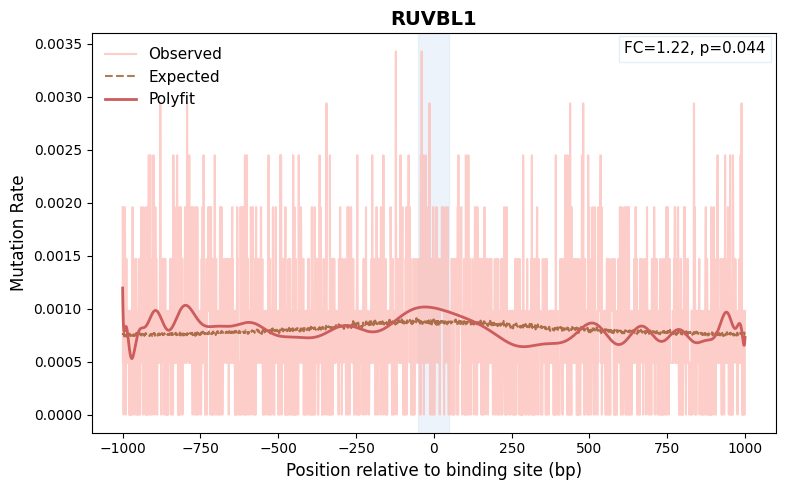

Samples: PCAWG_all_samples Gene: RXRA Obs Sum: 14219 Exp Sum: 14219.000000000036
FC: 1.395158339212679 OR1.425941323691835 Pvalue: 1.1754230288483366e-12
FC core:1.395158339212679 Pvalue: 1.1754230288483366e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


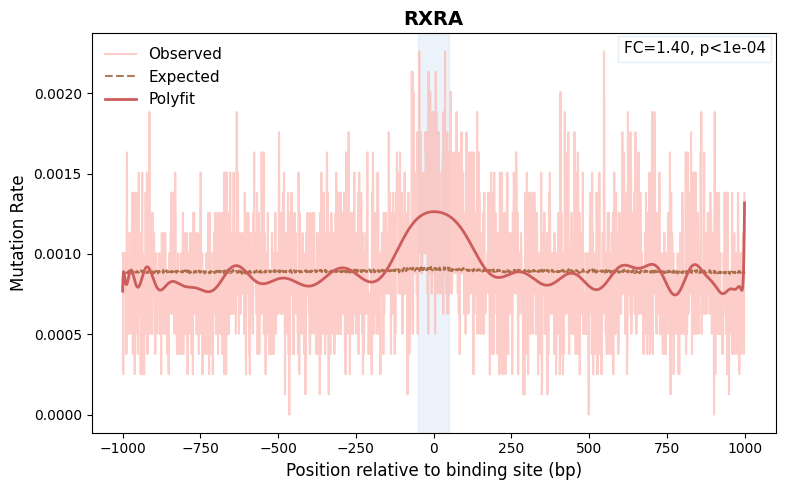

Samples: PCAWG_all_samples Gene: RXRB Obs Sum: 44434 Exp Sum: 44434.00000000019
FC: 1.397445486255599 OR1.4289776647330343 Pvalue: 2.5562337056818447e-37
FC core:1.397445486255599 Pvalue: 2.5562337056818447e-37


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


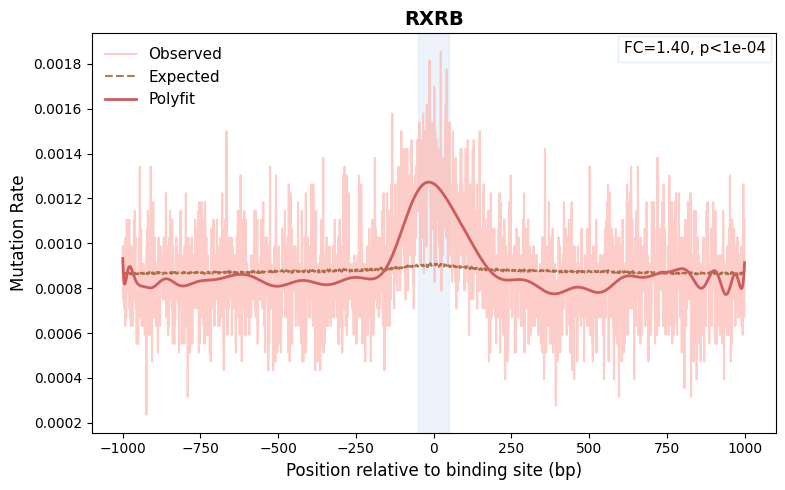

Samples: PCAWG_all_samples Gene: SAP130 Obs Sum: 71555 Exp Sum: 71555.0000000002
FC: 1.3157108494996588 OR1.3393592342489324 Pvalue: 1.7117248302542685e-39
FC core:1.3157108494996588 Pvalue: 1.7117248302542685e-39


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


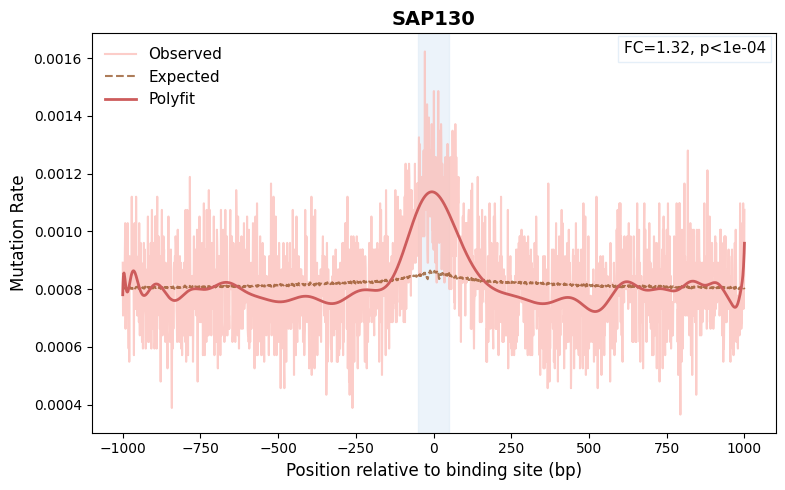

Samples: PCAWG_all_samples Gene: SIN3A Obs Sum: 14873 Exp Sum: 14873.00000000005
FC: 1.2041961542815707 OR1.2197558197434248 Pvalue: 5.4871282936023335e-05
FC core:1.2041961542815707 Pvalue: 5.4871282936023335e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


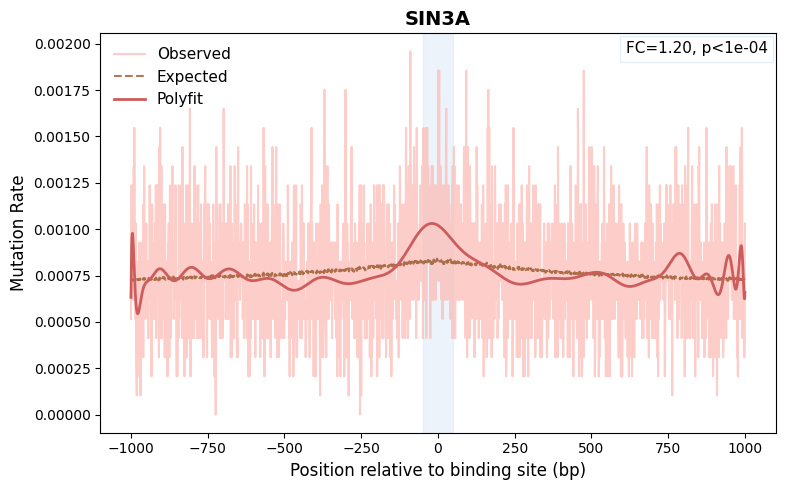

Samples: PCAWG_all_samples Gene: SIN3B Obs Sum: 4645 Exp Sum: 4645.000000000018
FC: 1.1735144138371862 OR1.1891290088109632 Pvalue: 0.05086714612064397
FC core:1.1735144138371862 Pvalue: 0.05086714612064397


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


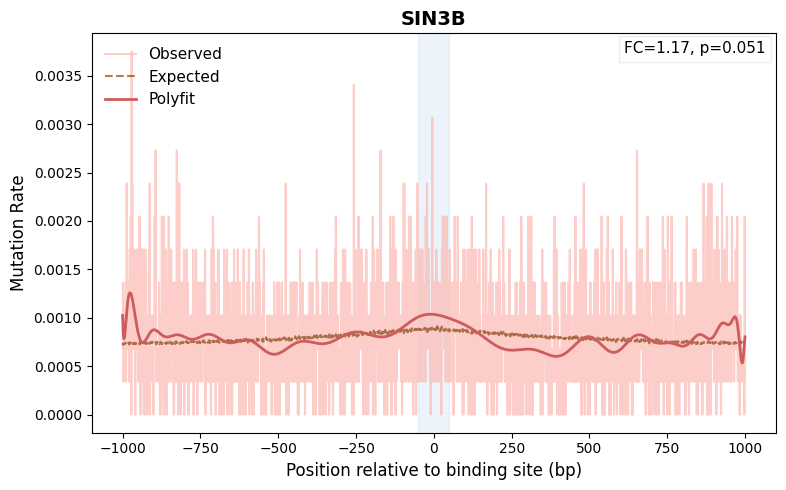

Samples: PCAWG_all_samples Gene: SIX4 Obs Sum: 15035 Exp Sum: 15035.000000000051
FC: 1.3663377263896914 OR1.3959286111742182 Pvalue: 5.437943827623684e-12
FC core:1.3663377263896914 Pvalue: 5.437943827623684e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


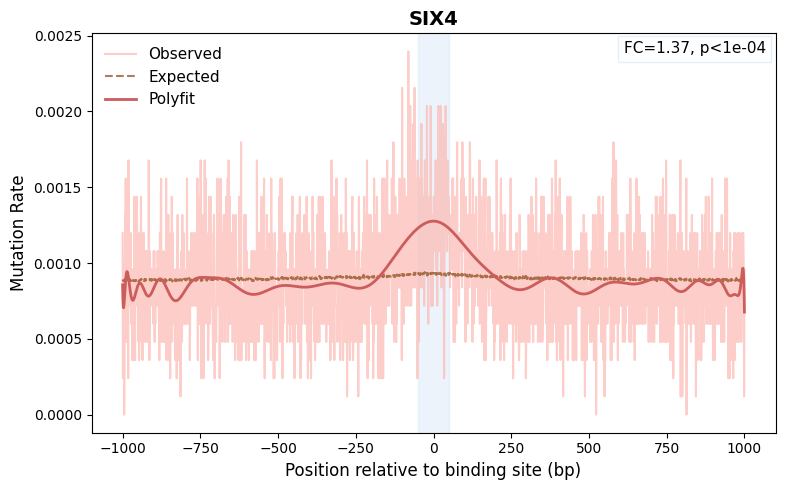

Samples: PCAWG_all_samples Gene: SLC30A9 Obs Sum: 8858 Exp Sum: 8858.000000000033
FC: 1.380360918253056 OR1.4121788827901287 Pvalue: 2.9046979290242793e-08
FC core:1.380360918253056 Pvalue: 2.9046979290242793e-08


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


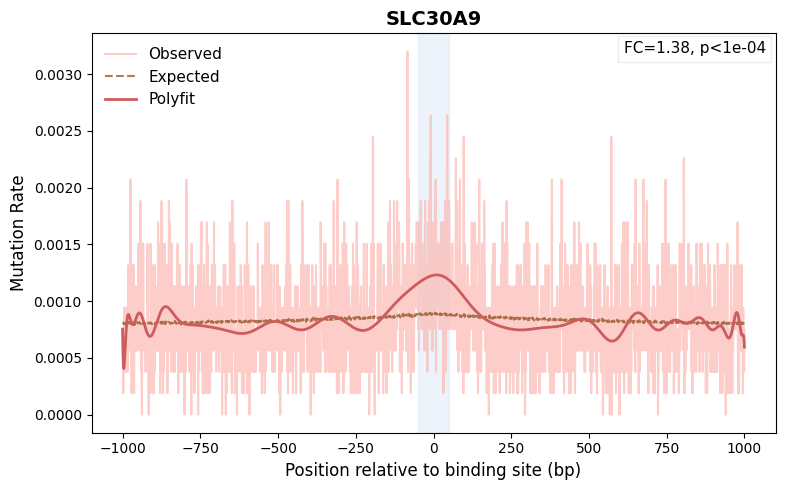

Samples: PCAWG_all_samples Gene: SMAD4 Obs Sum: 55224 Exp Sum: 55224.00000000019
FC: 1.3125494545942287 OR1.3361948216930288 Pvalue: 2.0757643444436673e-30
FC core:1.3125494545942287 Pvalue: 2.0757643444436673e-30


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


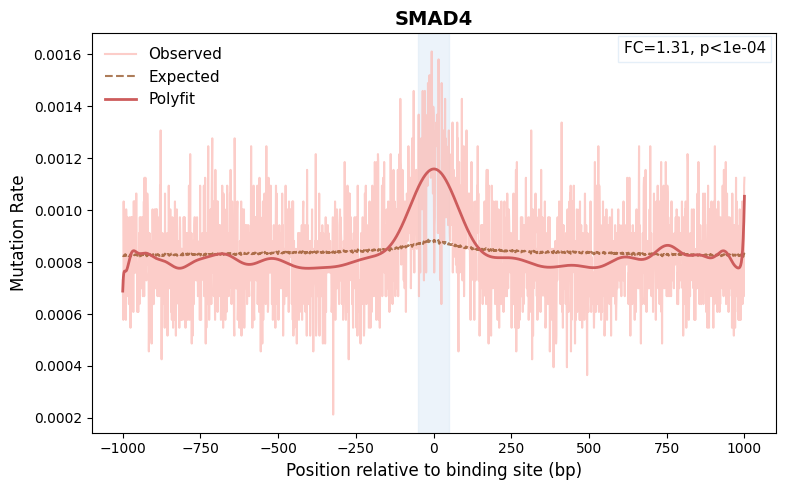

Samples: PCAWG_all_samples Gene: SMC3 Obs Sum: 43434 Exp Sum: 43434.00000000016
FC: 2.130403212225124 OR2.270892565249428 Pvalue: 5.041779833700593e-224
FC core:2.130403212225124 Pvalue: 5.041779833700593e-224


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


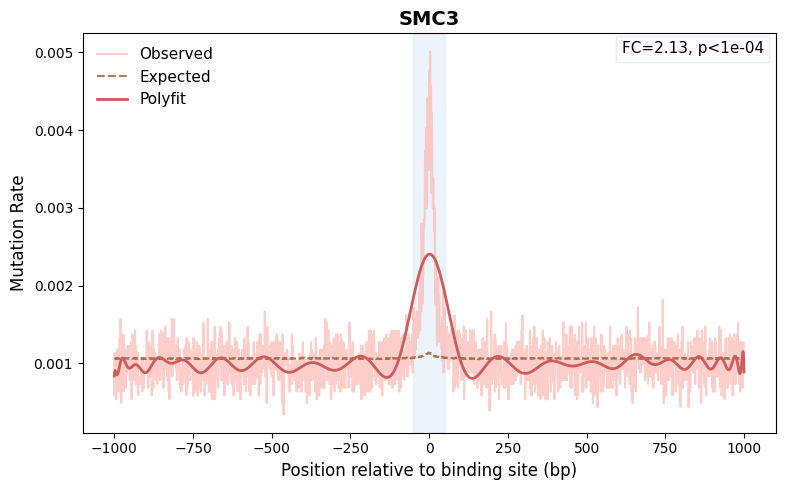

Samples: PCAWG_all_samples Gene: SOX13 Obs Sum: 9094 Exp Sum: 9094.000000000025
FC: 1.4180688398794572 OR1.4523907000797258 Pvalue: 2.3463953678774843e-09
FC core:1.4180688398794572 Pvalue: 2.3463953678774843e-09


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


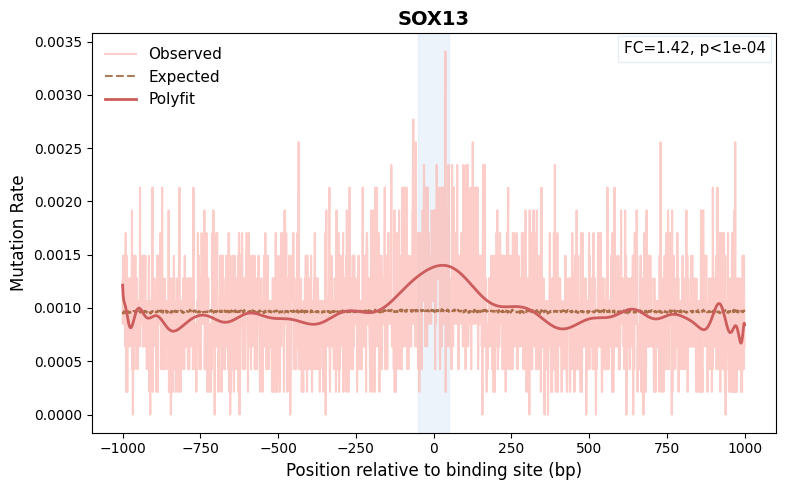

Samples: PCAWG_all_samples Gene: SOX13iso1 Obs Sum: 60647 Exp Sum: 60647.000000000204
FC: 1.2882573644790716 OR1.3088744456940515 Pvalue: 5.4689800821627195e-28
FC core:1.2882573644790716 Pvalue: 5.4689800821627195e-28


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


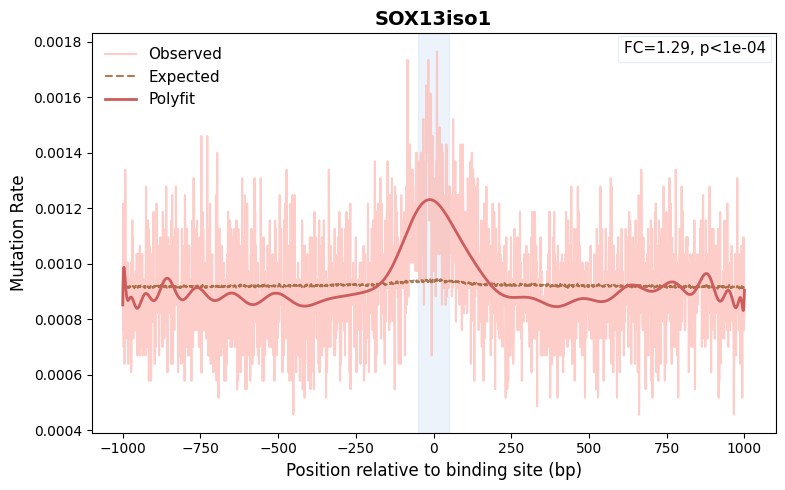

Samples: PCAWG_all_samples Gene: SOX5 Obs Sum: 37456 Exp Sum: 37456.0000000001
FC: 1.3504962472503825 OR1.3767522595212125 Pvalue: 4.330382961350654e-25
FC core:1.3504962472503825 Pvalue: 4.330382961350654e-25


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


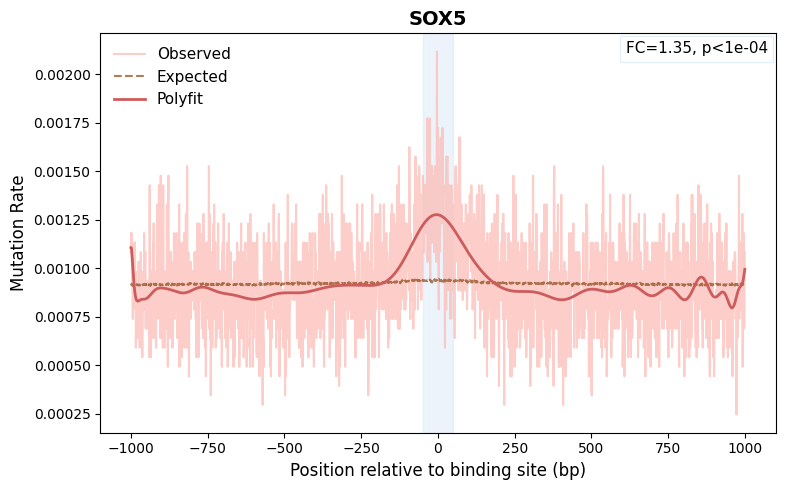

Samples: PCAWG_all_samples Gene: SP1 Obs Sum: 16121 Exp Sum: 16121.000000000051
FC: 1.107443100605566 OR1.1157424501027553 Pvalue: 0.021169287244082787
FC core:1.107443100605566 Pvalue: 0.021169287244082787


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


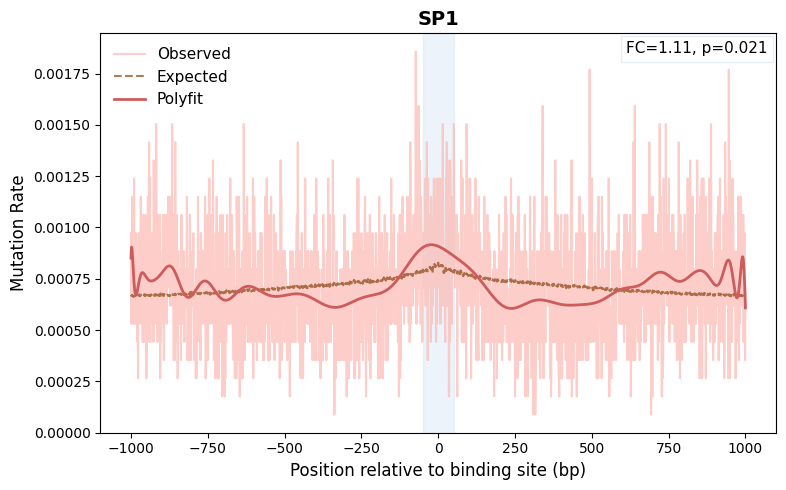

Samples: PCAWG_all_samples Gene: SP2 Obs Sum: 3046 Exp Sum: 3046.0000000000105
FC: 1.1443646810684265 OR1.1537958556916743 Pvalue: 0.20896874508034918
FC core:1.1443646810684265 Pvalue: 0.20896874508034918


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


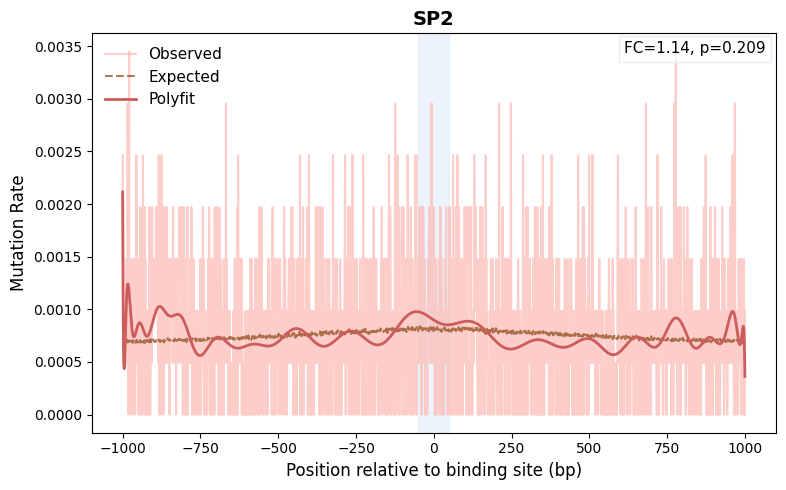

Samples: PCAWG_all_samples Gene: SP5 Obs Sum: 25890 Exp Sum: 25890.00000000006
FC: 1.2008407031529853 OR1.2147922562939146 Pvalue: 2.1233789676295587e-07
FC core:1.2008407031529853 Pvalue: 2.1233789676295587e-07


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


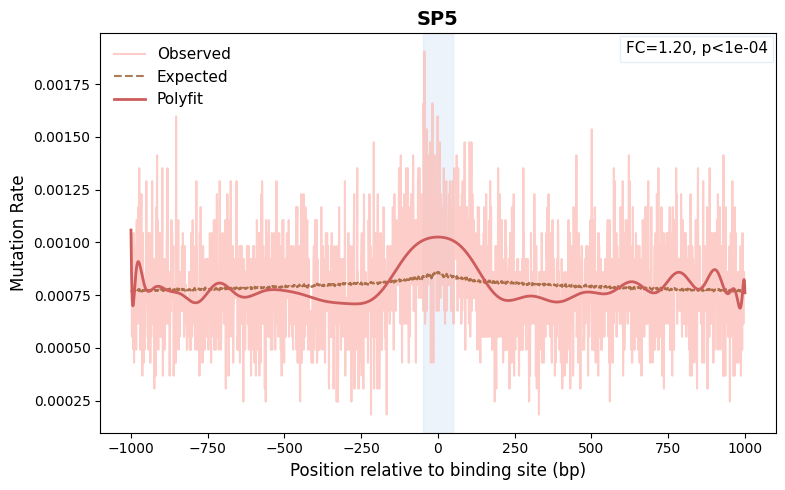

Samples: PCAWG_all_samples Gene: SREBF1 Obs Sum: 1349 Exp Sum: 1349.000000000004
FC: 1.12358839384429 OR1.1414029535864978 Pvalue: 0.4632915081343466
FC core:1.12358839384429 Pvalue: 0.4632915081343466


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


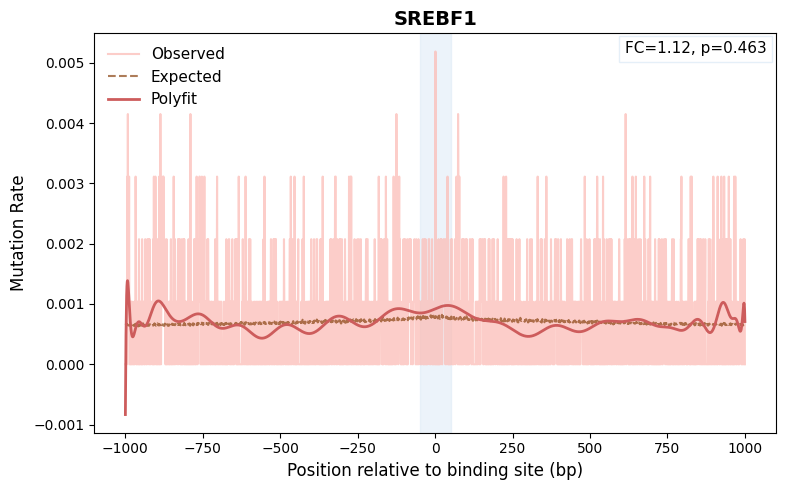

Samples: PCAWG_all_samples Gene: SRF Obs Sum: 6878 Exp Sum: 6878.000000000022
FC: 1.2231645992712792 OR1.2402244834550256 Pvalue: 0.0035596800499381573
FC core:1.2231645992712792 Pvalue: 0.0035596800499381573


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


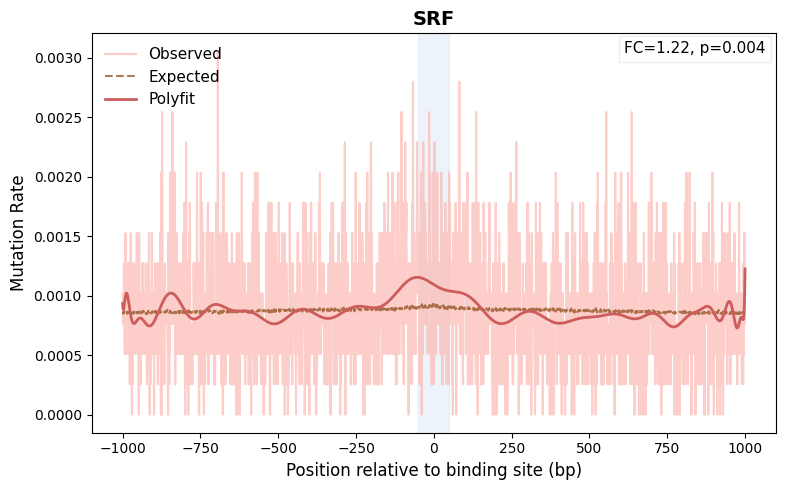

Samples: PCAWG_all_samples Gene: SSRP1 Obs Sum: 9334 Exp Sum: 9334.000000000025
FC: 1.179634081065108 OR1.1924582930743095 Pvalue: 0.006248662242508604
FC core:1.179634081065108 Pvalue: 0.006248662242508604


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


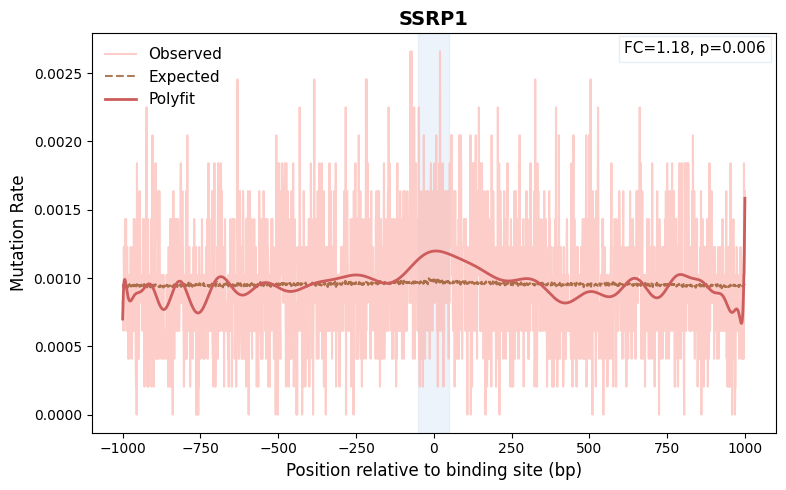

Samples: PCAWG_all_samples Gene: SUZ12 Obs Sum: 2640 Exp Sum: 2640.000000000009
FC: 1.2238377981992978 OR1.240418118466899 Pvalue: 0.06754268340167927
FC core:1.2238377981992978 Pvalue: 0.06754268340167927


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


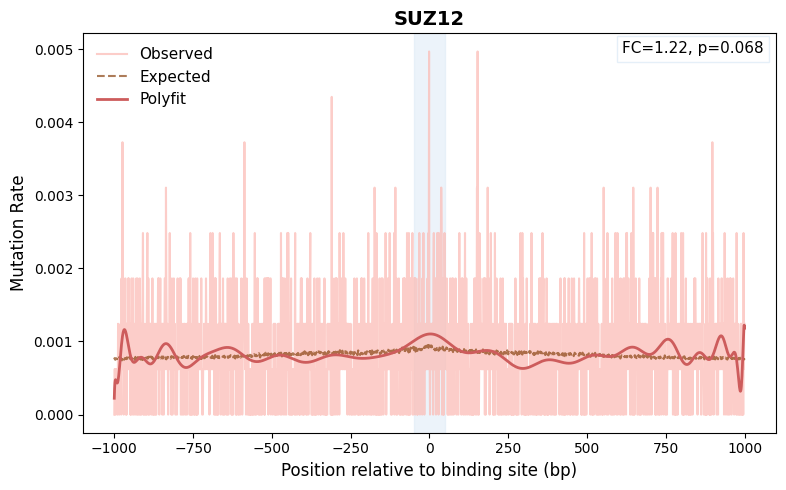

Samples: PCAWG_all_samples Gene: TAF1 Obs Sum: 15651 Exp Sum: 15651.000000000058
FC: 1.0751360218894204 OR1.0803795174684443 Pvalue: 0.1100593877988037
FC core:1.0751360218894204 Pvalue: 0.1100593877988037


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


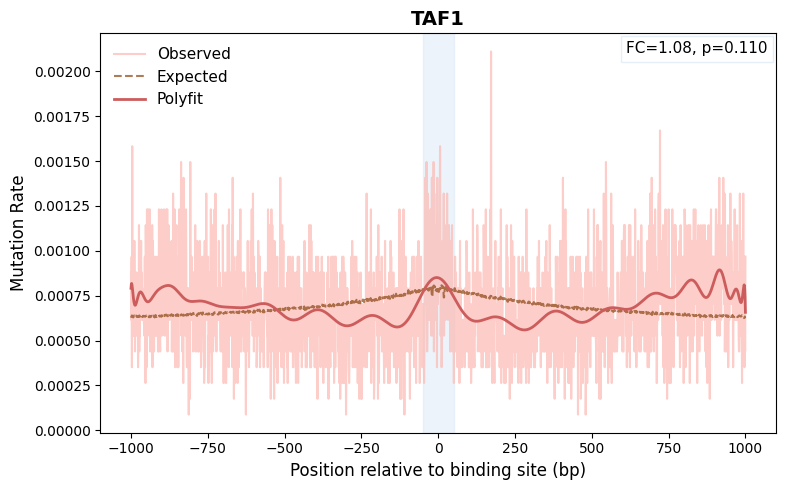

Samples: PCAWG_all_samples Gene: TBL1XR1 Obs Sum: 8999 Exp Sum: 8999.000000000027
FC: 1.5262183448505262 OR1.571993089861913 Pvalue: 1.1844459451406e-13
FC core:1.5262183448505262 Pvalue: 1.1844459451406e-13


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


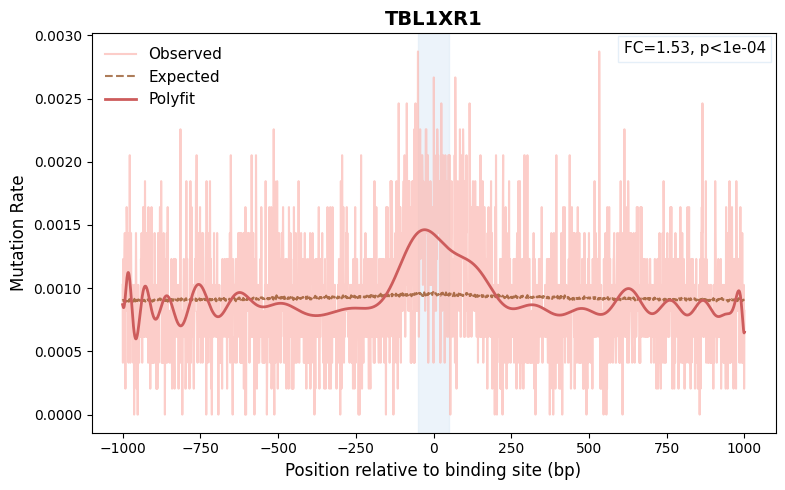

Samples: PCAWG_all_samples Gene: TBP Obs Sum: 18875 Exp Sum: 18875.000000000073
FC: 1.3280076885009005 OR1.354127724439212 Pvalue: 1.6436453518761954e-12
FC core:1.3280076885009005 Pvalue: 1.6436453518761954e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


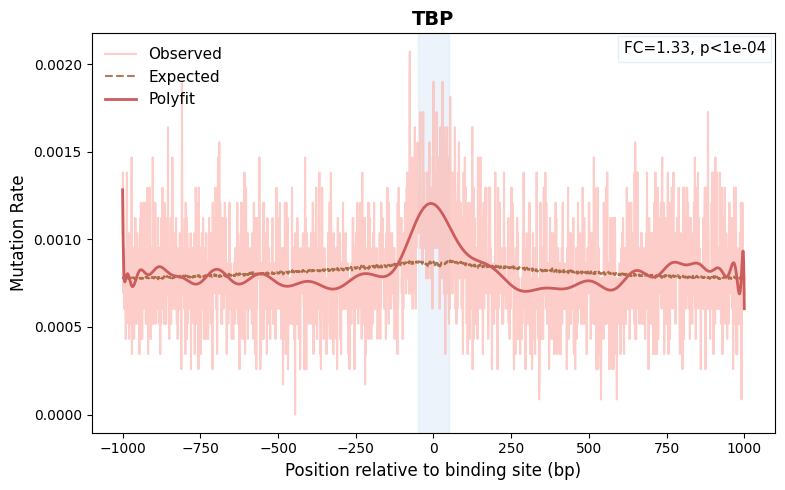

Samples: PCAWG_all_samples Gene: TCF12 Obs Sum: 398 Exp Sum: 398.00000000000114
FC: 1.5980468523425695 OR1.7042465753424658 Pvalue: 0.08715534327788926
FC core:1.5980468523425695 Pvalue: 0.08715534327788926


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


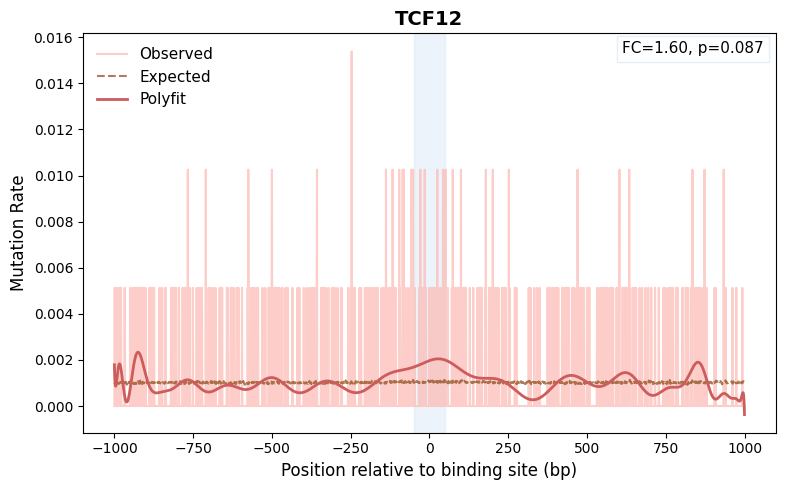

Samples: PCAWG_all_samples Gene: TCF25 Obs Sum: 4516 Exp Sum: 4516.000000000015
FC: 1.7078466294694563 OR1.7841001816611572 Pvalue: 1.95407179200879e-12
FC core:1.7078466294694563 Pvalue: 1.95407179200879e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


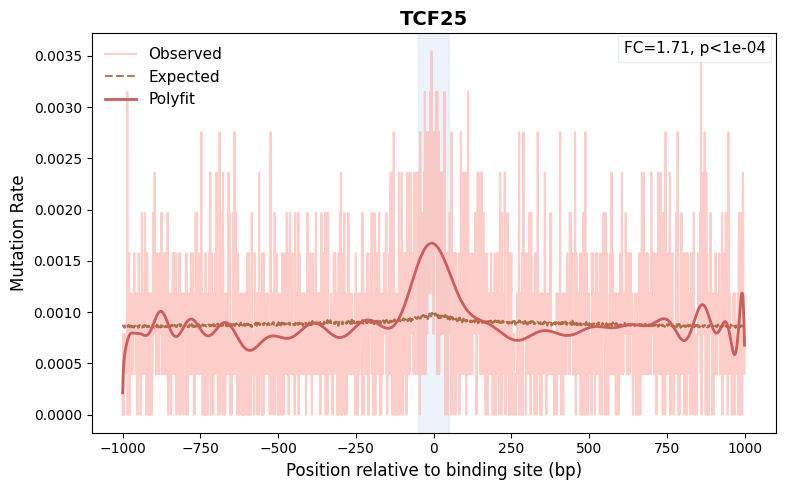

Samples: PCAWG_all_samples Gene: TCF7 Obs Sum: 22499 Exp Sum: 22499.000000000073
FC: 1.3283519481163744 OR1.3528472996250887 Pvalue: 7.106971374027927e-14
FC core:1.3283519481163744 Pvalue: 7.106971374027927e-14


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


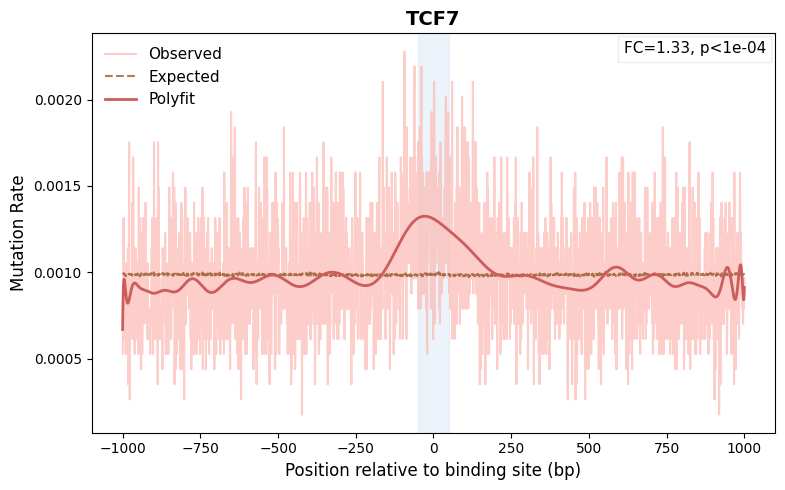

Samples: PCAWG_all_samples Gene: TCF7L2 Obs Sum: 4726 Exp Sum: 4726.0000000000155
FC: 1.2296333600748652 OR1.2480643188810119 Pvalue: 0.015418629792386554
FC core:1.2296333600748652 Pvalue: 0.015418629792386554


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


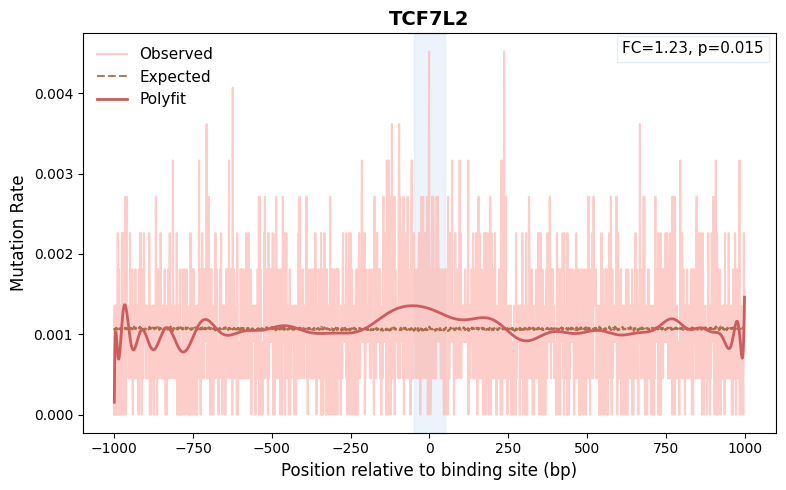

Samples: PCAWG_all_samples Gene: TEAD1 Obs Sum: 45971 Exp Sum: 45971.00000000021
FC: 1.4484892861119238 OR1.4851862854385003 Pvalue: 2.8865489594639876e-47
FC core:1.4484892861119238 Pvalue: 2.8865489594639876e-47


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


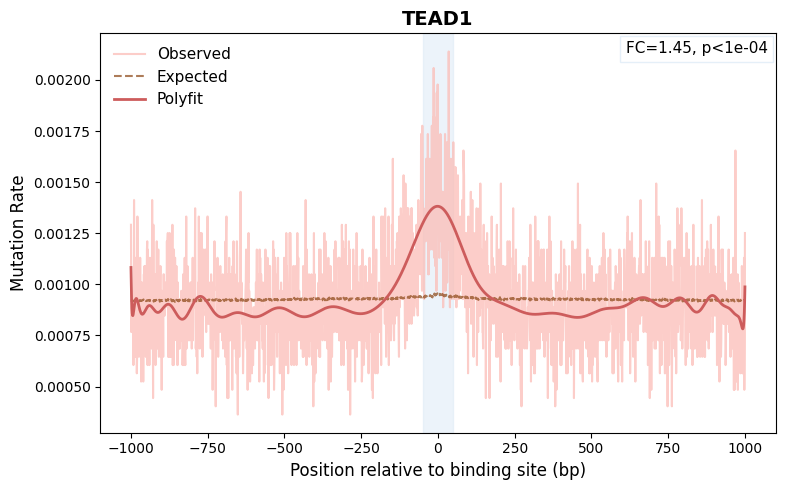

Samples: PCAWG_all_samples Gene: TEAD3 Obs Sum: 41184 Exp Sum: 41184.000000000146
FC: 1.381179411732174 OR1.4113327866268408 Pvalue: 2.0504892737379424e-32
FC core:1.381179411732174 Pvalue: 2.0504892737379424e-32


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


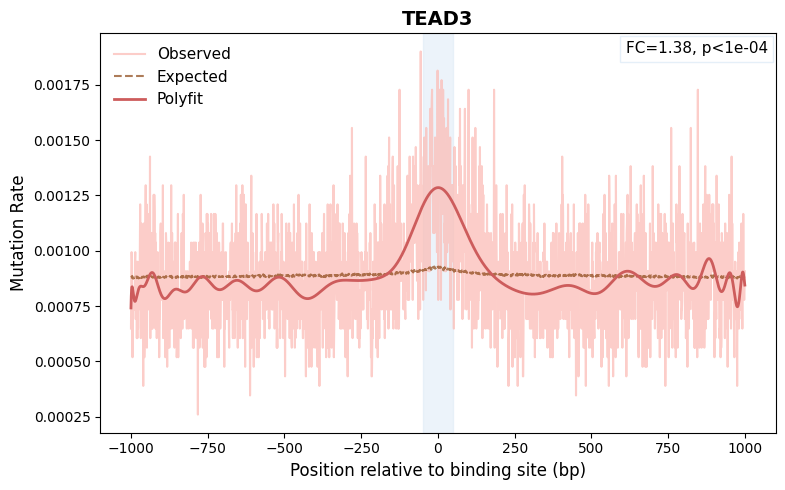

Samples: PCAWG_all_samples Gene: TEAD4 Obs Sum: 8458 Exp Sum: 8458.000000000025
FC: 1.4426091670147407 OR1.4776788462207522 Pvalue: 1.5124963597745869e-09
FC core:1.4426091670147407 Pvalue: 1.5124963597745869e-09


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


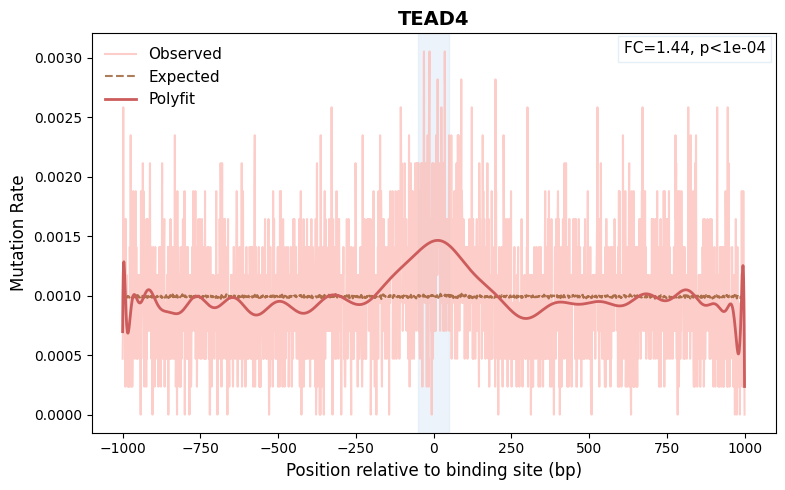

Samples: PCAWG_all_samples Gene: TFAP4 Obs Sum: 17766 Exp Sum: 17766.000000000044
FC: 1.3214611499303637 OR1.3452988309470642 Pvalue: 4.2931521567194056e-11
FC core:1.3214611499303637 Pvalue: 4.2931521567194056e-11


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


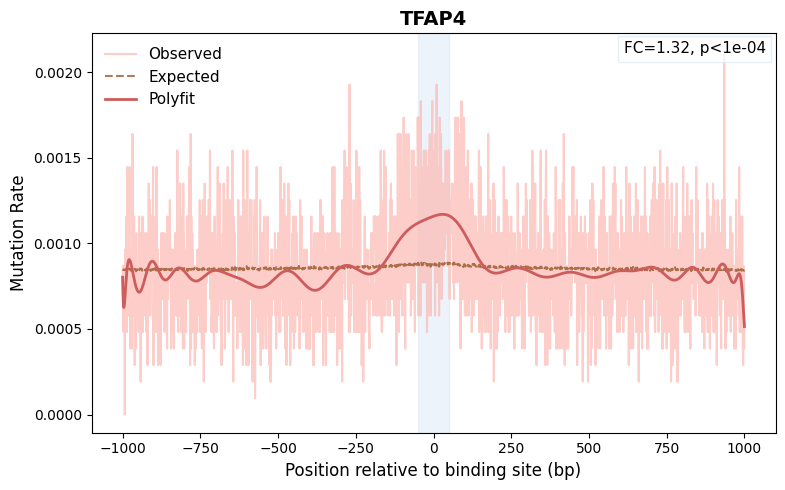

Samples: PCAWG_all_samples Gene: TFDP1 Obs Sum: 11557 Exp Sum: 11557.00000000004
FC: 1.1363333287158957 OR1.146729394340352 Pvalue: 0.013573048742916663
FC core:1.1363333287158957 Pvalue: 0.013573048742916663


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


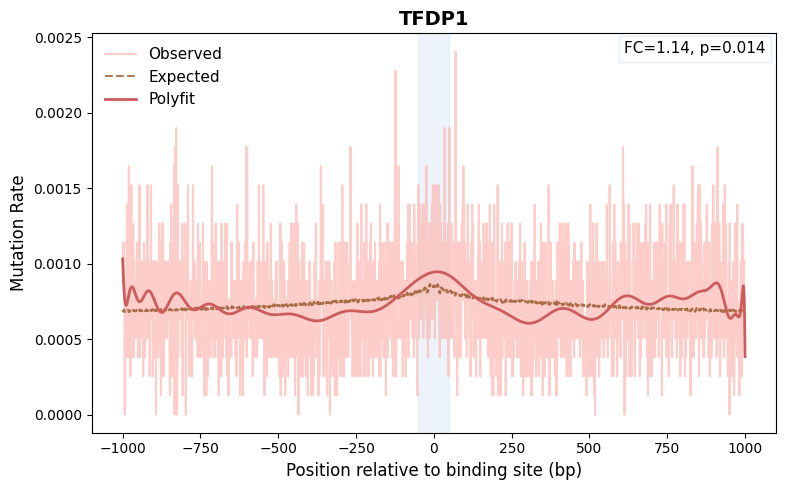

Samples: PCAWG_all_samples Gene: TFE3 Obs Sum: 25656 Exp Sum: 25656.00000000006
FC: 1.3474857002495069 OR1.3744692265442382 Pvalue: 6.088352547958891e-18
FC core:1.3474857002495069 Pvalue: 6.088352547958891e-18


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


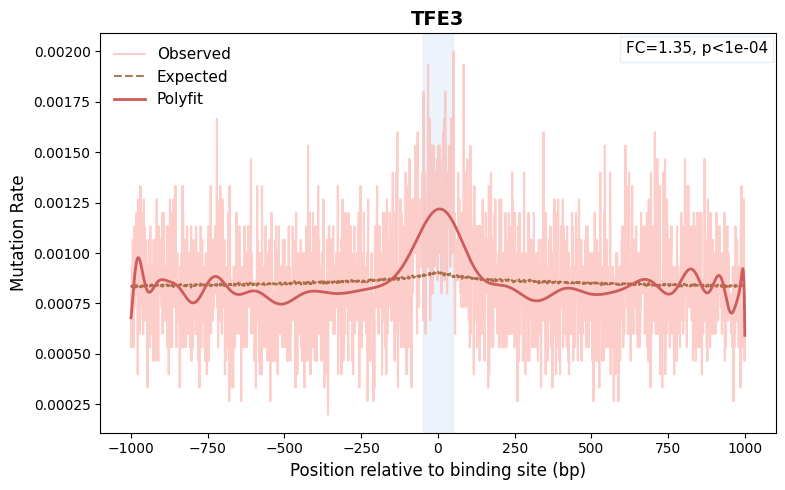

Samples: PCAWG_all_samples Gene: TGIF2 Obs Sum: 18916 Exp Sum: 18916.000000000065
FC: 1.3767357100245592 OR1.4071387899513152 Pvalue: 1.0668167455427525e-15
FC core:1.3767357100245592 Pvalue: 1.0668167455427525e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


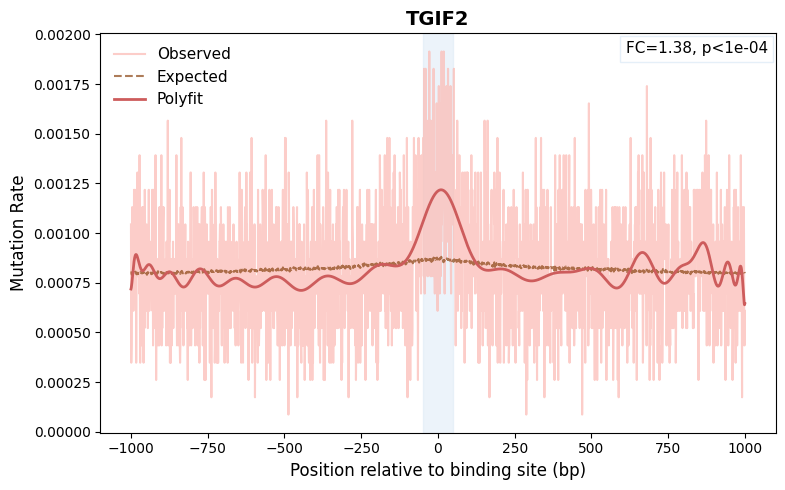

Samples: PCAWG_all_samples Gene: THAP11 Obs Sum: 41201 Exp Sum: 41201.00000000014
FC: 1.4250854064006644 OR1.4602938842201936 Pvalue: 3.043252844547905e-40
FC core:1.4250854064006644 Pvalue: 3.043252844547905e-40


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


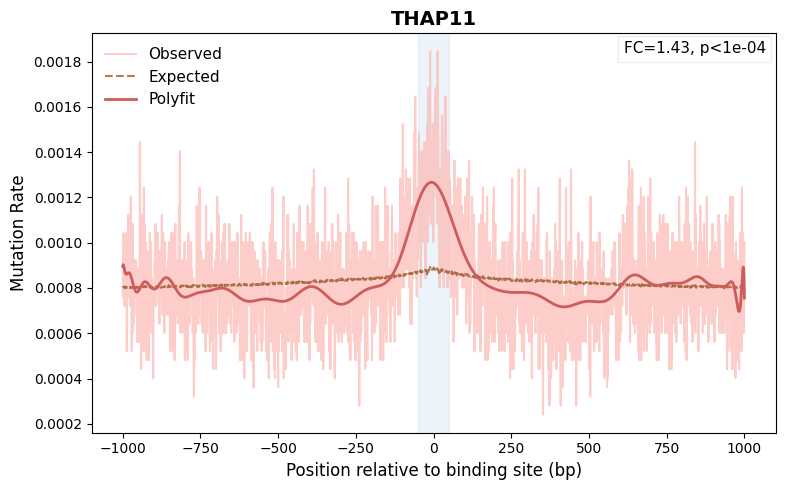

Samples: PCAWG_all_samples Gene: THRA Obs Sum: 20945 Exp Sum: 20945.00000000005
FC: 1.4706586350104687 OR1.5108008870605232 Pvalue: 5.250236328752362e-25
FC core:1.4706586350104687 Pvalue: 5.250236328752362e-25


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


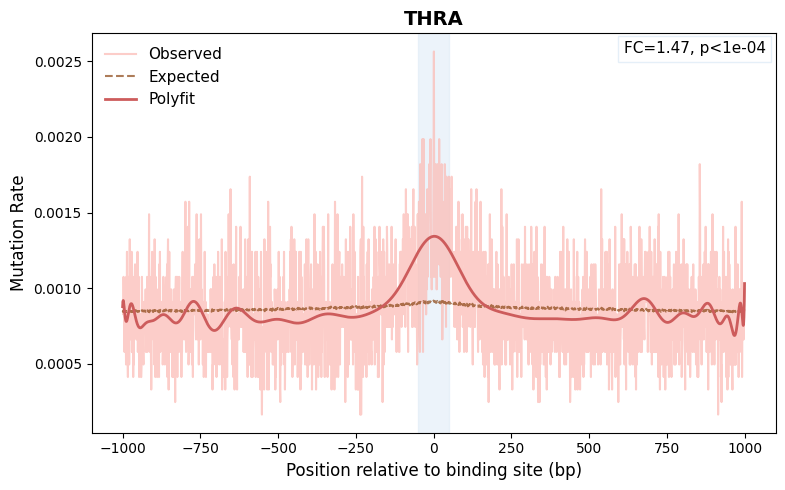

Samples: PCAWG_all_samples Gene: THRB Obs Sum: 13874 Exp Sum: 13874.00000000004
FC: 1.3783385180446046 OR1.4079110833300776 Pvalue: 1.2872287040738256e-11
FC core:1.3783385180446046 Pvalue: 1.2872287040738256e-11


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


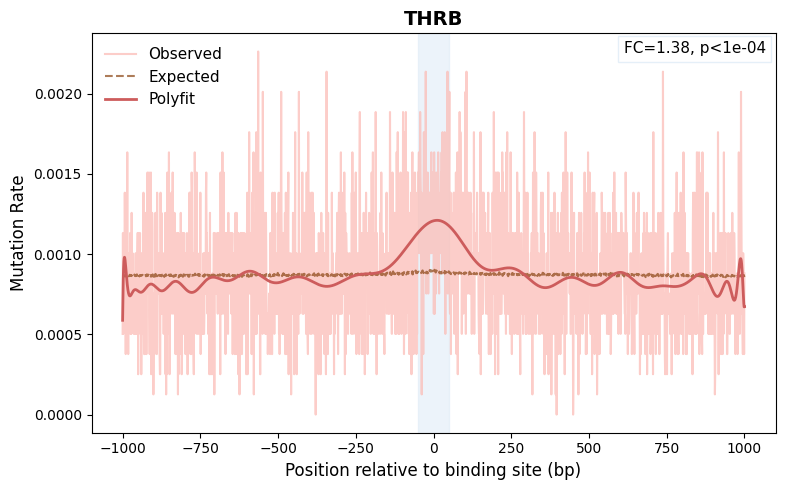

Samples: PCAWG_all_samples Gene: UBP1 Obs Sum: 15144 Exp Sum: 15144.000000000047
FC: 1.4897857754453114 OR1.5343375232965275 Pvalue: 1.845751257209803e-20
FC core:1.4897857754453114 Pvalue: 1.845751257209803e-20


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


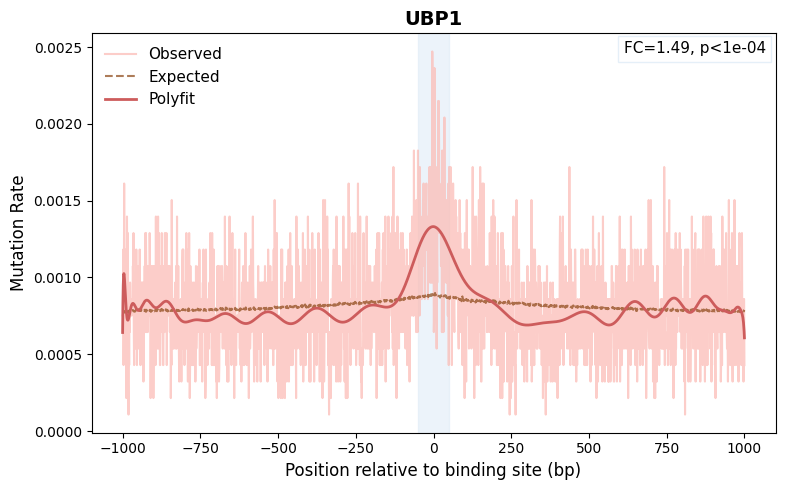

Samples: PCAWG_all_samples Gene: USF1 Obs Sum: 27007 Exp Sum: 27007.000000000087
FC: 1.0470187098939192 OR1.0497919194101815 Pvalue: 0.20866629514350468
FC core:1.0470187098939192 Pvalue: 0.20866629514350468


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


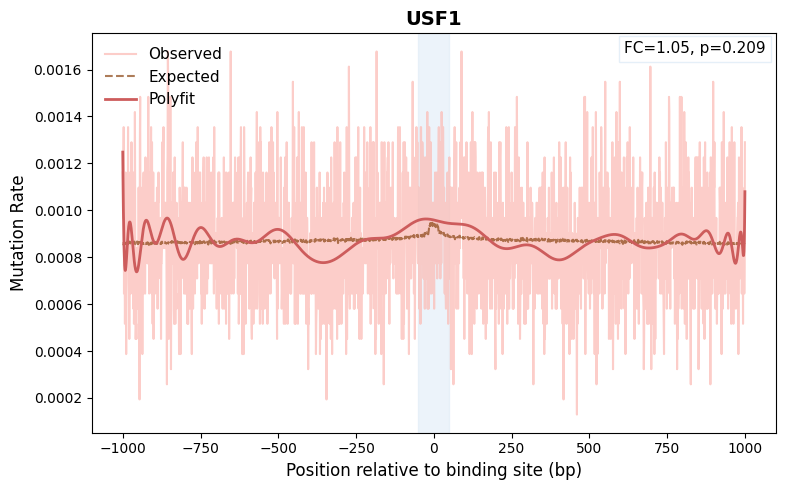

Samples: PCAWG_all_samples Gene: USF2 Obs Sum: 34084 Exp Sum: 34084.00000000012
FC: 1.0804689496102011 OR1.0856216662899958 Pvalue: 0.015359362319235344
FC core:1.0804689496102011 Pvalue: 0.015359362319235344


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


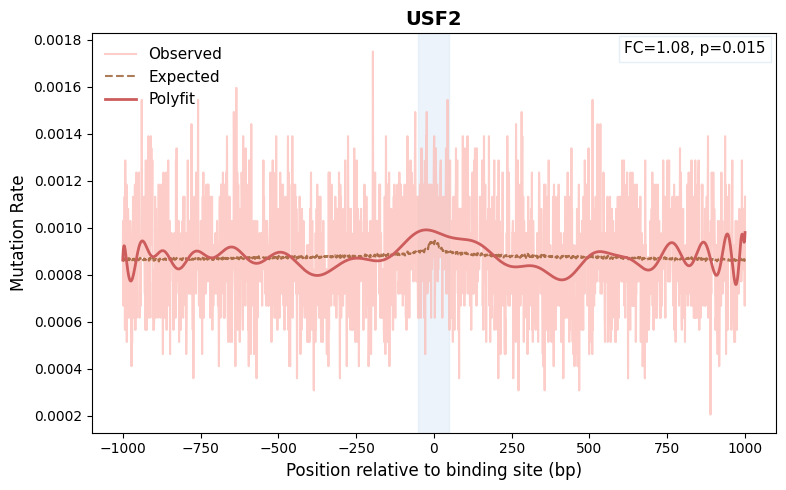

Samples: PCAWG_all_samples Gene: YY1 Obs Sum: 9418 Exp Sum: 9418.000000000033
FC: 1.1282614210842634 OR1.1374404924204575 Pvalue: 0.03776117480844103
FC core:1.1282614210842634 Pvalue: 0.03776117480844103


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


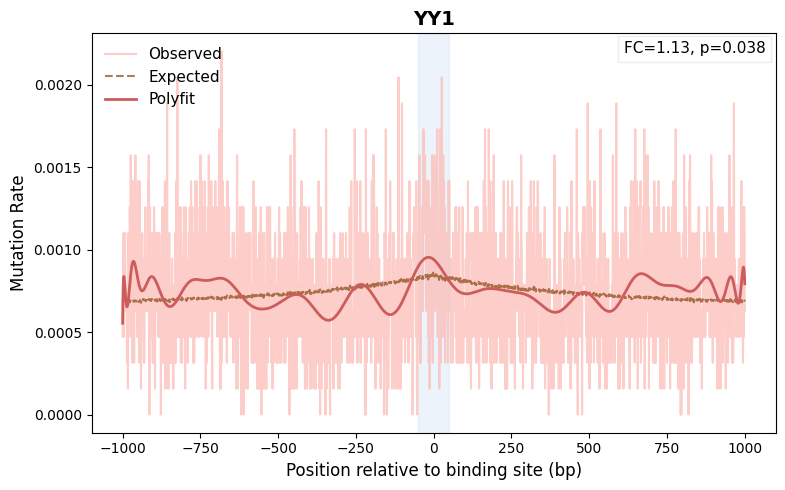

Samples: PCAWG_all_samples Gene: ZBTB21 Obs Sum: 8692 Exp Sum: 8692.000000000025
FC: 1.309277627286717 OR1.334885371862864 Pvalue: 6.10457411916131e-06
FC core:1.309277627286717 Pvalue: 6.10457411916131e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


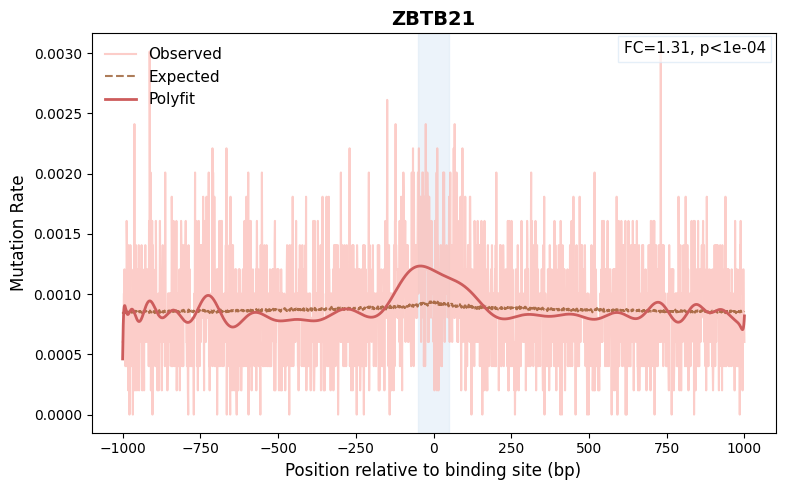

Samples: PCAWG_all_samples Gene: ZBTB26 Obs Sum: 12862 Exp Sum: 12862.00000000005
FC: 1.2665688384252731 OR1.2875894052413874 Pvalue: 1.4529066060814013e-06
FC core:1.2665688384252731 Pvalue: 1.4529066060814013e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


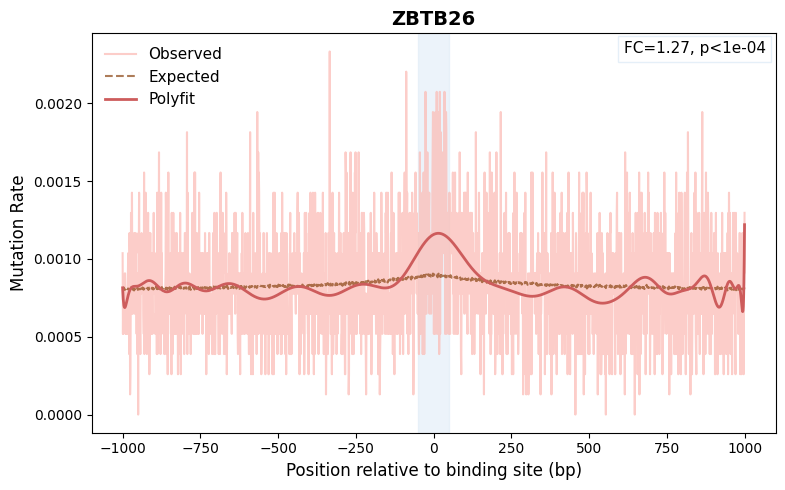

Samples: PCAWG_all_samples Gene: ZBTB33 Obs Sum: 2707 Exp Sum: 2707.000000000011
FC: 1.2329298957383348 OR1.257215390717969 Pvalue: 0.04851708878110842
FC core:1.2329298957383348 Pvalue: 0.04851708878110842


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


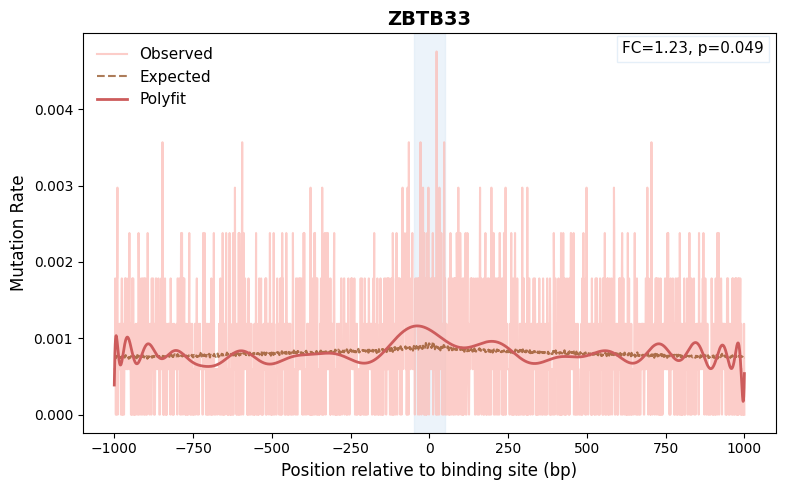

Samples: PCAWG_all_samples Gene: ZBTB7A Obs Sum: 9816 Exp Sum: 9816.000000000022
FC: 0.9742413178763066 OR0.9741859120424375 Pvalue: 0.6808988731322058
FC core:0.9742413178763066 Pvalue: 0.6808988731322058


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


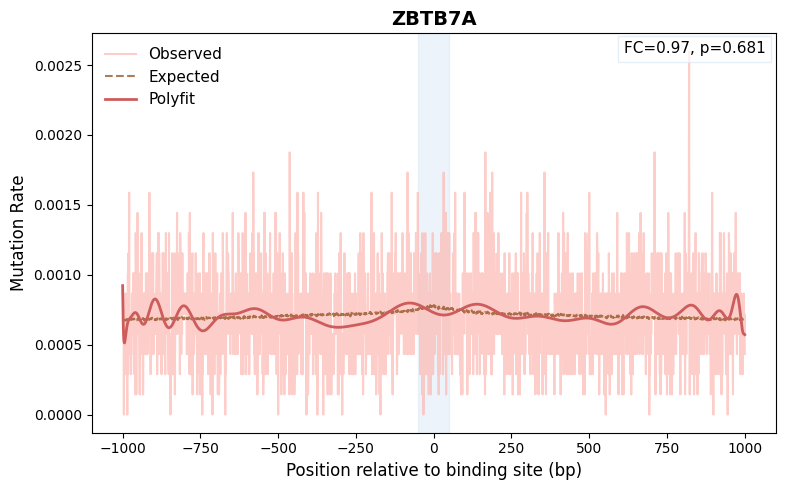

Samples: PCAWG_all_samples Gene: ZC3H4 Obs Sum: 3488 Exp Sum: 3488.00000000001
FC: 1.0135206268757184 OR1.0170090655439823 Pvalue: 0.9148189272235254
FC core:1.0135206268757184 Pvalue: 0.9148189272235254


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


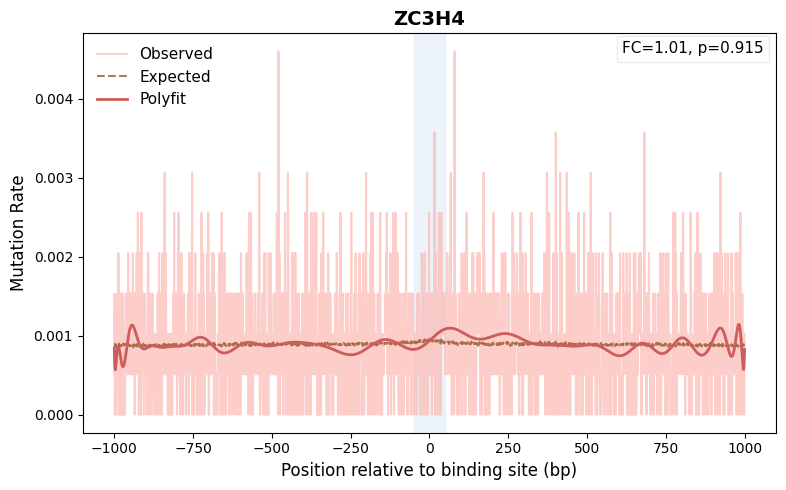

Samples: PCAWG_all_samples Gene: ZCCHC11 Obs Sum: 5946 Exp Sum: 5946.000000000021
FC: 1.5612159156053862 OR1.6173811983471074 Pvalue: 6.363085911917831e-11
FC core:1.5612159156053862 Pvalue: 6.363085911917831e-11


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


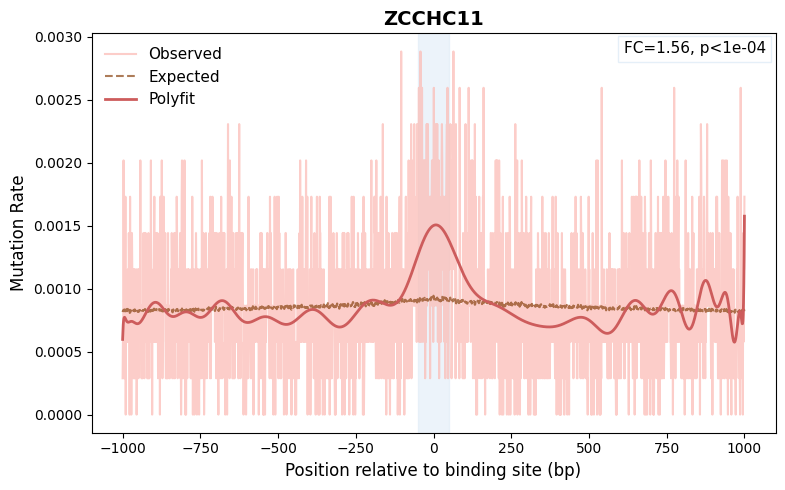

Samples: PCAWG_all_samples Gene: ZEB1 Obs Sum: 4946 Exp Sum: 4946.000000000015
FC: 1.3286422689503596 OR1.356003076983767 Pvalue: 0.00041741822876820535
FC core:1.3286422689503596 Pvalue: 0.00041741822876820535


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


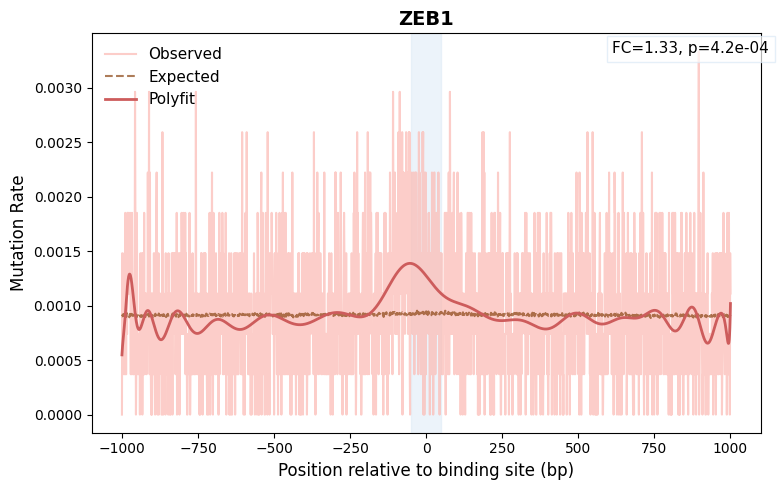

Samples: PCAWG_all_samples Gene: ZFP1 Obs Sum: 8475 Exp Sum: 8475.00000000003
FC: 1.444697596922236 OR1.483338817713607 Pvalue: 5.639731971435844e-10
FC core:1.444697596922236 Pvalue: 5.639731971435844e-10


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


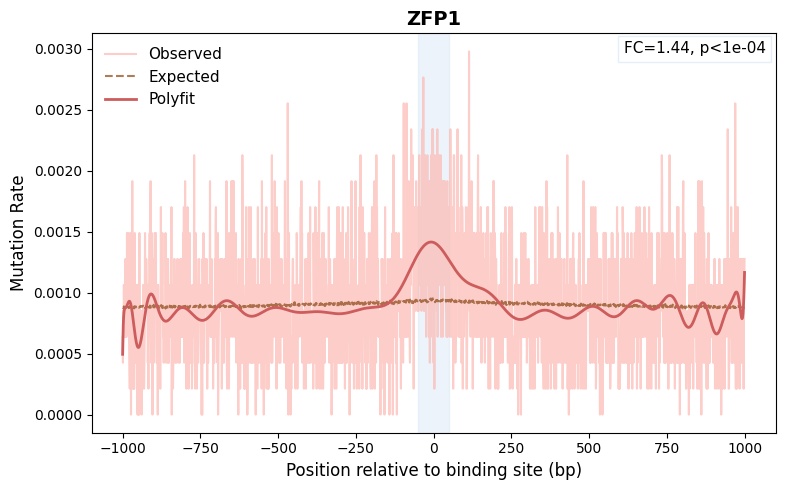

Samples: PCAWG_all_samples Gene: ZFP64 Obs Sum: 10043 Exp Sum: 10043.000000000031
FC: 1.095944457302167 OR1.102201450400695 Pvalue: 0.12239008775687474
FC core:1.095944457302167 Pvalue: 0.12239008775687474


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


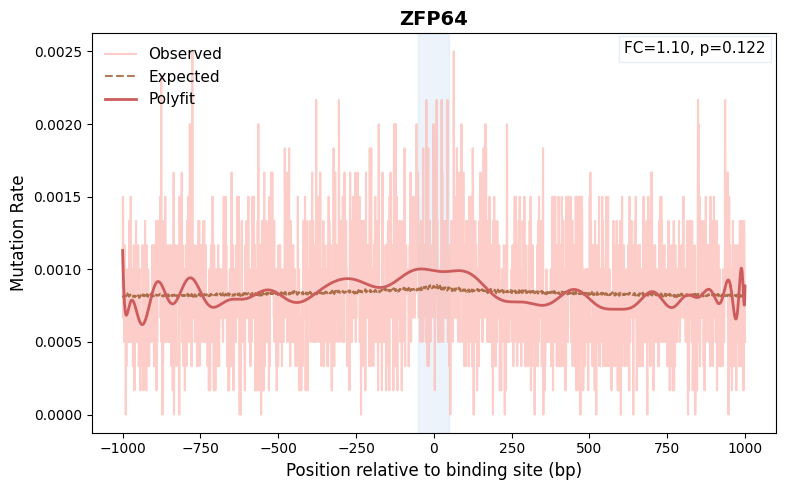

Samples: PCAWG_all_samples Gene: ZGPAT Obs Sum: 35978 Exp Sum: 35978.00000000011
FC: 1.3288507287433524 OR1.3543829158852663 Pvalue: 1.8041381369826492e-22
FC core:1.3288507287433524 Pvalue: 1.8041381369826492e-22


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


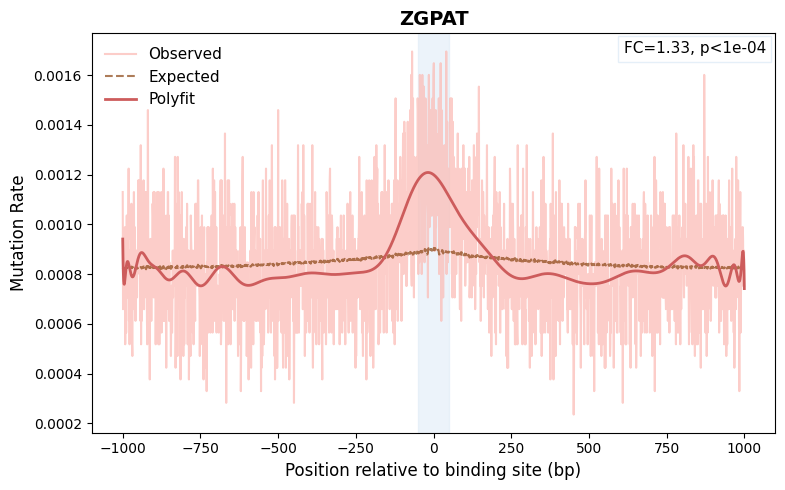

Samples: PCAWG_all_samples Gene: ZHX2 Obs Sum: 7361 Exp Sum: 7361.000000000026
FC: 1.1114822657000543 OR1.1206757745578633 Pvalue: 0.10916408944097153
FC core:1.1114822657000543 Pvalue: 0.10916408944097153


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


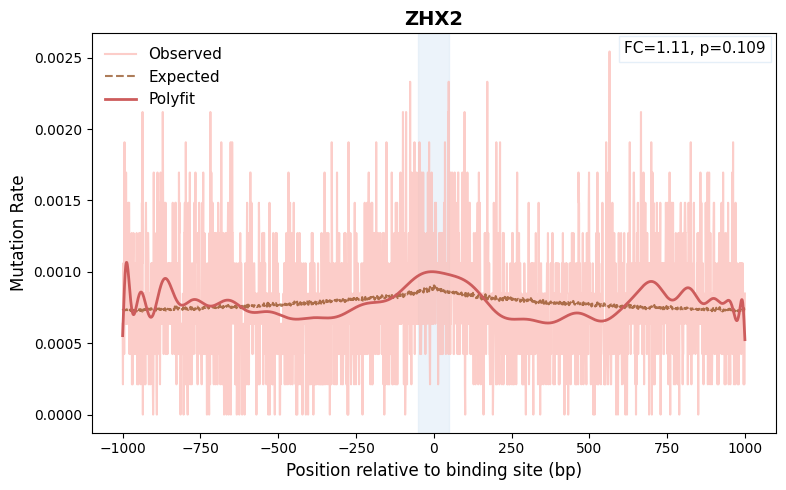

Samples: PCAWG_all_samples Gene: ZHX3 Obs Sum: 2919 Exp Sum: 2919.0000000000105
FC: 1.2472634774395792 OR1.2715413007509226 Pvalue: 0.03046546844724128
FC core:1.2472634774395792 Pvalue: 0.03046546844724128


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


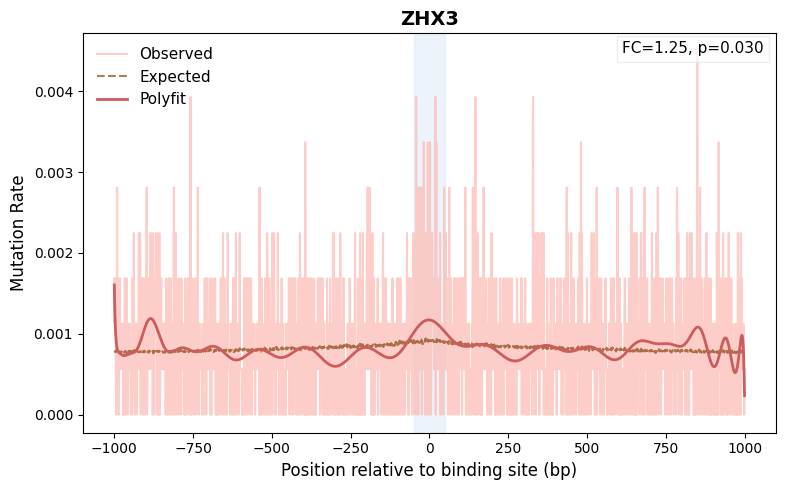

Samples: PCAWG_all_samples Gene: ZKSCAN8 Obs Sum: 12459 Exp Sum: 12459.000000000033
FC: 1.4701354070661585 OR1.5114770675334055 Pvalue: 2.4865268413256393e-15
FC core:1.4701354070661585 Pvalue: 2.4865268413256393e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


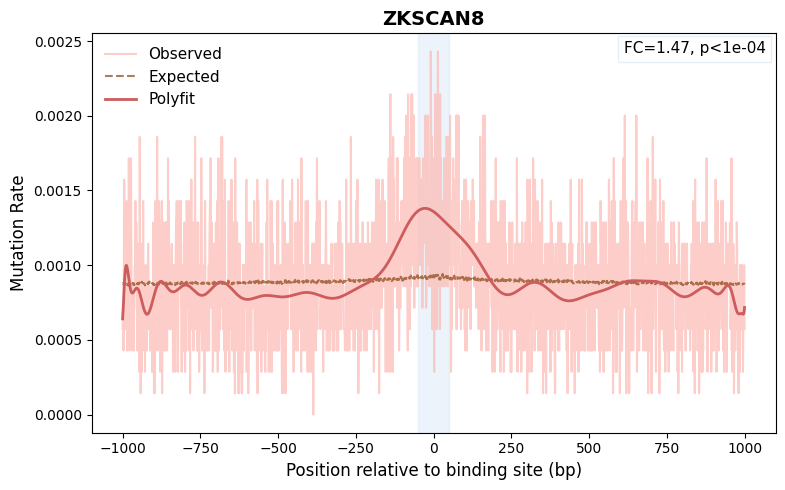

Samples: PCAWG_all_samples Gene: ZMYM3 Obs Sum: 13595 Exp Sum: 13595.000000000031
FC: 1.0591365110332325 OR1.06288726551683 Pvalue: 0.2750774577137545
FC core:1.0591365110332325 Pvalue: 0.2750774577137545


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


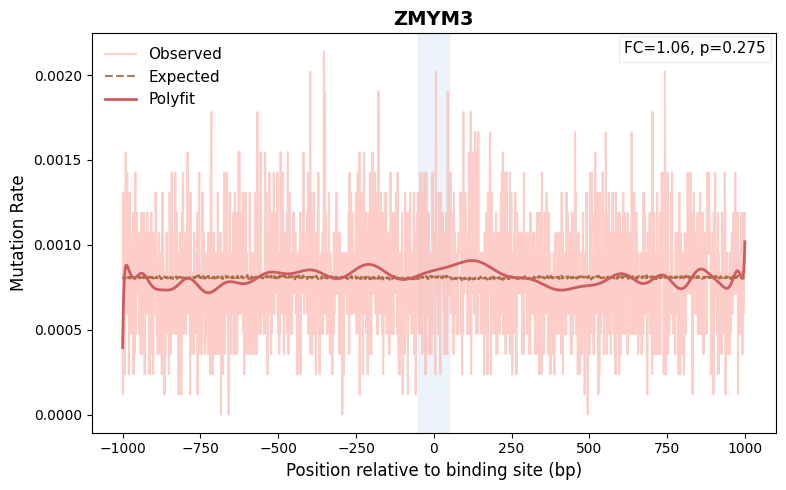

Samples: PCAWG_all_samples Gene: ZNF12 Obs Sum: 18105 Exp Sum: 18105.00000000006
FC: 1.2139769463496 OR1.2283713162652499 Pvalue: 5.830157785897284e-06
FC core:1.2139769463496 Pvalue: 5.830157785897284e-06


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


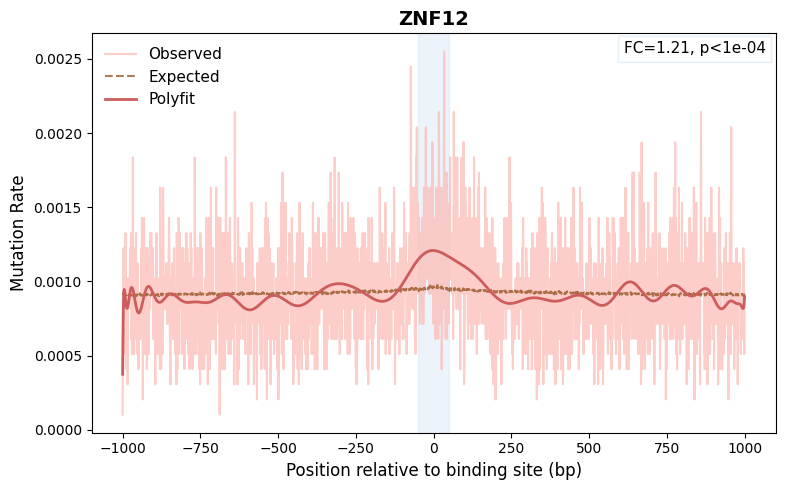

Samples: PCAWG_all_samples Gene: ZNF143 Obs Sum: 29219 Exp Sum: 29219.000000000106
FC: 1.9310704533842913 OR2.040362449511221 Pvalue: 3.2376563988343142e-114
FC core:1.9310704533842913 Pvalue: 3.2376563988343142e-114


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


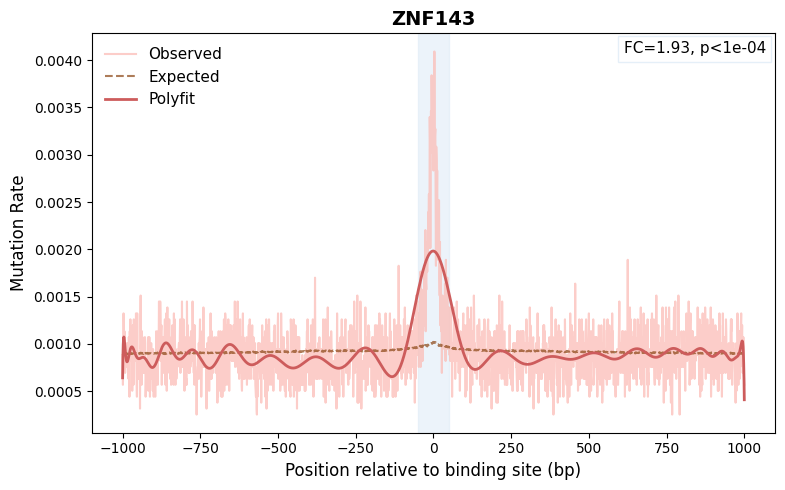

Samples: PCAWG_all_samples Gene: ZNF189 Obs Sum: 2563 Exp Sum: 2563.0000000000073
FC: 1.290101575428495 OR1.317466964451889 Pvalue: 0.022164842610200887
FC core:1.290101575428495 Pvalue: 0.022164842610200887


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


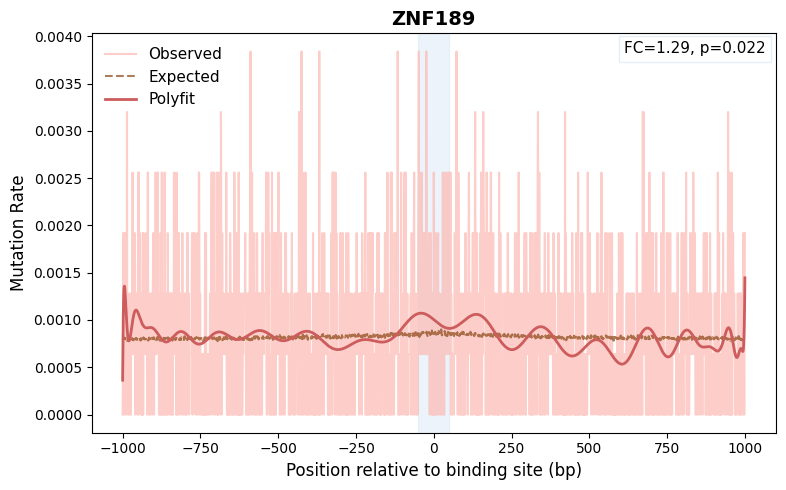

Samples: PCAWG_all_samples Gene: ZNF219 Obs Sum: 53620 Exp Sum: 53620.00000000012
FC: 1.3706575287472131 OR1.3993908536115067 Pvalue: 1.2314477898807879e-39
FC core:1.3706575287472131 Pvalue: 1.2314477898807879e-39


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


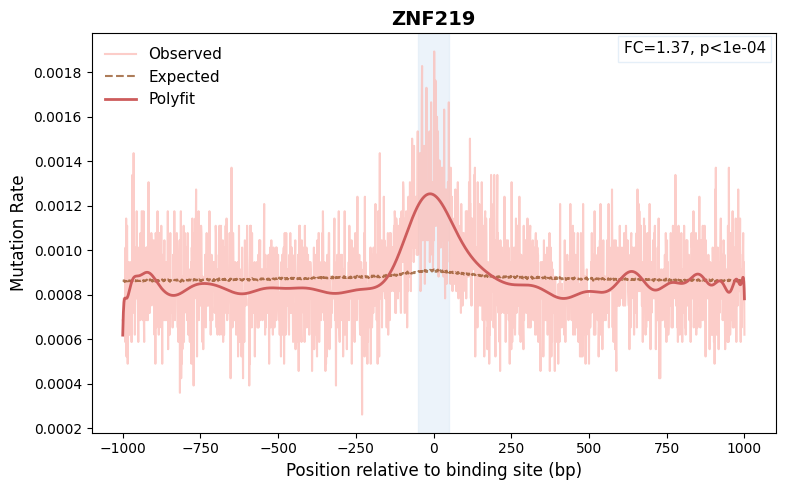

Samples: PCAWG_all_samples Gene: ZNF274 Obs Sum: 196 Exp Sum: 196.00000000000057
FC: 1.203771417054724 OR1.3478260869565217 Pvalue: 0.6547116544095224
FC core:1.203771417054724 Pvalue: 0.6547116544095224


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


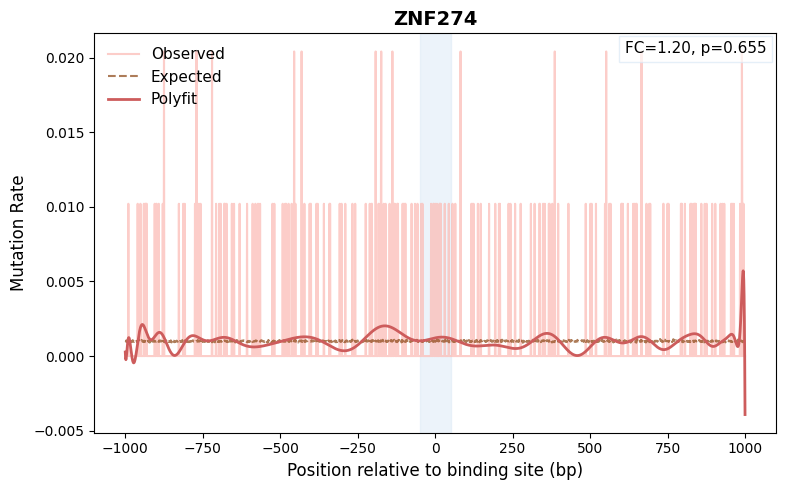

Samples: PCAWG_all_samples Gene: ZNF281 Obs Sum: 10505 Exp Sum: 10505.000000000025
FC: 1.0767519177175289 OR1.0814904574371402 Pvalue: 0.2047202364594614
FC core:1.0767519177175289 Pvalue: 0.2047202364594614


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


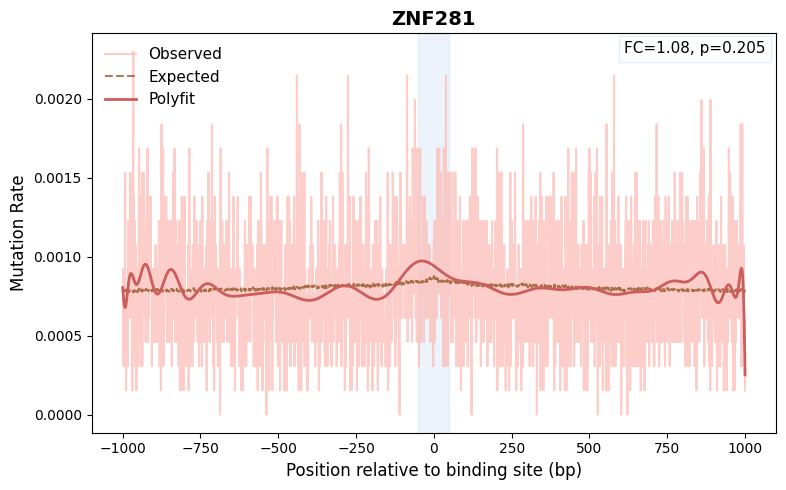

Samples: PCAWG_all_samples Gene: ZNF3 Obs Sum: 5448 Exp Sum: 5448.000000000016
FC: 1.1635996313680892 OR1.1769085706853948 Pvalue: 0.05829515313496586
FC core:1.1635996313680892 Pvalue: 0.05829515313496586


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


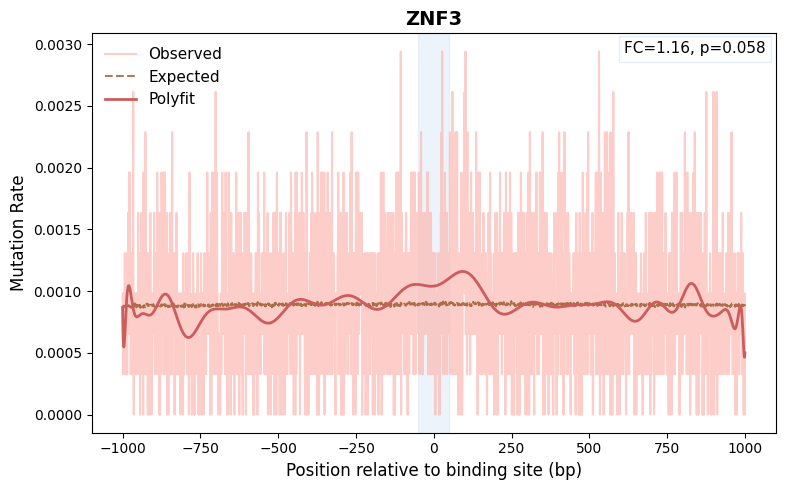

Samples: PCAWG_all_samples Gene: ZNF331 Obs Sum: 26536 Exp Sum: 26536.000000000073
FC: 1.3861466061737158 OR1.4179369581564047 Pvalue: 2.1410645400091456e-22
FC core:1.3861466061737158 Pvalue: 2.1410645400091456e-22


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


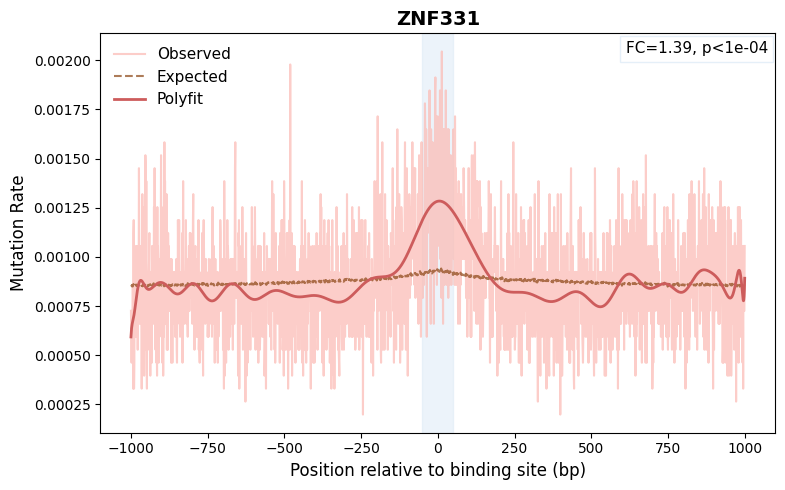

Samples: PCAWG_all_samples Gene: ZNF334 Obs Sum: 1985 Exp Sum: 1985.0000000000066
FC: 1.1704537452453354 OR1.182535635365824 Pvalue: 0.231494148727926
FC core:1.1704537452453354 Pvalue: 0.231494148727926


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


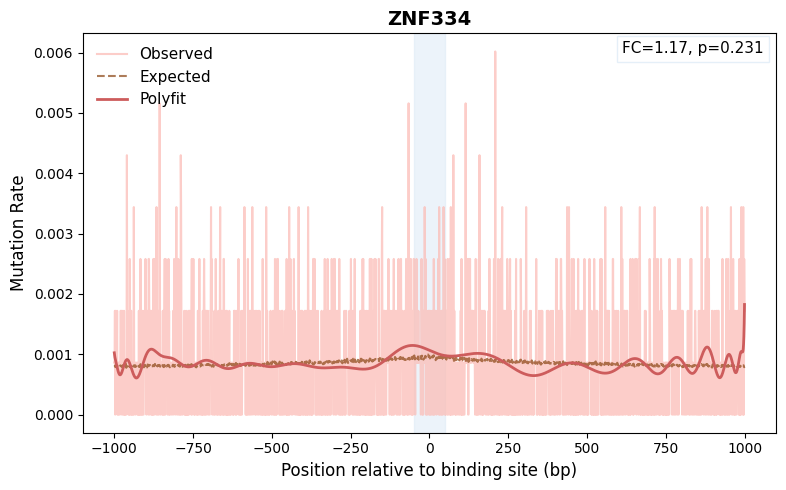

Samples: PCAWG_all_samples Gene: ZNF335 Obs Sum: 12971 Exp Sum: 12971.00000000004
FC: 1.4444499755507458 OR1.4817847401697595 Pvalue: 9.233313302350063e-15
FC core:1.4444499755507458 Pvalue: 9.233313302350063e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


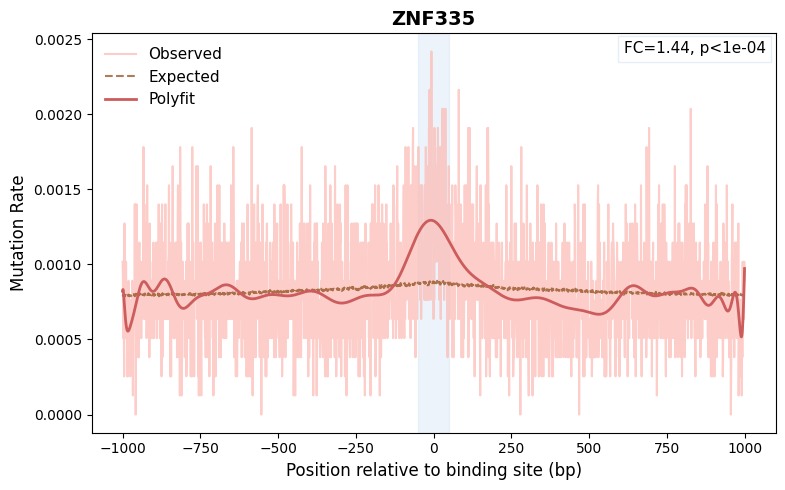

Samples: PCAWG_all_samples Gene: ZNF384 Obs Sum: 21402 Exp Sum: 21402.000000000076
FC: 1.3796874131330044 OR1.407034828621071 Pvalue: 2.952788717840128e-16
FC core:1.3796874131330044 Pvalue: 2.952788717840128e-16


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


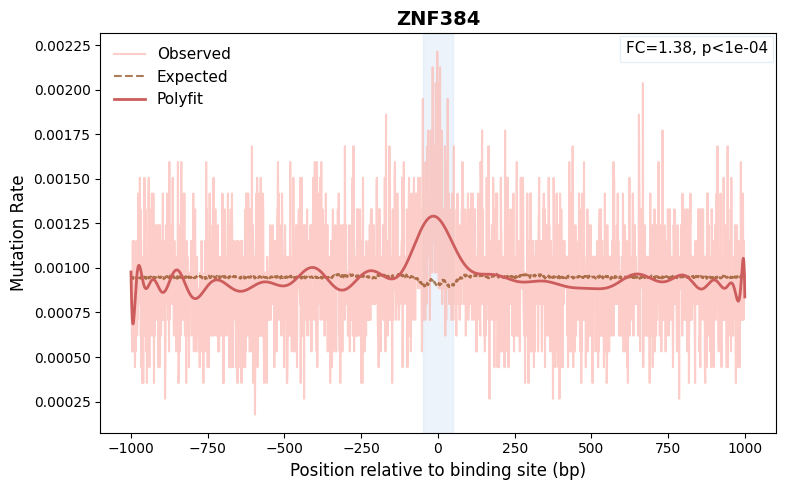

Samples: PCAWG_all_samples Gene: ZNF48 Obs Sum: 16089 Exp Sum: 16089.000000000047
FC: 1.2413746229791842 OR1.2602537186037386 Pvalue: 6.66260830287377e-07
FC core:1.2413746229791842 Pvalue: 6.66260830287377e-07


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


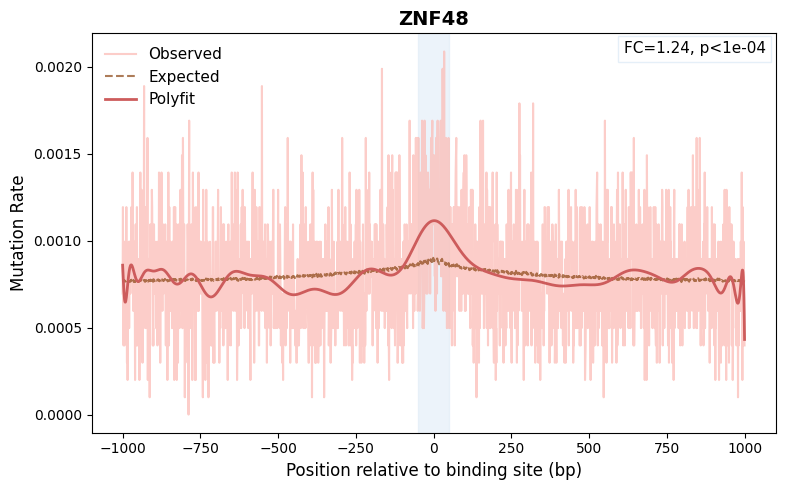

Samples: PCAWG_all_samples Gene: ZNF511 Obs Sum: 16484 Exp Sum: 16484.00000000005
FC: 1.5027540181431163 OR1.5470395351840829 Pvalue: 1.7492766335718816e-22
FC core:1.5027540181431163 Pvalue: 1.7492766335718816e-22


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


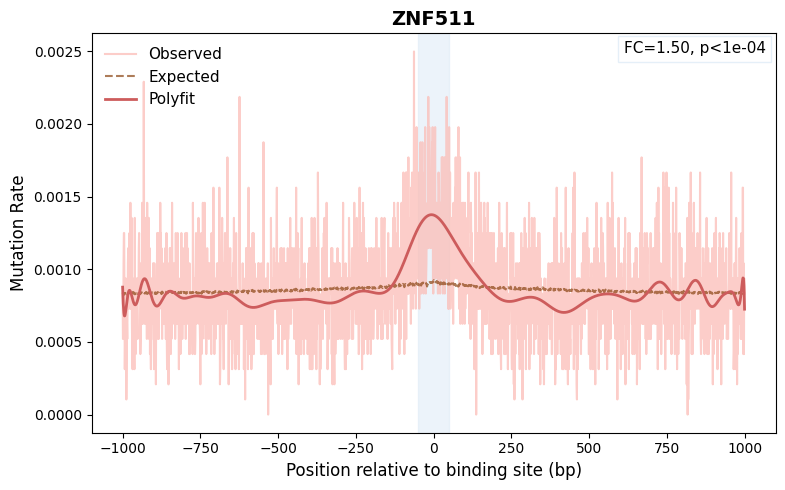

Samples: PCAWG_all_samples Gene: ZNF544 Obs Sum: 10930 Exp Sum: 10930.000000000036
FC: 1.3547145461957153 OR1.3826857440971778 Pvalue: 6.824171504928015e-09
FC core:1.3547145461957153 Pvalue: 6.824171504928015e-09


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


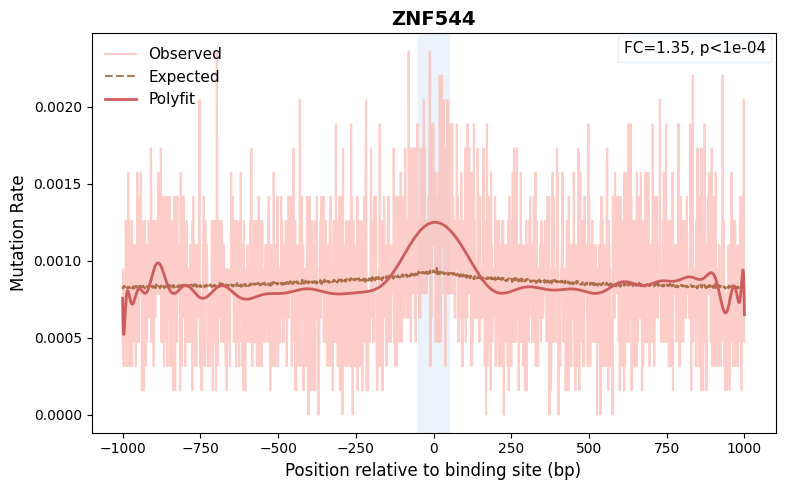

Samples: PCAWG_all_samples Gene: ZNF580 Obs Sum: 11153 Exp Sum: 11153.000000000036
FC: 1.4408979826331958 OR1.4789212345438614 Pvalue: 5.086043186110412e-13
FC core:1.4408979826331958 Pvalue: 5.086043186110412e-13


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


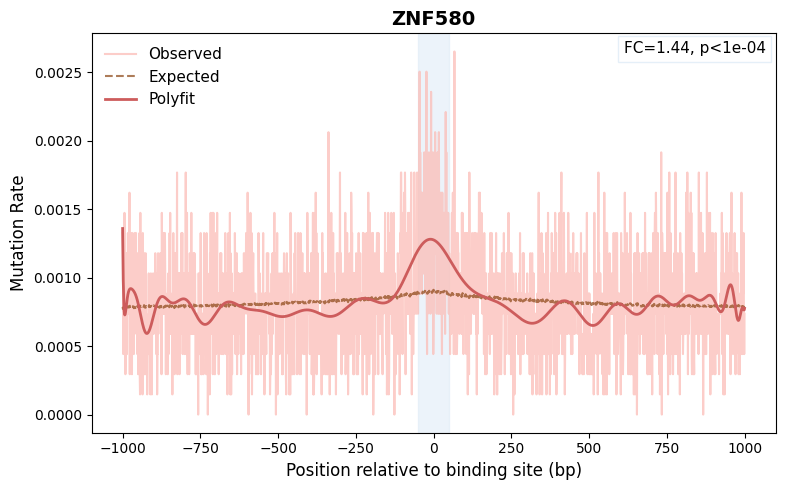

Samples: PCAWG_all_samples Gene: ZNF644 Obs Sum: 31311 Exp Sum: 31311.000000000106
FC: 1.251495799943289 OR1.269210086042065 Pvalue: 3.880023909405505e-12
FC core:1.251495799943289 Pvalue: 3.880023909405505e-12


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


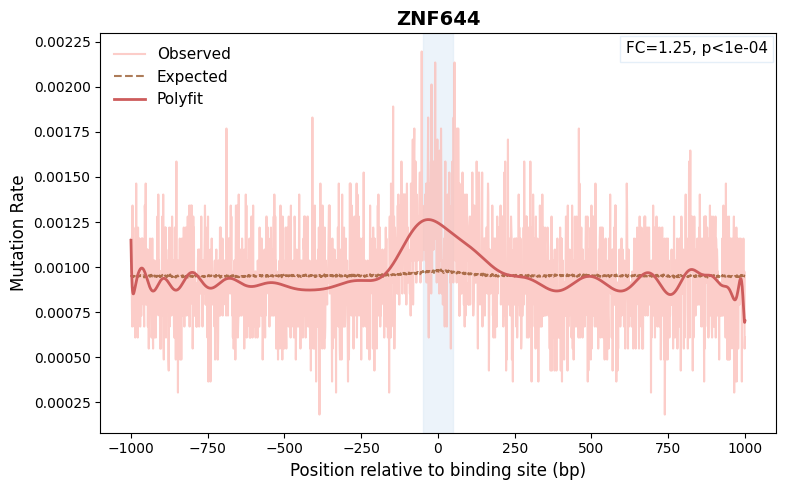

Samples: PCAWG_all_samples Gene: ZNF652 Obs Sum: 15420 Exp Sum: 15420.00000000004
FC: 1.210733712403077 OR1.2260977720095176 Pvalue: 4.390223376421351e-05
FC core:1.210733712403077 Pvalue: 4.390223376421351e-05


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


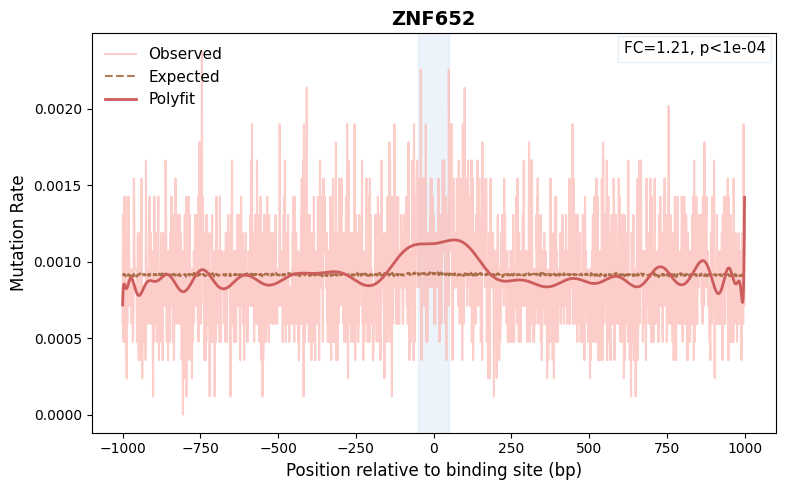

Samples: PCAWG_all_samples Gene: ZNF7 Obs Sum: 9833 Exp Sum: 9833.000000000033
FC: 1.1201182486731251 OR1.1287729341533541 Pvalue: 0.05865160744465678
FC core:1.1201182486731251 Pvalue: 0.05865160744465678


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


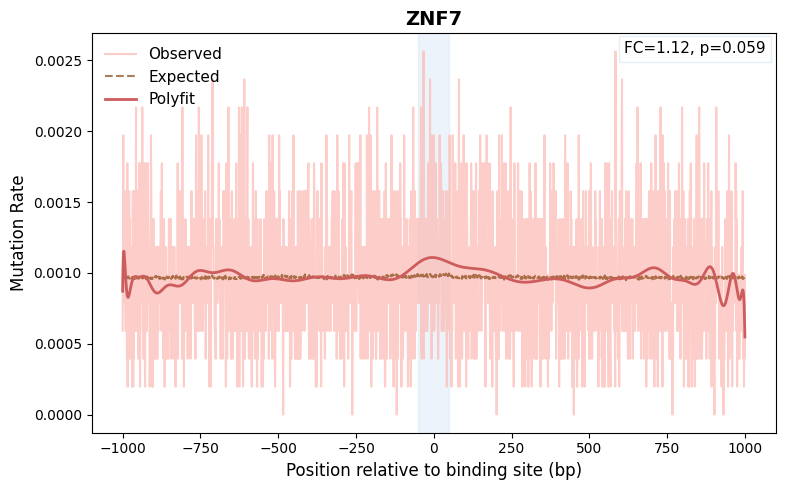

Samples: PCAWG_all_samples Gene: ZNF792 Obs Sum: 19460 Exp Sum: 19460.000000000065
FC: 1.369560795201888 OR1.3997016606859718 Pvalue: 1.05858454338841e-15
FC core:1.369560795201888 Pvalue: 1.05858454338841e-15


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


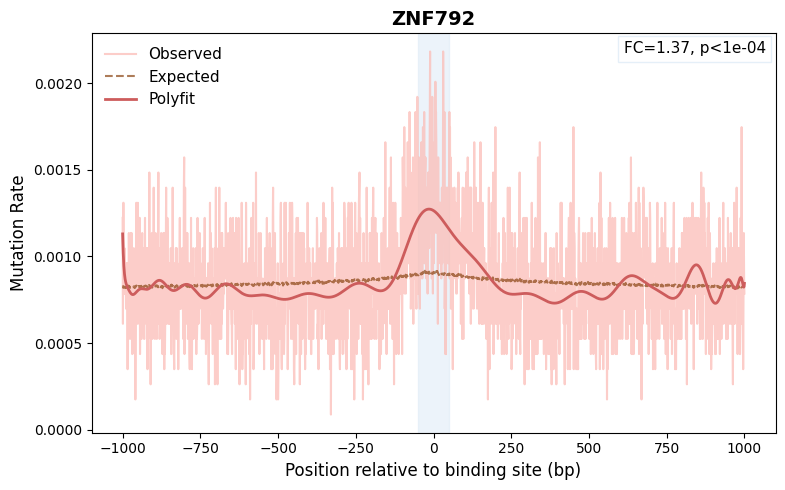

Samples: PCAWG_all_samples Gene: ZSCAN29 Obs Sum: 4540 Exp Sum: 4540.0000000000155
FC: 1.3092346930578929 OR1.3334952184239421 Pvalue: 0.001115466961818681
FC core:1.3092346930578929 Pvalue: 0.001115466961818681


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


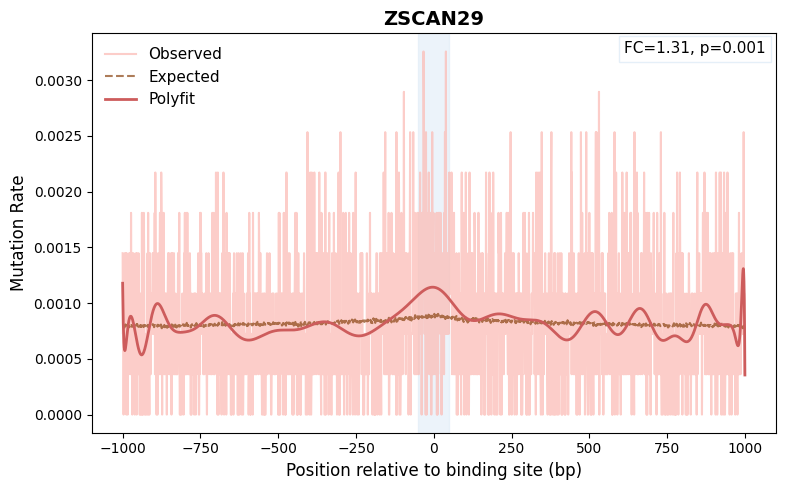

Samples: PCAWG_all_samples Gene: ZSCAN9 Obs Sum: 16465 Exp Sum: 16465.00000000006
FC: 1.4576005550275415 OR1.4966894463098295 Pvalue: 3.7217936293283854e-19
FC core:1.4576005550275415 Pvalue: 3.7217936293283854e-19


/home/sabari/georgenija/.local/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


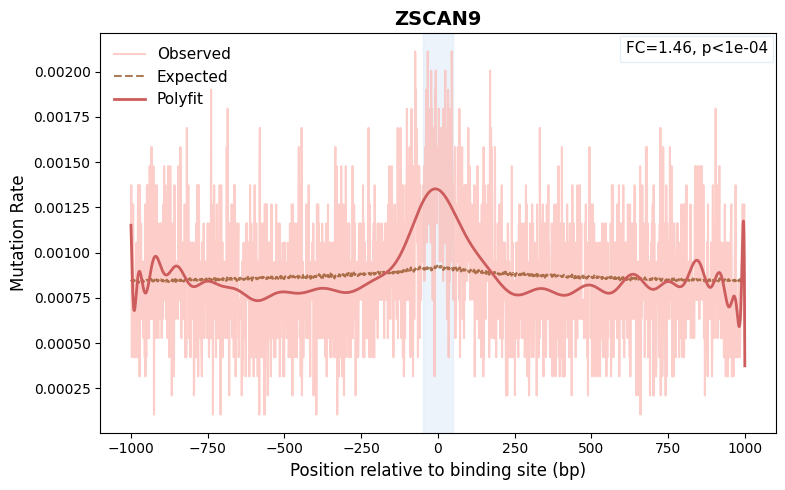

Duration: 4:36:55.871393


In [22]:
from datetime import datetime
start_time = datetime.now()

core = 50
dhs = 250
flank_size = 1000

for tumor_type in ['PCAWG_all_samples']:
    
    # read signature probabilities
    sign_dict = mut_prob.set_index('mutation').T.to_dict()
    
    
    HCCnbp_bed = pbt.BedTool.from_dataframe(HCC_nbp)
    
    #creating a list for the plot_values later on
    plot_values = []
    pos_muts = pd.DataFrame()
    p_value = []
    
    for gene in TFBS_df[4].unique().tolist():
        #to get a list of all the (unique)genes presnt in the dataframe
        #adding the unique gene list to a df
        df2=TFBS_df[TFBS_df[4]== gene]
        #df2_len = (len(df2)) 
        
        df2_bed = pbt.BedTool.from_dataframe(df2)
    
        # intersect mutations with the TFBS region
        res1 = df2_bed.intersect(HCCnbp_bed, wo=True)
        res_df = res1.to_dataframe(header=None)
        res_df.columns = range(res_df.shape[1])
        res = pbt.BedTool.from_dataframe(res_df)
        #print(res_df)
                              
        obs_counts = defaultdict(int)
        for row in res:
            middle = int(row[2])-flank_size
            diff = int(row[8])-middle
            obs_counts[diff] += 1
    
        collect = []
        for i in range(-flank_size, flank_size+1, 1):
            if i in obs_counts.keys():
                collect.append([i, obs_counts[i]])
            else:
                collect.append([i, 0])

        obs_df = pd.DataFrame(collect, columns=['position', 'observed_muts'])
        obs_norm = obs_df.copy()
        obs_norm['observed_muts'] = obs_norm['observed_muts']/len(df2) 

#       get expected mutation count
        final_position_prob_df = get_exp_mut(res_df, flank_size, sign_dict, gene, "Probability_%s" % tumor_type)
        
        final_position_prob_norm = final_position_prob_df.copy()
        final_position_prob_norm['expected_muts'] = final_position_prob_df['expected_muts']/len(df2)
    
        print(
            f"Samples: {tumor_type}",
            f"Gene: {gene}",
            f"Obs Sum: {obs_df['observed_muts'].sum()}",
            f"Exp Sum: {final_position_prob_df['expected_muts'].sum()}"
        )
            
        to_plot = pd.merge(obs_df, final_position_prob_df, on='position')
        to_plot["TFBS"] = gene
        to_plot_normalised = pd.merge(obs_norm, final_position_prob_norm, on='position')
        to_plot_normalised["TFBS"] = gene
        
        # Append the modified DataFrame to the list
        plot_values.append(to_plot)

        # Concatenate all the DataFrames in the list into one DataFrame
        pos_muts = pd.concat(plot_values, ignore_index=True)
        
    
        # Fishers-test to find out if the number of mutations at the core is more than expected
        obs_muts, obs_flank_muts, exp_muts, exp_flank_muts, fc_core, fc_dhs, fc_flanks, odd_ratio_core, p_value_core = fisherstest(to_plot, core, dhs, flank_size)
        # adding all observed and expected values to a df
        p_value.append([gene, obs_muts, obs_flank_muts, exp_muts, exp_flank_muts, fc_core, fc_dhs, fc_flanks, odd_ratio_core, p_value_core])
        p_value_df = pd.DataFrame(p_value)
        p_value_df.columns = ["Gene", "Obs_core101", "Obs_flank", "Exp_core101", "Exp_flank", "FC_50", "FC_dhs(250)", "FC_flank", "Odds Ratio", "P-value50"]     
        print(f"FC core:{fc_core}", f"Pvalue: {p_value_core}")
        
        #Plots
        fig, ax = plt.subplots(figsize=(8,5))
        # Observed (light pink)
        plt.plot(to_plot_normalised['position'], to_plot_normalised['observed_muts'], color="#fcb9b2", alpha=0.7, label="Observed")
        # Expected (saddle brown dashed)
        plt.plot(to_plot_normalised['position'], to_plot_normalised['expected_muts'], color="saddlebrown", linestyle="--", label="Expected", alpha = 0.7)
        # Highlight core region
        ax.axvspan(-core, core, color="#dbe9f6", alpha=0.5)

        # Asthetics
        plt.title("%s %s" % (tumor_type, gene))
        #plt.text(0.8, 0.93,'fc='+ str(fc_core)[:4]+' ,P='+"%.3f"%(p_value_core), ha='center', va='center', bbox={'facecolor':'w','pad':5}, transform=plt.gca().transAxes)
        coefs = poly.polyfit(to_plot_normalised['position'], to_plot_normalised['observed_muts'], 50)
        ffit = poly.polyval (to_plot_normalised['position'], coefs)
        plt.plot(to_plot_normalised['position'], ffit,color="indianred", linewidth= 2, zorder=3, label="Polyfit")
        
        # Title + annotation
        ax.set_title(f"{gene}", fontsize=14, weight="bold")
        ax.set_xlabel("Position relative to binding site (bp)", fontsize=12)
        ax.set_ylabel("Mutation Rate", fontsize=12)
        label_text = format_fc_p(fc_core, p_value_core, tiny_thresh=1e-4)
        ax.text(
            0.778, 0.98, label_text,
            transform=ax.transAxes, ha="left", va="top",
            fontsize=11, bbox=dict(facecolor="white", alpha=0.7, edgecolor="#dbe9f6")
        )
        ax.legend(loc="upper left", frameon=False, fontsize=11)
        plt.tight_layout()
        plt.show()

      
       # break
        
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))

In [21]:
pbt.cleanup()

In [ ]:
# Save position values and statistics
pos_muts.to_csv(OUTPUT_DIR / "PCAWG_208TFBS_position_mutation_profiles.csv", sep="\t",index=False)
#p_value_df.to_csv(OUTPUT_DIR / "PCAWG_208TFBS_mutation_rate_statistics.csv",sep="\t", index=False)

#### FC-vs-Pvalue plots

##### filter our candidate 156 TFs - Benjamini-Hochberg

In [23]:
filtered = p_value_df[p_value_df["Gene"].isin(filtred156["Gene"].tolist())].copy()
print(len(filtered))
filtered.head()

156


,Gene,Obs_core101,Obs_flank,Exp_core101,Exp_flank,FC_50,FC_dhs(250),FC_flank,Odds Ratio,P-value50
0,ARID3A,2184,25408,1401.878387,26190.121613,1.557910,1.105147,0.934439,1.606865,7.166796e-42
1,ARID4B,3808,46433,2667.118741,47573.881259,1.427758,1.041539,0.957769,1.462877,8.326417e-49
2,ARID5B,4973,66839,3731.243991,68080.756009,1.332799,1.058906,0.960882,1.357634,5.374094e-43
3,ASH2L,1522,27245,1506.273090,27260.726910,1.010441,1.041066,0.987791,1.011181,7.794352e-01
4,ATF1,953,13039,735.409036,13256.590964,1.295877,1.107713,0.948985,1.318177,4.885186e-08


##### FDR Corrections

In [24]:
fdr_50 = statsmodels.stats.multitest.multipletests(filtered["P-value50"], method="fdr_bh",
    is_sorted=False, returnsorted=False)
filtered["fdr_50"] = fdr_50[1]

filtered["fdr50_log10"] = -np.log10(filtered["fdr_50"])
filtered["log2Fc"] = np.log2(filtered["FC_50"])
filtered["log2OR"] = np.log2(filtered["Odds Ratio"])

filtered.head()

,Gene,Obs_core101,Obs_flank,Exp_core101,Exp_flank,FC_50,FC_dhs(250),FC_flank,Odds Ratio,P-value50,fdr_50,fdr50_log10,log2Fc,log2OR
0,ARID3A,2184,25408,1401.878387,26190.121613,1.557910,1.105147,0.934439,1.606865,7.166796e-42,7.453468e-41,40.127642,0.639612,0.684249
1,ARID4B,3808,46433,2667.118741,47573.881259,1.427758,1.041539,0.957769,1.462877,8.326417e-49,1.298921e-47,46.886417,0.513751,0.548808
2,ARID5B,4973,66839,3731.243991,68080.756009,1.332799,1.058906,0.960882,1.357634,5.374094e-43,5.988276e-42,41.222698,0.414460,0.441095
3,ASH2L,1522,27245,1506.273090,27260.726910,1.010441,1.041066,0.987791,1.011181,7.794352e-01,7.895577e-01,0.102616,0.014985,0.016041
4,ATF1,953,13039,735.409036,13256.590964,1.295877,1.107713,0.948985,1.318177,4.885186e-08,7.189519e-08,7.143300,0.373929,0.398544


In [25]:
filtered.to_csv(OUTPUT_DIR / "PCAWG_156TFBS_mutation_rate_statistics.csv", sep="\t",index=False)

In [26]:
filtered[filtered["fdr_50"]< 0.05]

,Gene,Obs_core101,Obs_flank,Exp_core101,Exp_flank,FC_50,FC_dhs(250),FC_flank,Odds Ratio,P-value50,fdr_50,fdr50_log10,log2Fc,log2OR
0,ARID3A,2184,25408,1401.878387,26190.121613,1.557910,1.105147,0.934439,1.606865,7.166796e-42,7.453468e-41,40.127642,0.639612,0.684249
1,ARID4B,3808,46433,2667.118741,47573.881259,1.427758,1.041539,0.957769,1.462877,8.326417e-49,1.298921e-47,46.886417,0.513751,0.548808
2,ARID5B,4973,66839,3731.243991,68080.756009,1.332799,1.058906,0.960882,1.357634,5.374094e-43,5.988276e-42,41.222698,0.414460,0.441095
4,ATF1,953,13039,735.409036,13256.590964,1.295877,1.107713,0.948985,1.318177,4.885186e-08,7.189519e-08,7.143300,0.373929,0.398544
8,BCL6,3590,49022,2717.303318,49894.696682,1.321163,1.060922,0.961580,1.344814,8.158584e-30,4.713849e-29,28.326624,0.401808,0.427406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,ZNF580,882,10271,612.118284,10540.881716,1.440898,1.034910,0.956496,1.478921,5.086043e-13,9.559310e-13,12.019573,0.526968,0.564545
202,ZNF644,2023,29288,1616.465673,29694.534327,1.251496,1.097795,0.957027,1.269210,3.880024e-12,6.800941e-12,11.167431,0.323653,0.343931
203,ZNF652,948,14472,782.996286,14637.003714,1.210734,1.068798,0.966836,1.226098,4.390223e-05,5.660123e-05,4.247174,0.275882,0.294074
205,ZNF792,1428,18032,1042.670033,18417.329967,1.369561,1.061261,0.955914,1.399702,1.058585e-15,2.560360e-15,14.591699,0.453713,0.485119


In [27]:
print(len(filtered[filtered["FC_50"] > 1.5]))
filtered[filtered["FC_50"] > 1.5]

14


,Gene,Obs_core101,Obs_flank,Exp_core101,Exp_flank,FC_50,FC_dhs(250),FC_flank,Odds Ratio,P-value50,fdr_50,fdr50_log10,log2Fc,log2OR
0,ARID3A,2184,25408,1401.878387,26190.121613,1.557910,1.105147,0.934439,1.606865,7.166796e-42,7.453468e-41,40.127642,0.639612,0.684249
24,CTCF,7821,91036,5184.683863,93672.316137,1.508482,0.953510,0.976941,1.552365,3.351082e-127,1.742563e-125,124.758812,0.593097,0.634468
59,HNF1A,1216,14656,802.137360,15069.862640,1.515950,1.144258,0.926395,1.558936,1.545540e-21,5.067129e-21,20.295238,0.600222,0.640561
74,KDM6A,3138,31014,1772.089497,32379.910503,1.770791,1.049921,0.932252,1.848821,5.184038e-92,1.617420e-90,89.791177,0.824394,0.886606
85,MBD1,797,8266,485.757209,8577.242791,1.640737,1.040766,0.942277,1.705126,1.405257e-19,4.136229e-19,18.383395,0.714344,0.769879
90,MIXL1,2658,30528,1720.629888,31465.370112,1.544783,1.090209,0.938112,1.592780,5.929263e-49,1.027739e-47,46.988117,0.627404,0.671547
100,NFIA,2831,27614,1573.085816,28871.914184,1.799648,1.085808,0.921665,1.881671,3.399823e-87,8.839539e-86,85.053570,0.847714,0.912014
101,NFIC,1388,15988,885.437601,16490.562399,1.567586,1.166263,0.916898,1.617606,7.979584e-28,3.890047e-27,26.410045,0.648545,0.693860
121,RAD21,8643,98509,5608.119491,101543.880509,1.541158,0.988332,0.965434,1.588659,1.405683e-153,1.096433e-151,150.960018,0.624015,0.667809
131,RREB1,1326,15524,882.870388,15967.129612,1.501919,1.052148,0.950757,1.546303,1.328350e-22,4.933873e-22,21.306812,0.586807,0.628823
